<a href="https://colab.research.google.com/github/RjunaRachim/AplikasiAntrianInoveye/blob/main/final_prioritas_minus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Lepas koneksi Drive lama
from google.colab import drive
drive.flush_and_unmount()
print("Drive berhasil dilepas.")

Drive not mounted, so nothing to flush and unmount.
Drive berhasil dilepas.


In [ ]:
# =============================================================================
# PART 1: CLEANUP DIREKTORI, SELEKSI, DAN INISIALISASI DATA MENTAH
# =============================================================================
import pandas as pd
import os
import shutil
from google.colab import drive
import warnings
import hashlib

warnings.filterwarnings('ignore')

# 1. Setup Direktori
drive.mount('/content/drive')
path_drive = '/content/drive/My Drive/SKRIPSI/PROGRAM2'
nama_file_raw = 'Raw_Data_Optik.xlsx'
raw_path = os.path.join(path_drive, nama_file_raw)

print("[LAPORAN TAHAP 1: INISIALISASI & SELEKSI DATA]")
print("-" * 60)

# 2. Menghapus file lama kecuali Raw Data
print("Status Sistem    : Membersihkan file sebelumnya...")
if os.path.exists(path_drive):
    for f in os.listdir(path_drive):
        if f != nama_file_raw:
            file_path = os.path.join(path_drive, f)
            try:
                if os.path.isfile(file_path):
                    os.remove(file_path)
                elif os.path.isdir(file_path):
                    shutil.rmtree(file_path)
            except Exception as e:
                pass
    print("Status Sistem    : Semua file sudah dihapus! Menjalankan sequence baru.")
else:
    print("Status Sistem    : Direktori tidak ditemukan.")

# 3. Pembacaan Data Mentah
try:
    df_raw = pd.read_excel(raw_path)
    print(f"Status Pembacaan : Berhasil")
    print(f"Total Baris Data : {len(df_raw)} entri")
except Exception as e:
    print(f"Status Pembacaan : GAGAL ({e})")

# 4. Seleksi Kolom
kolom_disimpan = ['nama_customer', 'jenis_kelamin', 'usia_saat_rm', 'alamat', 'tindakan_r_sph', 'tindakan_r_cyl', 'tindakan_l_sph', 'tindakan_l_cyl']
df_seleksi = df_raw[kolom_disimpan].rename(columns={
    'nama_customer':'Nama', 'jenis_kelamin':'Gender', 'usia_saat_rm':'Usia',
    'alamat':'Alamat', 'tindakan_r_sph':'R_SPH', 'tindakan_r_cyl':'R_CYL',
    'tindakan_l_sph':'L_SPH', 'tindakan_l_cyl':'L_CYL'
}).copy()

# Add ID_Pasien column as requested, before anonymization
df_seleksi.insert(0, 'ID_Pasien', range(1, len(df_seleksi) + 1))

# Custom anonymization function based on user's request
def anonymize_name_stars(name):
    if pd.isna(name):
        return name
    words = str(name).split()
    anonymized_words = [word[0].upper() + '**' for word in words if word]
    return ' '.join(anonymized_words)

df_seleksi['Nama'] = df_seleksi['Nama'].apply(anonymize_name_stars)

print("\nTampilan 5 Baris Pertama Data Seleksi:")
display(df_seleksi.head())

# 5. Penyimpanan Tahap 1
file_output = os.path.join(path_drive, '1_Data_Seleksi.xlsx')
df_seleksi.to_excel(file_output, index=False)
print(f"Lokasi Simpan    : {file_output}")
print("-" * 60)


Mounted at /content/drive
[LAPORAN TAHAP 1: INISIALISASI & SELEKSI DATA]
------------------------------------------------------------
Status Sistem    : Membersihkan file sebelumnya...
Status Sistem    : Semua file sudah dihapus! Menjalankan sequence baru.
Status Pembacaan : Berhasil
Total Baris Data : 14863 entri

Tampilan 5 Baris Pertama Data Seleksi:


,ID_Pasien,Nama,Gender,Usia,Alamat,R_SPH,R_CYL,L_SPH,L_CYL
0,1,H** H** M**,P,69,DSN CANGKRING RT003/005 PLOSOARANG SANANKULON,---,-,-,-
1,2,D** W** M** S**,L,18,DSN. JAGOAN 6/3 PONGGOK,-4.00,-0.50,-3.25,-0.50
2,3,J** N** C**,P,15,JL TURI PUTIH 4 KEC SEMPAJA UTARA,0,0,0,0
3,4,T** A**,P,20,DSN SUMBERADEN 2/5 MRONJO-SELOPURO,-0.50,-0.25,-0.50,-1.00
4,5,E** A** W**,P,37,JL. BOROBUDUR NO:110 BENDOGERIT KEC. SANANWETAN,-2.50,0,-2.50,0


Lokasi Simpan    : /content/drive/My Drive/SKRIPSI/PROGRAM2/1_Data_Seleksi.xlsx
------------------------------------------------------------


In [ ]:
# =============================================================================
# PART 2: PRE-PROCCESSING
# =============================================================================
import pandas as pd
import os
import re

# 1. Setup Direktori
path_drive = '/content/drive/My Drive/SKRIPSI/PROGRAM2'
file_input = os.path.join(path_drive, '1_Data_Seleksi.xlsx')
df = pd.read_excel(file_input)

print("[LAPORAN TAHAP 2: REDUKSI DATA]")
print("-" * 50)
total_awal = len(df)
print(f"Total Data Awal            : {total_awal} entri")

# 2. Filter Gender & Usia
def bersihkan_jk(val):
    if pd.isna(val): return pd.NA
    val = str(val).lower().strip()
    if val in ['l', 'laki', 'laki-laki', 'laki laki', 'pria', 'cowok'] or val.startswith('l'): return 'L'
    if val in ['p', 'perempuan', 'wanita', 'cewek'] or val.startswith('p') or val.startswith('w'): return 'P'
    return pd.NA

df['Gender'] = df['Gender'].apply(bersihkan_jk)
df = df.dropna(subset=['Gender'])

df['Usia'] = pd.to_numeric(df['Usia'], errors='coerce')
df = df.dropna(subset=['Usia'])
df = df[(df['Usia'] >= 10) & (df['Usia'] <= 80)]
print(f"Reduksi Demografi Selesai  : Tersisa {len(df)} entri")

# 3. Filter Geografi
kecamatan_blitar = [
    'bakung', 'binangun', 'doko', 'gandusari', 'garum', 'kademangan', 'kanigoro',
    'kesamben', 'nglegok', 'panggungrejo', 'panggung rejo', 'ponggok', 'sanankulon',
    'sanan kulon', 'selopuro', 'selorejo', 'srengat', 'sutojayan', 'talun', 'udanawu',
    'wates', 'wlingi', 'wonodadi', 'wonotirto', 'sananwetan', 'sanan wetan',
    'kepanjenkidul', 'kepanjen kidul', 'kepanjenlor', 'kepanjen lor'
]
def ekstrak_kecamatan(alamat):
    alamat_str = str(alamat).lower() if pd.notna(alamat) else ""
    for kec in kecamatan_blitar:
        if re.search(r'\b' + re.escape(kec) + r'\b', alamat_str):
            return kec.replace(" ", "").upper()
    return pd.NA

df['Alamat'] = df['Alamat'].apply(ekstrak_kecamatan)
df = df.dropna(subset=['Alamat'])
print(f"Reduksi Geografis Selesai  : Tersisa {len(df)} entri")

# 4. Filter Klinis (Refraksi)
for col in ['R_SPH', 'R_CYL', 'L_SPH', 'L_CYL']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df = df[(df['R_SPH'] <= 0) & (df['L_SPH'] <= 0)] # Hapus Plus
kondisi_normal = (df['R_SPH'] == 0) & (df['R_CYL'] == 0) & (df['L_SPH'] == 0) & (df['L_CYL'] == 0)
df = df[~kondisi_normal] # Hapus Mata Normal
kondisi_wajar = (df['R_SPH'] >= -20) & (df['R_CYL'] >= -20) & (df['L_SPH'] >= -20) & (df['L_CYL'] >= -20)
df = df[kondisi_wajar] # Hapus Salah Input Ekstrem
print(f"Reduksi Klinis Selesai     : Tersisa {len(df)} entri")

# Re-sequence 'ID_Pasien' after filtering for the output file
df['ID_Pasien'] = range(1, len(df) + 1)

print("\nTampilan 5 Baris Pertama Data Bersih:")
display(df.head())

# 5. Penyimpanan
file_output = os.path.join(path_drive, '2_Data_Prepoccessing.xlsx')
df.to_excel(file_output, index=False)
print(f"Status Final               : {len(df)} baris valid siap diolah.")
print(f"Lokasi Simpan              : {file_output}")
print("-" * 50)


[LAPORAN TAHAP 2: REDUKSI DATA]
--------------------------------------------------
Total Data Awal            : 14863 entri
Reduksi Demografi Selesai  : Tersisa 14249 entri
Reduksi Geografis Selesai  : Tersisa 10024 entri
Reduksi Klinis Selesai     : Tersisa 6821 entri

Tampilan 5 Baris Pertama Data Bersih:


,ID_Pasien,Nama,Gender,Usia,Alamat,R_SPH,R_CYL,L_SPH,L_CYL
1,1,D** W** M** S**,L,18,PONGGOK,-4.00,-0.50,-3.25,-0.5
3,2,T** A**,P,20,SELOPURO,-0.50,-0.25,-0.50,-1.0
4,3,E** A** W**,P,37,SANANWETAN,-2.50,0.00,-2.50,0.0
5,4,R** R** A**,P,36,SANANWETAN,-7.25,0.00,-7.25,0.0
6,5,E** P**,L,24,BINANGUN,-1.25,-0.75,-2.25,-1.0


Status Final               : 6821 baris valid siap diolah.
Lokasi Simpan              : /content/drive/My Drive/SKRIPSI/PROGRAM2/2_Data_Prepoccessing.xlsx
--------------------------------------------------


In [ ]:
# =============================================================================
# PART 3: TRANSFORMASI FITUR DAN SKALASI (MIN-MAX SCALING)
# =============================================================================
import pandas as pd
import os

path_drive = '/content/drive/My Drive/SKRIPSI/PROGRAM2'
file_input = os.path.join(path_drive, '2_Data_Prepoccessing.xlsx')
df = pd.read_excel(file_input)

print("[LAPORAN TAHAP 3: TRANSFORMASI FITUR]")
print("-" * 50)

# 1. Kalkulasi Fitur Utama
df['Worst_SE'] = df[['R_SPH', 'L_SPH']].min(axis=1) + (df[['R_CYL', 'L_CYL']].min(axis=1) / 2)
df['Gender_Enc'] = df['Gender'].map({'L': 0, 'P': 1})

koordinat_blitar = {'BAKUNG': (-8.258, 112.074), 'PONGGOK': (-8.044, 112.101), 'SANANWETAN': (-8.105, 112.180), 'SRENGAT': (-8.061, 112.061)}
df['Lat'] = df['Alamat'].map(lambda x: koordinat_blitar.get(x, (-8.09, 112.16))[0])
df['Lon'] = df['Alamat'].map(lambda x: koordinat_blitar.get(x, (-8.09, 112.16))[1])
print("Ekstraksi Variabel Spasial & Klinis : Selesai")

# 2. Skalasi Min-Max (DIHAPUS SESUAI PERMINTAAN USER)
kolom_fitur = ['Gender_Enc', 'Usia', 'Lat', 'Lon', 'Worst_SE']
# Skalasi Min-Max dihapus, variabel di atas akan menjadi fitur utama.

# 3. Penyimpanan
# Removed: df.insert(0, 'ID_Pasien', range(1, len(df) + 1)) # Tambah ID unik - now handled in PART 1

# Hapus kolom data asli, hanya pertahankan ID, Nama, dan kolom yang sudah ditransformasi
kolom_yang_dipertahankan = ['ID_Pasien', 'Nama'] + kolom_fitur
df = df[kolom_yang_dipertahankan]

file_output = os.path.join(path_drive, '3_Data_Transformasi.xlsx')
df.to_excel(file_output, index=False)
print(f"Lokasi Simpan                       : {file_output}")

print("\nTampilan 5 Baris Pertama Data Transformasi:")
display(df.head())
print("-" * 50)

[LAPORAN TAHAP 3: TRANSFORMASI FITUR]
--------------------------------------------------
Ekstraksi Variabel Spasial & Klinis : Selesai
Lokasi Simpan                       : /content/drive/My Drive/SKRIPSI/PROGRAM2/3_Data_Transformasi.xlsx

Tampilan 5 Baris Pertama Data Transformasi:


,ID_Pasien,Nama,Gender_Enc,Usia,Lat,Lon,Worst_SE
0,1,D** W** M** S**,0,18,-8.044,112.101,-4.25
1,2,T** A**,1,20,-8.090,112.160,-1.00
2,3,E** A** W**,1,37,-8.105,112.180,-2.50
3,4,R** R** A**,1,36,-8.105,112.180,-7.25
4,5,E** P**,0,24,-8.090,112.160,-2.75


--------------------------------------------------


In [ ]:
# =============================================================================
# PART 4: NORMALISASI DATA (MIN-MAX SCALING)
# =============================================================================
import pandas as pd
import os
from sklearn.preprocessing import MinMaxScaler

path_drive = '/content/drive/My Drive/SKRIPSI/PROGRAM2'
file_input = os.path.join(path_drive, '3_Data_Transformasi.xlsx')
df = pd.read_excel(file_input)

print("[LAPORAN TAHAP 4: NORMALISASI DATA]")
print("-" * 50)

# 1. Seleksi Kolom Fitur yang akan dinormalisasi
kolom_fitur = ['Gender_Enc', 'Usia', 'Lat', 'Lon', 'Worst_SE']
scaler = MinMaxScaler()

# 2. Eksekusi Standarisasi
skala_hasil = scaler.fit_transform(df[kolom_fitur])

# 3. Simpan nilai hasil skalasi dengan awalan 'S_' (Scaled)
for i, col in enumerate(kolom_fitur):
    df[f'S_{col}'] = skala_hasil[:, i]

print("Status Sistem : Standardisasi Min-Max (Skala 0-1) Selesai.")

# Hapus kolom data asli, hanya pertahankan ID, Nama, dan kolom yang sudah dinormalisasi
kolom_yang_dipertahankan = ['ID_Pasien', 'Nama'] + [f'S_{col}' for col in kolom_fitur]
df = df[kolom_yang_dipertahankan]

# 4. Penyimpanan Tahap 4
file_output = os.path.join(path_drive, '4_Data_Normalisasi.xlsx')
df.to_excel(file_output, index=False)
print(f"Lokasi Simpan : {file_output}")

print("\nTampilan 5 Baris Pertama Data Normalisasi:")
display(df.head())
print("-" * 50)

[LAPORAN TAHAP 4: NORMALISASI DATA]
--------------------------------------------------
Status Sistem : Standardisasi Min-Max (Skala 0-1) Selesai.
Lokasi Simpan : /content/drive/My Drive/SKRIPSI/PROGRAM2/4_Data_Normalisasi.xlsx

Tampilan 5 Baris Pertama Data Normalisasi:


,ID_Pasien,Nama,S_Gender_Enc,S_Usia,S_Lat,S_Lon,S_Worst_SE
0,1,D** W** M** S**,0.0,0.114286,1.000000,0.336134,0.797688
1,2,T** A**,1.0,0.142857,0.785047,0.831933,0.947977
2,3,E** A** W**,1.0,0.385714,0.714953,1.000000,0.878613
3,4,R** R** A**,1.0,0.371429,0.714953,1.000000,0.658960
4,5,E** P**,0.0,0.200000,0.785047,0.831933,0.867052


--------------------------------------------------


[LAPORAN TAHAP 5 REVISI: OPTIMASI PEMBOBOTAN - PRIORITAS WORST_SE]
-----------------------------------------------------------------
Status Sistem : Memproses... 100.00% Selesai
Status Sistem : Proses optimasi Optuna selesai.

--- REKOMENDASI PARAMETER OPTIMAL ---
Rekomendasi Jumlah Klaster (K) : 5
Estimasi Silhouette Score      : 0.4141
Pengali Beban Worst_SE         : 1.642
Pengali Beban Usia             : 1.055
Pengali Beban Spasial (Lat/Lon): 0.984 / 1.093
Pengali Beban Gender           : 0.051

Status Sistem : Membangun Grafik Evaluasi (K=2 hingga K=10)...


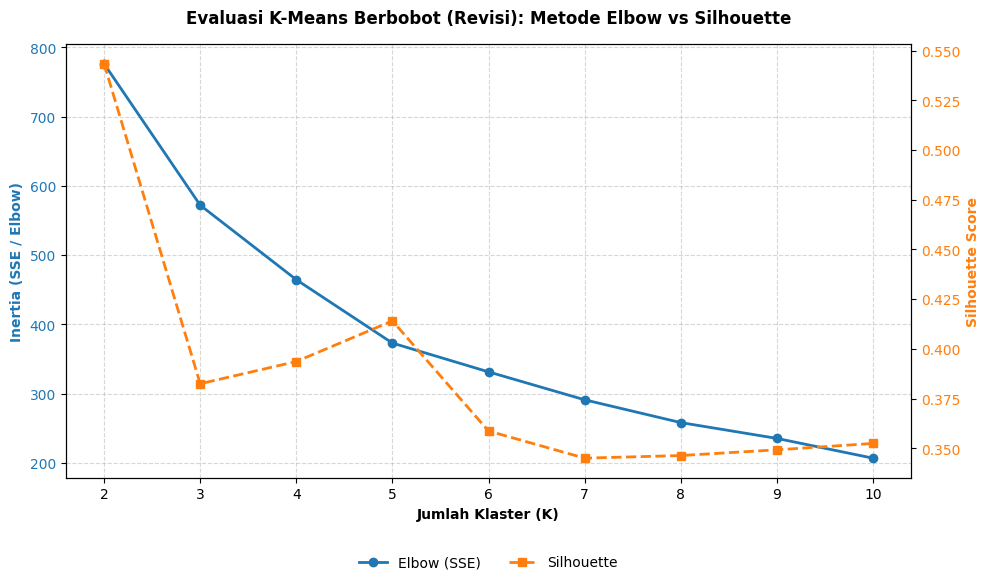


Lokasi Simpan : /content/drive/My Drive/SKRIPSI/PROGRAM2/5_Data_OptunaWeighting.xlsx

Tampilan 5 Baris Pertama:


,ID_Pasien,Nama,W_Worst_SE,W_Usia,W_Lat,W_Lon,W_Gender_Enc
0,1,D** W** M** S**,1.310146,0.120607,0.984289,0.367401,0.000000
1,2,T** A**,1.556986,0.150759,0.772713,0.909317,0.050505
2,3,E** A** W**,1.443060,0.407050,0.703721,1.093017,0.050505
3,4,R** R** A**,1.082295,0.391974,0.703721,1.093017,0.050505
4,5,E** P**,1.424072,0.211063,0.772713,0.909317,0.000000


-----------------------------------------------------------------


In [ ]:
# =============================================================================
# PART 5 (REVISI): OPTIMASI BEBAN (OPTUNA) - PRIORITAS WORST_SE
# =============================================================================
import sys
!{sys.executable} -m pip install optuna > /dev/null 2>&1
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

path_drive = '/content/drive/My Drive/SKRIPSI/PROGRAM2'
file_input = os.path.join(path_drive, '4_Data_Normalisasi.xlsx')
df = pd.read_excel(file_input)

print("[LAPORAN TAHAP 5 REVISI: OPTIMASI PEMBOBOTAN - PRIORITAS WORST_SE]")
print("-" * 65)

kolom_skala = ['S_Gender_Enc', 'S_Usia', 'S_Lat', 'S_Lon', 'S_Worst_SE']
X_base = df[kolom_skala].copy()

def fungsi_objektif(trial):
    # Worst_SE diberi ruang dominan yang jauh lebih luas
    w_myopia = trial.suggest_float('w_myopia', 1.60, 2.20)
    # Usia diturunkan agar tidak bisa menyaingi Worst_SE
    w_usia   = trial.suggest_float('w_usia',   0.80, 1.10)
    # Spasial tetap moderat
    w_lat    = trial.suggest_float('w_lat',    0.85, 1.10)
    w_lon    = trial.suggest_float('w_lon',    0.85, 1.10)
    # Gender tetap ditekan
    w_gender = trial.suggest_float('w_gender', 0.05, 0.15)

    k = trial.suggest_int('k', 4, 7)

    X_iter = X_base.copy()
    X_iter['S_Worst_SE']   *= w_myopia
    X_iter['S_Usia']       *= w_usia
    X_iter['S_Lat']        *= w_lat
    X_iter['S_Lon']        *= w_lon
    X_iter['S_Gender_Enc'] *= w_gender

    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(X_iter)
    return silhouette_score(X_iter, labels)

N_TRIALS = 150
sampler_pintar = optuna.samplers.TPESampler(
    multivariate=True,
    n_startup_trials=30,
    seed=42
)

def progress_callback(study, trial):
    progress = (trial.number + 1) / N_TRIALS * 100
    sys.stdout.write(f"\rStatus Sistem : Memproses... {progress:.2f}% Selesai")
    sys.stdout.flush()

print("Status Sistem : Memproses... 0.00% Selesai", end='')
study = optuna.create_study(direction='maximize', sampler=sampler_pintar)
study.optimize(fungsi_objektif, n_trials=N_TRIALS, callbacks=[progress_callback])

best_params = study.best_trial.params
print("\nStatus Sistem : Proses optimasi Optuna selesai.\n")

print("--- REKOMENDASI PARAMETER OPTIMAL ---")
print(f"Rekomendasi Jumlah Klaster (K) : {best_params['k']}")
print(f"Estimasi Silhouette Score      : {study.best_value:.4f}")
print("Pengali Beban Worst_SE         :", round(best_params['w_myopia'], 3))
print("Pengali Beban Usia             :", round(best_params['w_usia'], 3))
print("Pengali Beban Spasial (Lat/Lon):", round(best_params['w_lat'], 3), "/", round(best_params['w_lon'], 3))
print("Pengali Beban Gender           :", round(best_params['w_gender'], 3))

# Terapkan bobot
df['W_Worst_SE']   = df['S_Worst_SE'] * best_params['w_myopia']
df['W_Usia']       = df['S_Usia']     * best_params['w_usia']
df['W_Lat']        = df['S_Lat']      * best_params['w_lat']
df['W_Lon']        = df['S_Lon']      * best_params['w_lon']
df['W_Gender_Enc'] = df['S_Gender_Enc'] * best_params['w_gender']

# =============================================================================
# EVALUASI GRAFIK ELBOW VS SILHOUETTE
# =============================================================================
print("\nStatus Sistem : Membangun Grafik Evaluasi (K=2 hingga K=10)...")
kolom_bobot = ['W_Worst_SE', 'W_Usia', 'W_Lat', 'W_Lon', 'W_Gender_Enc']
X_final = df[kolom_bobot]

sse, sil = [], []
range_k  = range(2, 11)

for k in range_k:
    km_eval     = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels_eval = km_eval.fit_predict(X_final)
    sse.append(km_eval.inertia_)
    sil.append(silhouette_score(X_final, labels_eval))

fig, ax1 = plt.subplots(figsize=(10, 6))
color1 = '#1f77b4'
ax1.set_xlabel('Jumlah Klaster (K)', fontweight='bold')
ax1.set_ylabel('Inertia (SSE / Elbow)', color=color1, fontweight='bold')
line1, = ax1.plot(range_k, sse, marker='o', color=color1, linewidth=2, label='Elbow (SSE)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range_k)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color2 = '#ff7f0e'
ax2.set_ylabel('Silhouette Score', color=color2, fontweight='bold')
line2, = ax2.plot(range_k, sil, marker='s', color=color2,
                  linestyle='--', linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color2)

lines  = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.title('Evaluasi K-Means Berbobot (Revisi): Metode Elbow vs Silhouette',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Simpan
kolom_akhir = ['ID_Pasien', 'Nama'] + kolom_bobot
df = df[kolom_akhir]
file_output = os.path.join(path_drive, '5_Data_OptunaWeighting.xlsx')
df.to_excel(file_output, index=False)
print(f"\nLokasi Simpan : {file_output}")
print("\nTampilan 5 Baris Pertama:")
display(df.head())
print("-" * 65)

In [ ]:
# =============================================================================
# PART 6 (ENHANCED): EKSEKUSI K-MEANS + HYPERPARAMETER CENTROID SEARCH
# =============================================================================
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.metrics import silhouette_score
import os
import warnings
warnings.filterwarnings('ignore')

# 1. Setup Data
path_drive = '/content/drive/My Drive/SKRIPSI/PROGRAM2'
file_input = os.path.join(path_drive, '5_Data_OptunaWeighting.xlsx')
df = pd.read_excel(file_input)

print("[LAPORAN TAHAP 6 ENHANCED: HYPERPARAMETER SEARCH + K-MEANS]")
print("-" * 75)

kolom_bobot = [col for col in df.columns if col.startswith('W_')]
X_final     = df[kolom_bobot].values
K_OPTIMAL   = 5

# =============================================================================
# PRA-FASE: PENCARIAN SEED TERBAIK (HYPERPARAMETER SEARCH)
# =============================================================================
print("\n>>> [PRA-FASE: PENCARIAN CENTROID AWAL TERBAIK]")
print("Status Sistem : Mengevaluasi 200 kombinasi seed untuk kmeans++...")

N_SEEDS      = 200
hasil_search = []

for seed in range(N_SEEDS):
    # Coba inisialisasi centroid dengan seed ini
    centers_coba, _ = kmeans_plusplus(X_final, n_clusters=K_OPTIMAL, random_state=seed)

    # Jalankan KMeans penuh dengan centroid tersebut
    km_coba = KMeans(
        n_clusters=K_OPTIMAL,
        init=centers_coba,
        n_init=1,
        max_iter=500,
        random_state=seed
    )
    labels_coba = km_coba.fit_predict(X_final)

    # Evaluasi dengan Silhouette Score
    sil   = silhouette_score(X_final, labels_coba)
    inert = km_coba.inertia_

    hasil_search.append({
        'seed'       : seed,
        'silhouette' : sil,
        'inertia'    : inert,
        'n_iter'     : km_coba.n_iter_
    })

    # Progress setiap 20 seed
    if (seed + 1) % 20 == 0:
        print(f"  Progress: {seed+1}/{N_SEEDS} seed dievaluasi...")

# Konversi ke DataFrame dan cari yang terbaik
df_search = pd.DataFrame(hasil_search).sort_values('silhouette', ascending=False)
best_seed  = int(df_search.iloc[0]['seed'])
best_sil   = df_search.iloc[0]['silhouette']
best_inert = df_search.iloc[0]['inertia']

print(f"\n--- HASIL PENCARIAN SEED ---")
print(f"Seed Terbaik          : {best_seed}")
print(f"Silhouette Terbaik    : {best_sil:.4f}")
print(f"Inertia (SSE) Terbaik : {best_inert:.4f}")
print(f"\nTop 5 Seed Terbaik:")
display(df_search.head())
print("-" * 75)

# =============================================================================
# FASE 1: INISIALISASI CENTROID AWAL MENGGUNAKAN SEED TERBAIK
# =============================================================================
print("\n>>> [FASE 1: PENENTUAN CENTROID AWAL — SEED TERPILIH]")
centers_init, indices = kmeans_plusplus(
    X_final, n_clusters=K_OPTIMAL, random_state=best_seed
)

df_centroid_awal = pd.DataFrame(centers_init, columns=kolom_bobot)
df_centroid_awal.index = [
    f"Centroid {i+1} (Diambil dari Baris ke-{indices[i]})"
    for i in range(K_OPTIMAL)
]

print(f"Sistem memilih {K_OPTIMAL} centroid awal menggunakan seed terbaik (seed={best_seed}):")
display(df_centroid_awal)
print("-" * 75)

# =============================================================================
# FASE 2: ITERASI PERTAMA (SIMULASI)
# =============================================================================
print("\n>>> [FASE 2: PROSES ITERASI KE-1]")
kmeans_iter1 = KMeans(
    n_clusters=K_OPTIMAL,
    init=centers_init,
    n_init=1,
    max_iter=1,
    random_state=best_seed
)
kmeans_iter1.fit(X_final)

df_iter1               = df.copy()
df_iter1['Klaster_Iter1'] = kmeans_iter1.labels_ + 1

df_centroid_iter1 = pd.DataFrame(kmeans_iter1.cluster_centers_, columns=kolom_bobot)
df_centroid_iter1.index = [
    f"Centroid {i+1} (Setelah Iterasi 1)" for i in range(K_OPTIMAL)
]

print("Koordinat Centroid bergeser setelah perhitungan jarak pertama:")
display(df_centroid_iter1)

print("\nPreview 5 Data Pertama (Hasil Pembagian Iterasi 1):")
kolom_tampil = ['ID_Pasien', 'Nama'] + kolom_bobot + ['Klaster_Iter1']
display(df_iter1[kolom_tampil].head())
print("-" * 75)

# =============================================================================
# FASE 3: KONVERGENSI FINAL
# =============================================================================
print("\n>>> [FASE 3: PERHITUNGAN HINGGA KONVERGEN]")
print("Status Sistem : Mesin melanjutkan iterasi untuk mencari posisi paling stabil...")

kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    init=centers_init,
    n_init=1,
    max_iter=500,
    random_state=best_seed
)
kmeans_final.fit(X_final)

df['Klaster'] = kmeans_final.labels_ + 1

print(f"Status Sistem : BINGO! Konvergen pada iterasi ke-{kmeans_final.n_iter_}.")

df_centroid_final = pd.DataFrame(kmeans_final.cluster_centers_, columns=kolom_bobot)
df_centroid_final.index = [
    f"Centroid {i+1} Final" for i in range(K_OPTIMAL)
]

print("\nKoordinat Centroid Final (Sudah Tidak Bergeser Lagi):")
display(df_centroid_final)

print("\nJumlah Populasi Tiap Klaster:")
display(df['Klaster'].value_counts().sort_index()
        .rename_axis('Klaster').reset_index(name='Jumlah Data'))

print("\nPreview 5 Data Pertama dengan Klaster Final:")
kolom_final = ['ID_Pasien', 'Nama'] + kolom_bobot + ['Klaster']
display(df[kolom_final].head())

# =============================================================================
# LAPORAN PERBANDINGAN
# =============================================================================
print("\n--- LAPORAN PERBANDINGAN KUALITAS ---")
sil_final = silhouette_score(X_final, kmeans_final.labels_)
print(f"Silhouette Score Final  : {sil_final:.4f}")
print(f"Inertia (SSE) Final     : {kmeans_final.inertia_:.4f}")
print(f"Jumlah Iterasi          : {kmeans_final.n_iter_}")
print(f"Seed yang Digunakan     : {best_seed}")
print("-" * 75)

# =============================================================================
# PENYIMPANAN
# =============================================================================
file_output = os.path.join(path_drive, '6_Hasil_KMeans.xlsx')
df.to_excel(file_output, index=False)

print(f"\nStatus Sistem : Seluruh proses klastering selesai dan terekam.")
print(f"Lokasi Simpan : {file_output}")
print("-" * 75)

[LAPORAN TAHAP 6 ENHANCED: HYPERPARAMETER SEARCH + K-MEANS]
---------------------------------------------------------------------------

>>> [PRA-FASE: PENCARIAN CENTROID AWAL TERBAIK]
Status Sistem : Mengevaluasi 200 kombinasi seed untuk kmeans++...
  Progress: 20/200 seed dievaluasi...
  Progress: 40/200 seed dievaluasi...
  Progress: 60/200 seed dievaluasi...
  Progress: 80/200 seed dievaluasi...
  Progress: 100/200 seed dievaluasi...
  Progress: 120/200 seed dievaluasi...
  Progress: 140/200 seed dievaluasi...
  Progress: 160/200 seed dievaluasi...
  Progress: 180/200 seed dievaluasi...
  Progress: 200/200 seed dievaluasi...

--- HASIL PENCARIAN SEED ---
Seed Terbaik          : 2
Silhouette Terbaik    : 0.4144
Inertia (SSE) Terbaik : 373.0999

Top 5 Seed Terbaik:


,seed,silhouette,inertia,n_iter
2,2,0.414433,373.099858,20
35,35,0.414433,373.099927,16
34,34,0.414433,373.099858,17
71,71,0.414433,373.099927,16
54,54,0.414433,373.099858,20


---------------------------------------------------------------------------

>>> [FASE 1: PENENTUAN CENTROID AWAL — SEED TERPILIH]
Sistem memilih 5 centroid awal menggunakan seed terbaik (seed=2):


,W_Worst_SE,W_Usia,W_Lat,W_Lon,W_Gender_Enc
Centroid 1 (Diambil dari Baris ke-2973),1.471541,0.331670,0.772713,0.909317,0.000000
Centroid 2 (Diambil dari Baris ke-3068),1.528504,0.587961,0.984289,0.367401,0.050505
Centroid 3 (Diambil dari Baris ke-1483),1.414578,0.180911,0.906098,0.000000,0.050505
Centroid 4 (Diambil dari Baris ke-2061),1.063307,0.482429,0.772713,0.909317,0.000000
Centroid 5 (Diambil dari Baris ke-3660),1.556986,0.799024,0.772713,0.909317,0.050505


---------------------------------------------------------------------------

>>> [FASE 2: PROSES ITERASI KE-1]
Koordinat Centroid bergeser setelah perhitungan jarak pertama:


...


Jumlah Populasi Tiap Klaster:


,Klaster,Jumlah Data
0,1,3022
1,2,110
2,3,1157
3,4,891
4,5,1641



Preview 5 Data Pertama dengan Klaster Final:


,ID_Pasien,Nama,W_Worst_SE,W_Usia,W_Lat,W_Lon,W_Gender_Enc,Klaster
0,1,D** W** M** S**,1.310146,0.120607,0.984289,0.367401,0.000000,3
1,2,T** A**,1.556986,0.150759,0.772713,0.909317,0.050505,1
2,3,E** A** W**,1.443060,0.407050,0.703721,1.093017,0.050505,1
3,4,R** R** A**,1.082295,0.391974,0.703721,1.093017,0.050505,4
4,5,E** P**,1.424072,0.211063,0.772713,0.909317,0.000000,1



--- LAPORAN PERBANDINGAN KUALITAS ---
Silhouette Score Final  : 0.4144
Inertia (SSE) Final     : 373.0999
Jumlah Iterasi          : 20
Seed yang Digunakan     : 2
---------------------------------------------------------------------------

Status Sistem : Seluruh proses klastering selesai dan terekam.
Lokasi Simpan : /content/drive/My Drive/SKRIPSI/PROGRAM2/6_Hasil_KMeans.xlsx
---------------------------------------------------------------------------


In [ ]:
# =============================================================================
# PART 7: EVALUASI SILHOUETTE PER BARIS a(i), b(i), s(i)
# =============================================================================
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances
import os

# 1. Setup Data
path_drive = '/content/drive/My Drive/SKRIPSI/PROGRAM2'
file_input = os.path.join(path_drive, '6_Hasil_KMeans.xlsx')
df = pd.read_excel(file_input)

print("[LAPORAN TAHAP 7: UJI VALIDASI SILHOUETTE PER PASIEN]")
print("-" * 75)

# Mengambil kolom bobot saja (W_) untuk perhitungan jarak matematis
kolom_bobot = [col for col in df.columns if col.startswith('W_')]
X_final = df[kolom_bobot].values
labels = df['Klaster'].values - 1 # Kembalikan ke index 0 agar perhitungan array sinkron

n_pasien = len(df)
K_OPTIMAL = len(np.unique(labels))

print("Status Sistem : Menghitung matriks jarak Euclidean antar seluruh pasien...")
# Menghitung jarak antar semua pasangan titik data
matriks_jarak = pairwise_distances(X_final)

a_vals = np.zeros(n_pasien)
b_vals = np.zeros(n_pasien)
s_vals = np.zeros(n_pasien)

# 2. Perhitungan a(i) dan b(i) secara sekuensial (Sesuai Rumus Teori)
print("Status Sistem : Melakukan komputasi nilai a(i) dan b(i) per individu...")
for i in range(n_pasien):
    klaster_i = labels[i]

    # a(i): Jarak rata-rata ke teman satu klaster (Intra-cluster distance)
    mask_a = (labels == klaster_i)
    mask_a[i] = False # Jarak ke diri sendiri tidak dihitung (harus nol)
    if np.sum(mask_a) > 0:
        a_vals[i] = np.mean(matriks_jarak[i, mask_a])
    else:
        a_vals[i] = 0

    # b(i): Jarak rata-rata ke klaster tetangga terdekat (Inter-cluster distance)
    b_min = np.inf
    for klaster_lain in range(K_OPTIMAL):
        if klaster_lain != klaster_i:
            mask_b = (labels == klaster_lain)
            mean_dist = np.mean(matriks_jarak[i, mask_b])
            if mean_dist < b_min:
                b_min = mean_dist
    b_vals[i] = b_min

    # s(i): Skor Silhouette individu
    max_ab = max(a_vals[i], b_vals[i])
    if max_ab > 0:
        s_vals[i] = (b_vals[i] - a_vals[i]) / max_ab
    else:
        s_vals[i] = 0

# 3. Penggabungan Hasil ke DataFrame
df['a(i)'] = np.round(a_vals, 4)
df['b(i)'] = np.round(b_vals, 4)
df['s(i)'] = np.round(s_vals, 4)

# 4. Laporan Hasil Validasi
print(f"Status Sistem : Validasi Matematis Selesai!")
print(f"Rata-rata Skor Silhouette Keseluruhan : {np.mean(s_vals):.4f}")
print("-" * 75)

kolom_tampil = ['ID_Pasien', 'Nama', 'Klaster', 'a(i)', 'b(i)', 's(i)']
print("Preview 5 Data Pertama dengan Skor Evaluasi:")
display(df[kolom_tampil].head())

# 5. Penyimpanan Excel dengan nama file baru sesuai permintaan
file_output = os.path.join(path_drive, '7_Hasil_Evaluasi_Silhouette.xlsx')
df.to_excel(file_output, index=False)

print("-" * 75)
print(f"Lokasi Simpan Data Evaluasi : {file_output}")
print("-" * 75)

[LAPORAN TAHAP 7: UJI VALIDASI SILHOUETTE PER PASIEN]
---------------------------------------------------------------------------
Status Sistem : Menghitung matriks jarak Euclidean antar seluruh pasien...
Status Sistem : Melakukan komputasi nilai a(i) dan b(i) per individu...
Status Sistem : Validasi Matematis Selesai!
Rata-rata Skor Silhouette Keseluruhan : 0.4144
---------------------------------------------------------------------------
Preview 5 Data Pertama dengan Skor Evaluasi:


,ID_Pasien,Nama,Klaster,a(i),b(i),s(i)
0,1,D** W** M** S**,3,0.4071,0.6480,0.3717
1,2,T** A**,1,0.1704,0.4949,0.6557
2,3,E** A** W**,1,0.3099,0.3254,0.0477
3,4,R** R** A**,4,0.3222,0.4933,0.3470
4,5,E** P**,1,0.1668,0.4174,0.6005


---------------------------------------------------------------------------
Lokasi Simpan Data Evaluasi : /content/drive/My Drive/SKRIPSI/PROGRAM2/7_Hasil_Evaluasi_Silhouette.xlsx
---------------------------------------------------------------------------


In [ ]:
# =============================================================================
# PART 8: DENORMALISASI DATA
# =============================================================================
import pandas as pd
import os

# 1. Setup Data
path_drive = '/content/drive/My Drive/SKRIPSI/PROGRAM2'

# Load the clustered and evaluated data
file_input_cluster = os.path.join(path_drive, '7_Hasil_Evaluasi_Silhouette.xlsx')
df_clustered_eval = pd.read_excel(file_input_cluster)

# Load the pre-processed data which contains original features like Gender, Usia, Alamat, R_SPH, etc.
file_input_raw_features = os.path.join(path_drive, '2_Data_Prepoccessing.xlsx')
df_raw_features = pd.read_excel(file_input_raw_features)

print("[LAPORAN TAHAP 8: DENORMALISASI DATA FINAL]")
print("-" * 75)

# 2. Re-calculate derived features (Worst_SE, Lat, Lon) using original data
# This logic is copied from PART 3
df_raw_features['Worst_SE'] = df_raw_features[['R_SPH', 'L_SPH']].min(axis=1) + (df_raw_features[['R_CYL', 'L_CYL']].min(axis=1) / 2)

koordinat_blitar = {
    'BAKUNG': (-8.258, 112.074),
    'PONGGOK': (-8.044, 112.101),
    'SANANWETAN': (-8.105, 112.180),
    'SRENGAT': (-8.061, 112.061)
}
df_raw_features['Lat'] = df_raw_features['Alamat'].map(lambda x: koordinat_blitar.get(x, (-8.09, 112.16))[0])
df_raw_features['Lon'] = df_raw_features['Alamat'].map(lambda x: koordinat_blitar.get(x, (-8.09, 112.16))[1])

# 3. Merge the original features with cluster results (excluding evaluation metrics)
# We only need ID_Pasien and Klaster from df_clustered_eval for the final output
df_merge_cols = df_clustered_eval[['ID_Pasien', 'Klaster']]

df_final = pd.merge(df_raw_features,
                    df_merge_cols,
                    on='ID_Pasien',
                    how='left')

print(f"Status Sistem : Menggabungkan fitur asli dengan hasil klastering.")
print("Status Sistem : Mengembalikan data ke satuan asli (Tahun, Dioptri, Koordinat).")

# 4. Penataan Ulang Kolom agar Rapi
# Kolom evaluasi a(i), b(i), s(i) serta Lat/Lon TIDAK disertakan dalam output final.
kolom_klaster = ['Klaster']
kolom_identitas_dan_fitur = ['ID_Pasien', 'Nama', 'Gender', 'Usia', 'Alamat', 'Worst_SE'] # Lat dan Lon dihilangkan

# Gabungkan urutan kolom
urutan_final = kolom_identitas_dan_fitur + kolom_klaster
df_final = df_final[urutan_final]

# 5. Penyimpanan Hasil Final
file_output = os.path.join(path_drive, '8_Data_Denormalisasi.xlsx')
df_final.to_excel(file_output, index=False)

print("-" * 75)
print("Preview 5 Data Hasil Denormalisasi:")
display(df_final.head())

print("-" * 75)
print(f"Status Sistem : Denormalisasi selesai.")
print(f"Lokasi Simpan : {file_output}")
print("-" * 75)

[LAPORAN TAHAP 8: DENORMALISASI DATA FINAL]
---------------------------------------------------------------------------
Status Sistem : Menggabungkan fitur asli dengan hasil klastering.
Status Sistem : Mengembalikan data ke satuan asli (Tahun, Dioptri, Koordinat).
---------------------------------------------------------------------------
Preview 5 Data Hasil Denormalisasi:


,ID_Pasien,Nama,Gender,Usia,Alamat,Worst_SE,Klaster
0,1,D** W** M** S**,L,18,PONGGOK,-4.25,3
1,2,T** A**,P,20,SELOPURO,-1.00,1
2,3,E** A** W**,P,37,SANANWETAN,-2.50,1
3,4,R** R** A**,P,36,SANANWETAN,-7.25,4
4,5,E** P**,L,24,BINANGUN,-2.75,1


---------------------------------------------------------------------------
Status Sistem : Denormalisasi selesai.
Lokasi Simpan : /content/drive/My Drive/SKRIPSI/PROGRAM2/8_Data_Denormalisasi.xlsx
---------------------------------------------------------------------------


  PART 8: PROFILING & VISUALISASI LENGKAP K-MEANS

✓ Data berhasil dimuat  : 6821 pasien
✓ Jumlah klaster        : 5  → [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
✓ Output folder         : /content/drive/My Drive/SKRIPSI/PROGRAM2/GRAFIK_PROFILING


[SEKSI 1] Dashboard Per Klaster...


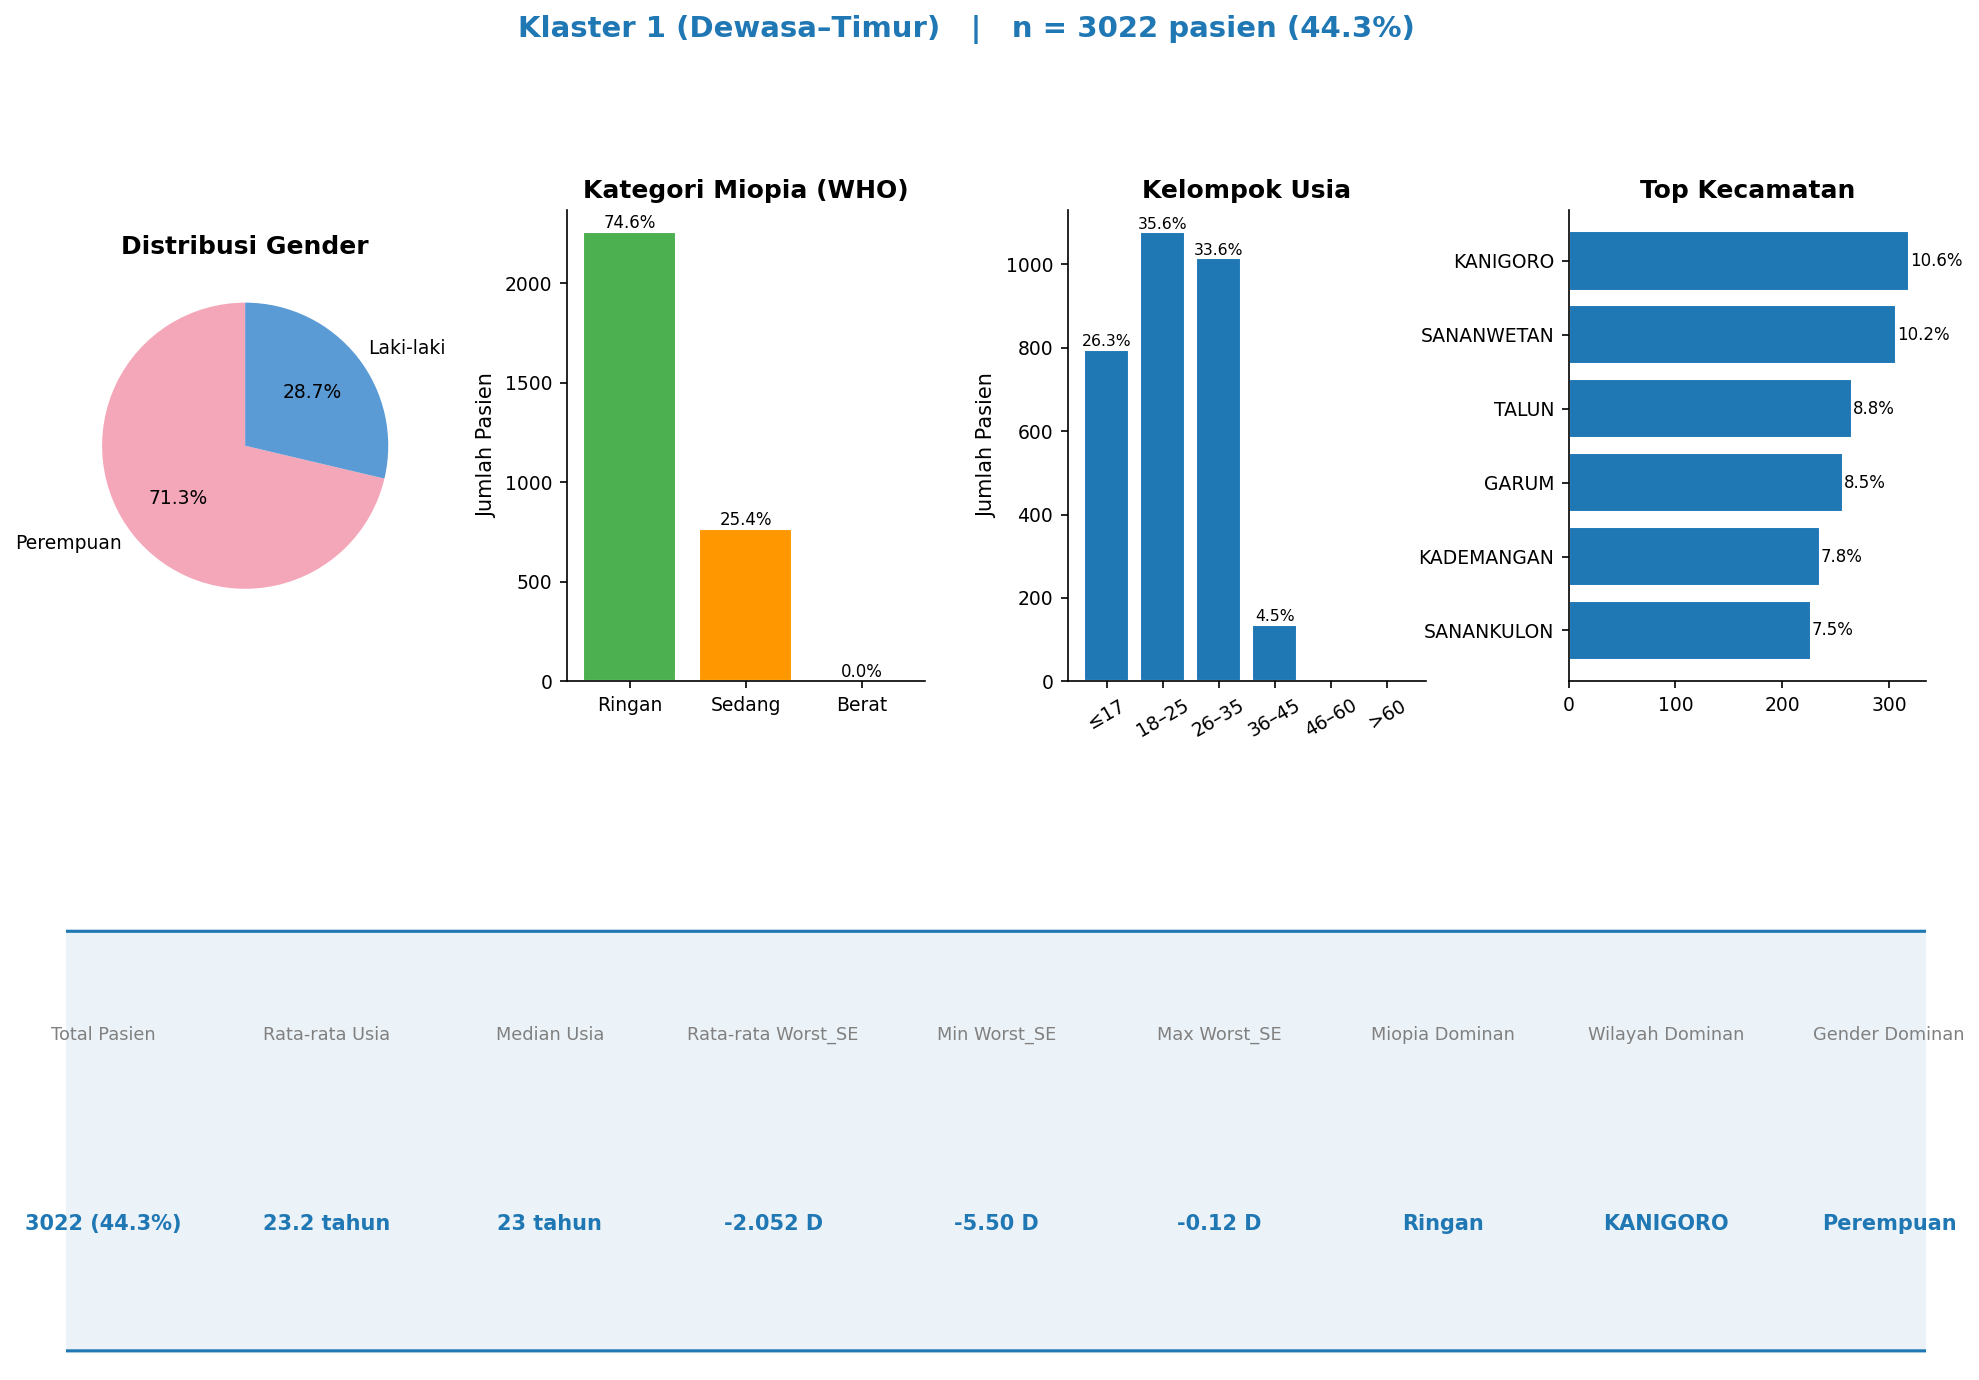

  ✓ Tersimpan → Chart_01_01_Dashboard_Klaster_1.png


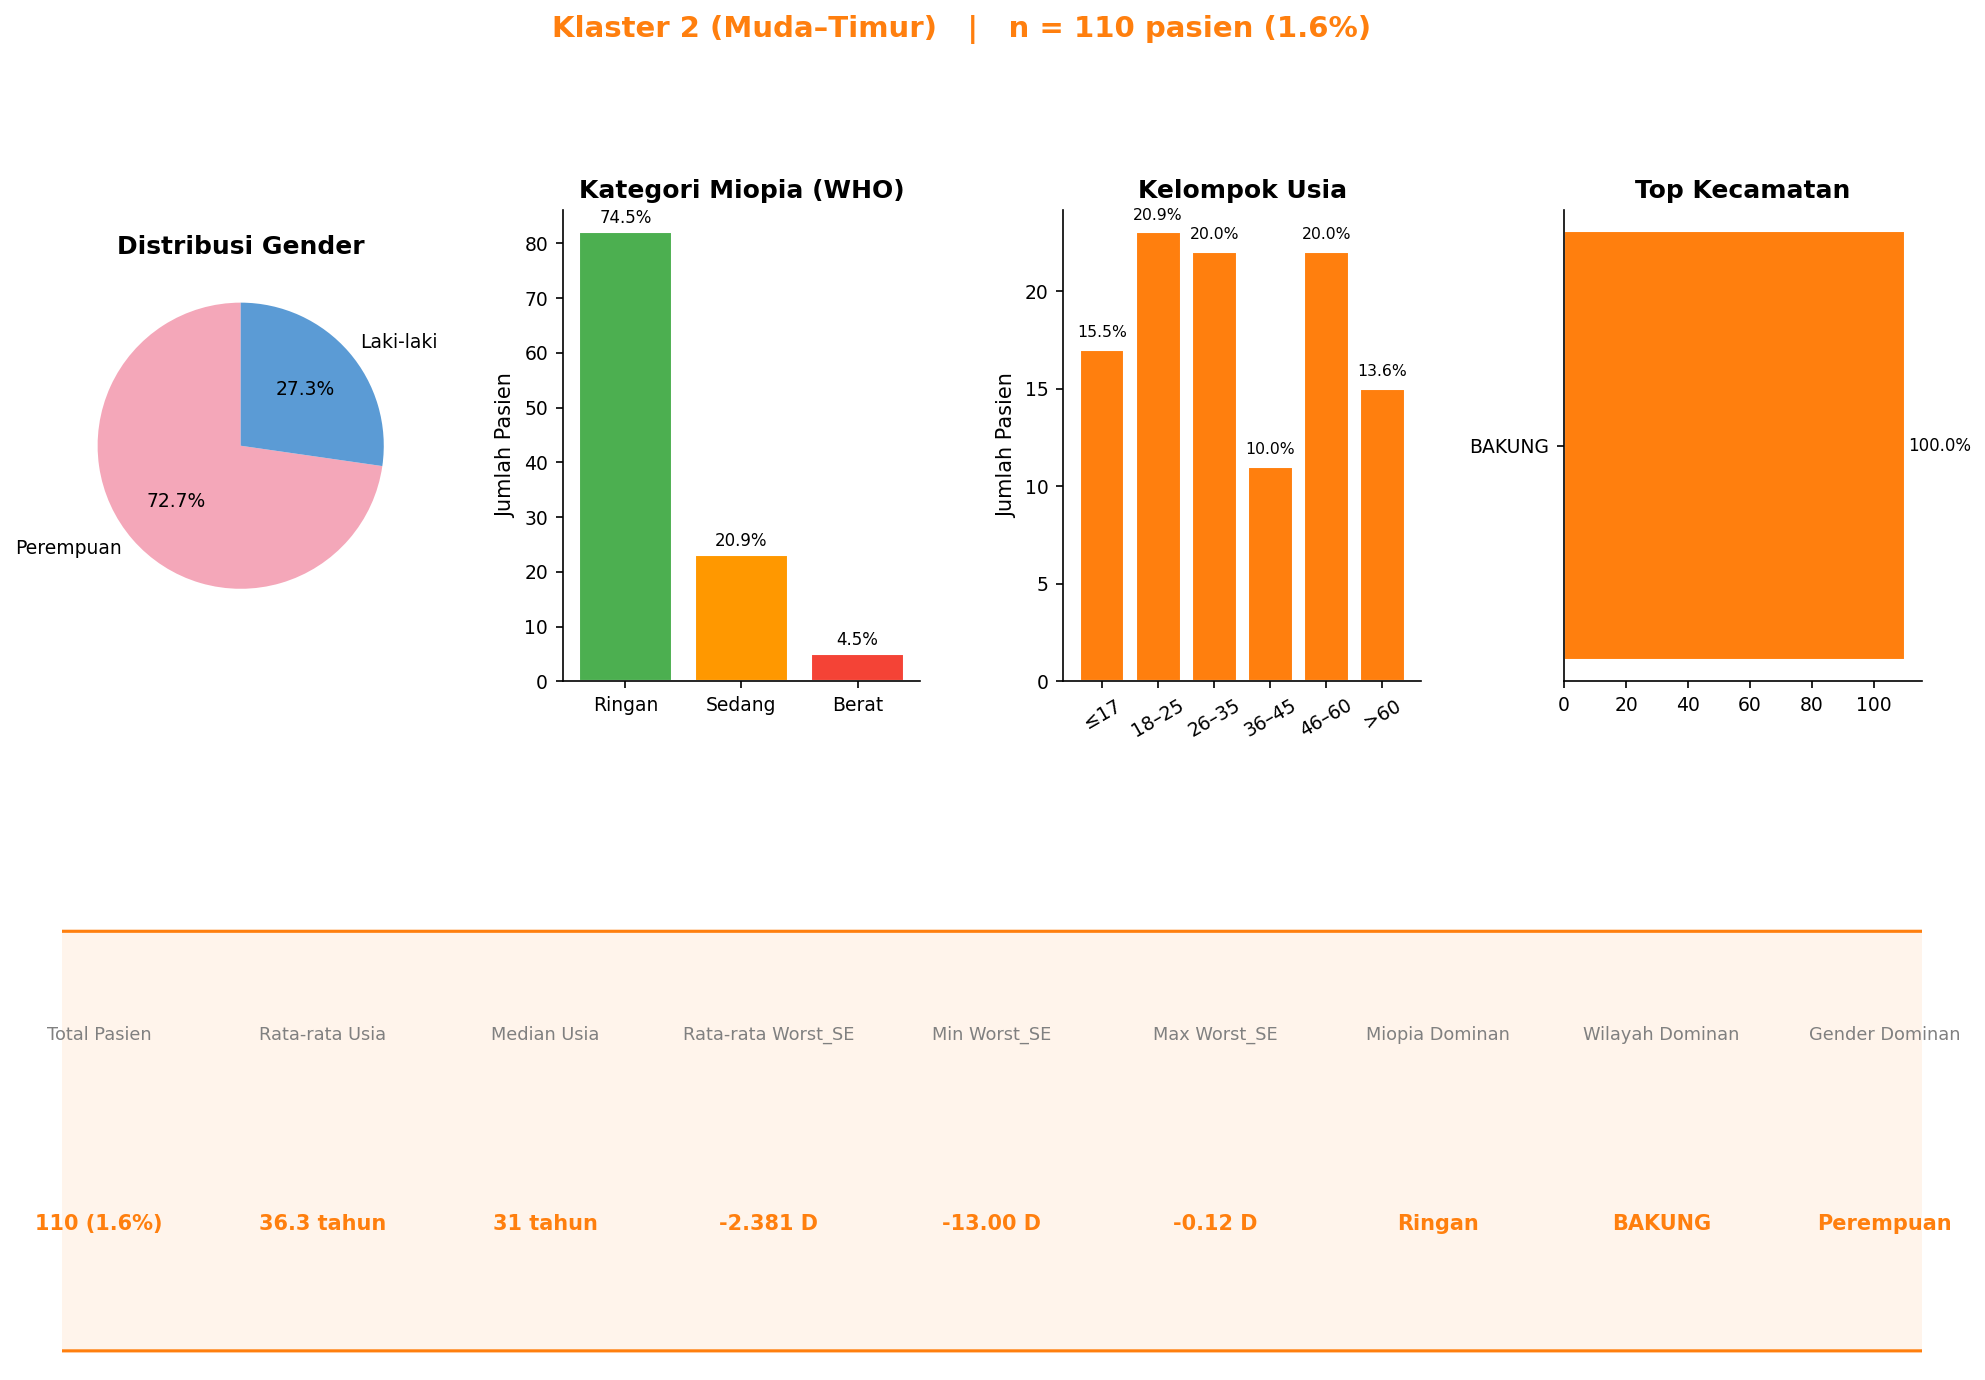

  ✓ Tersimpan → Chart_01_02_Dashboard_Klaster_2.png


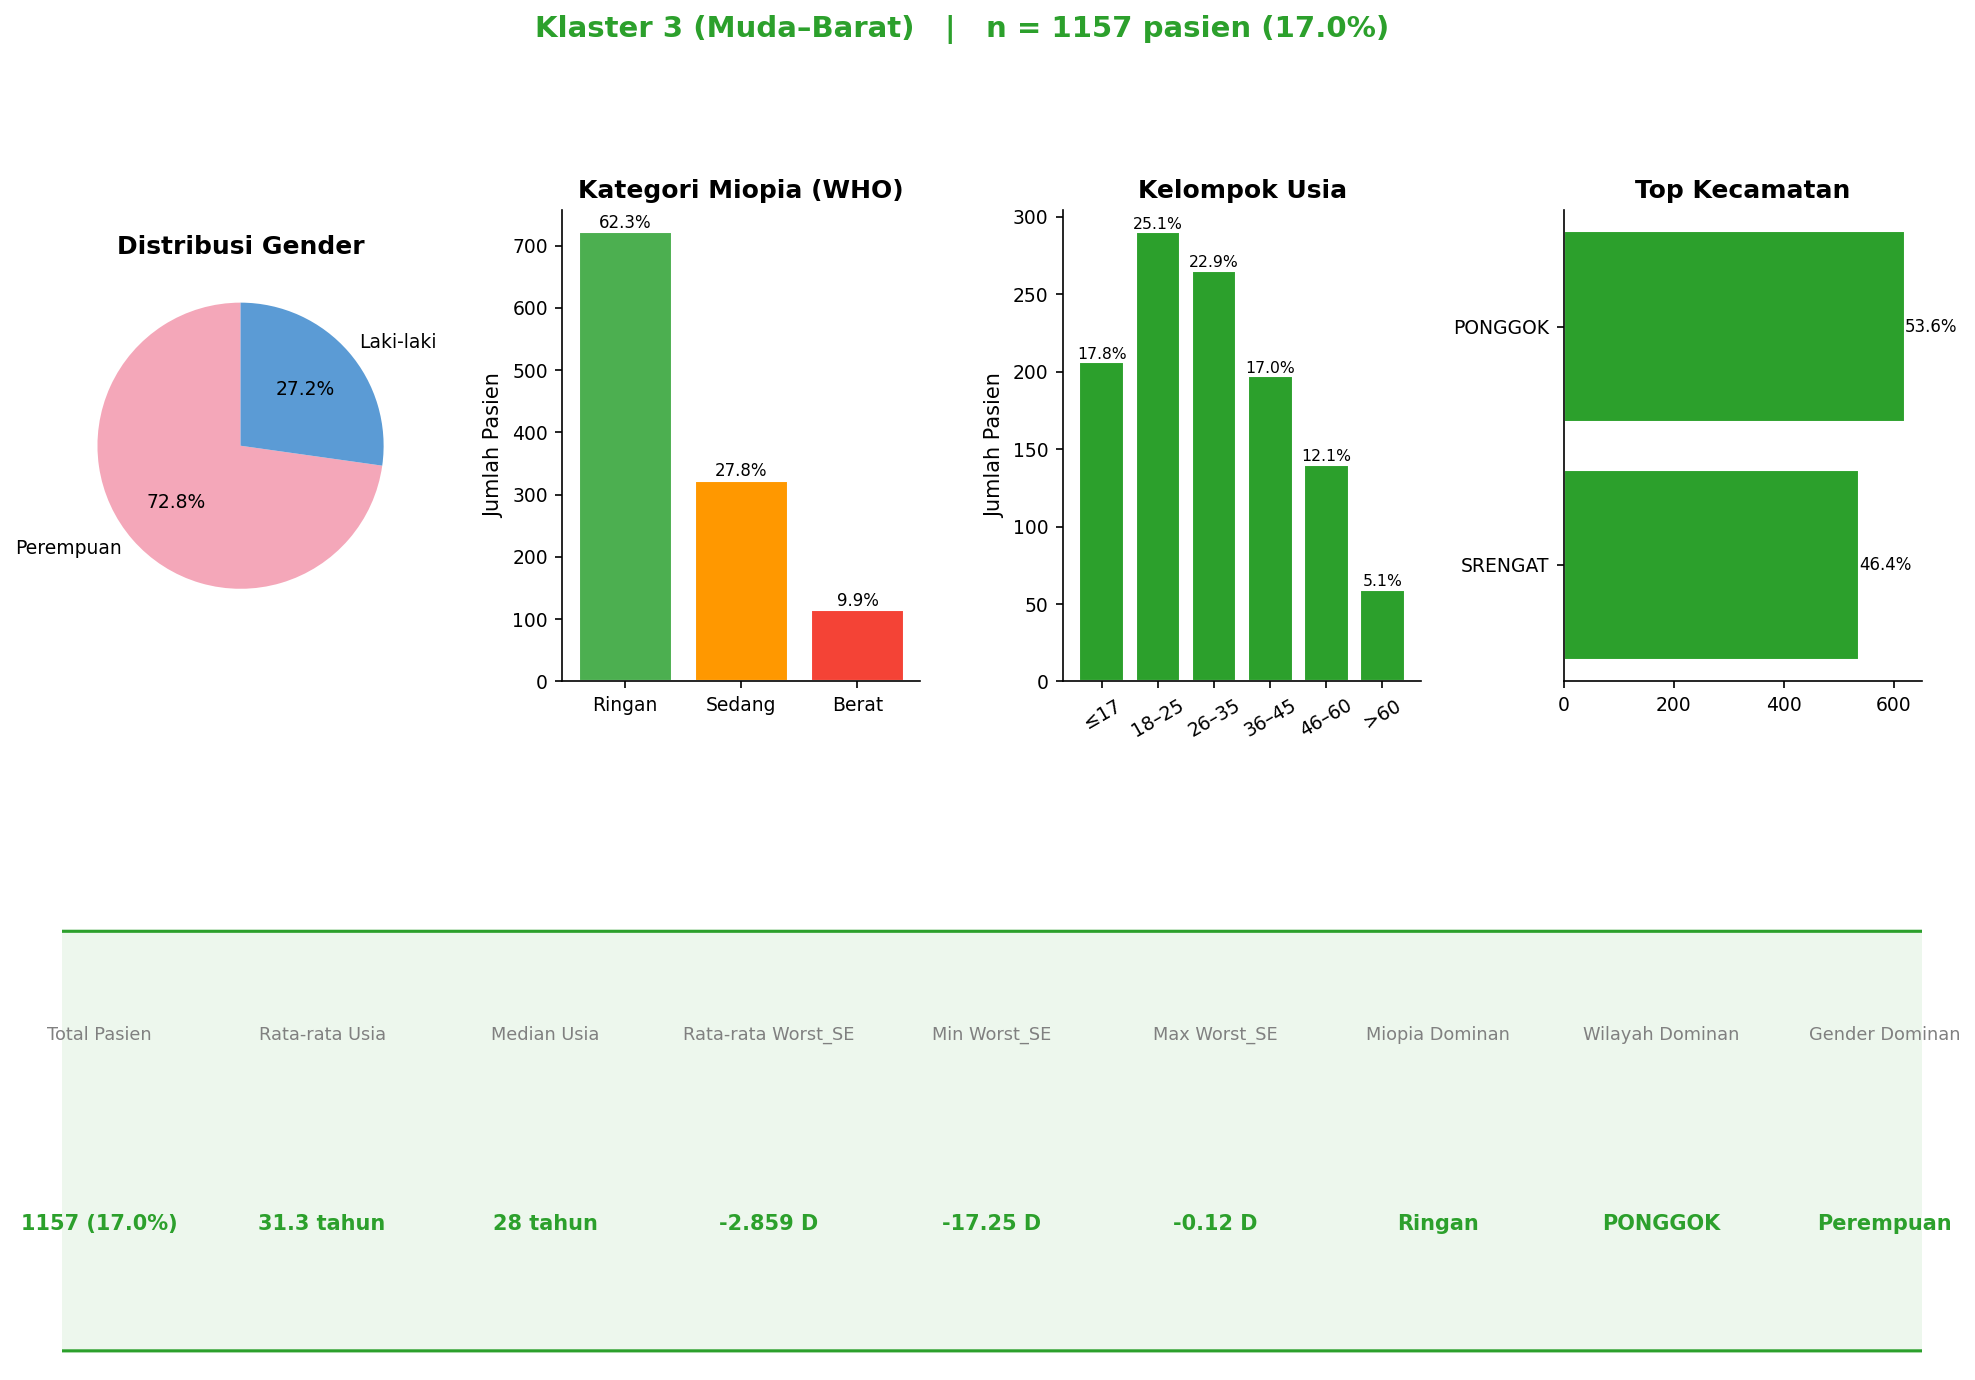

  ✓ Tersimpan → Chart_01_03_Dashboard_Klaster_3.png


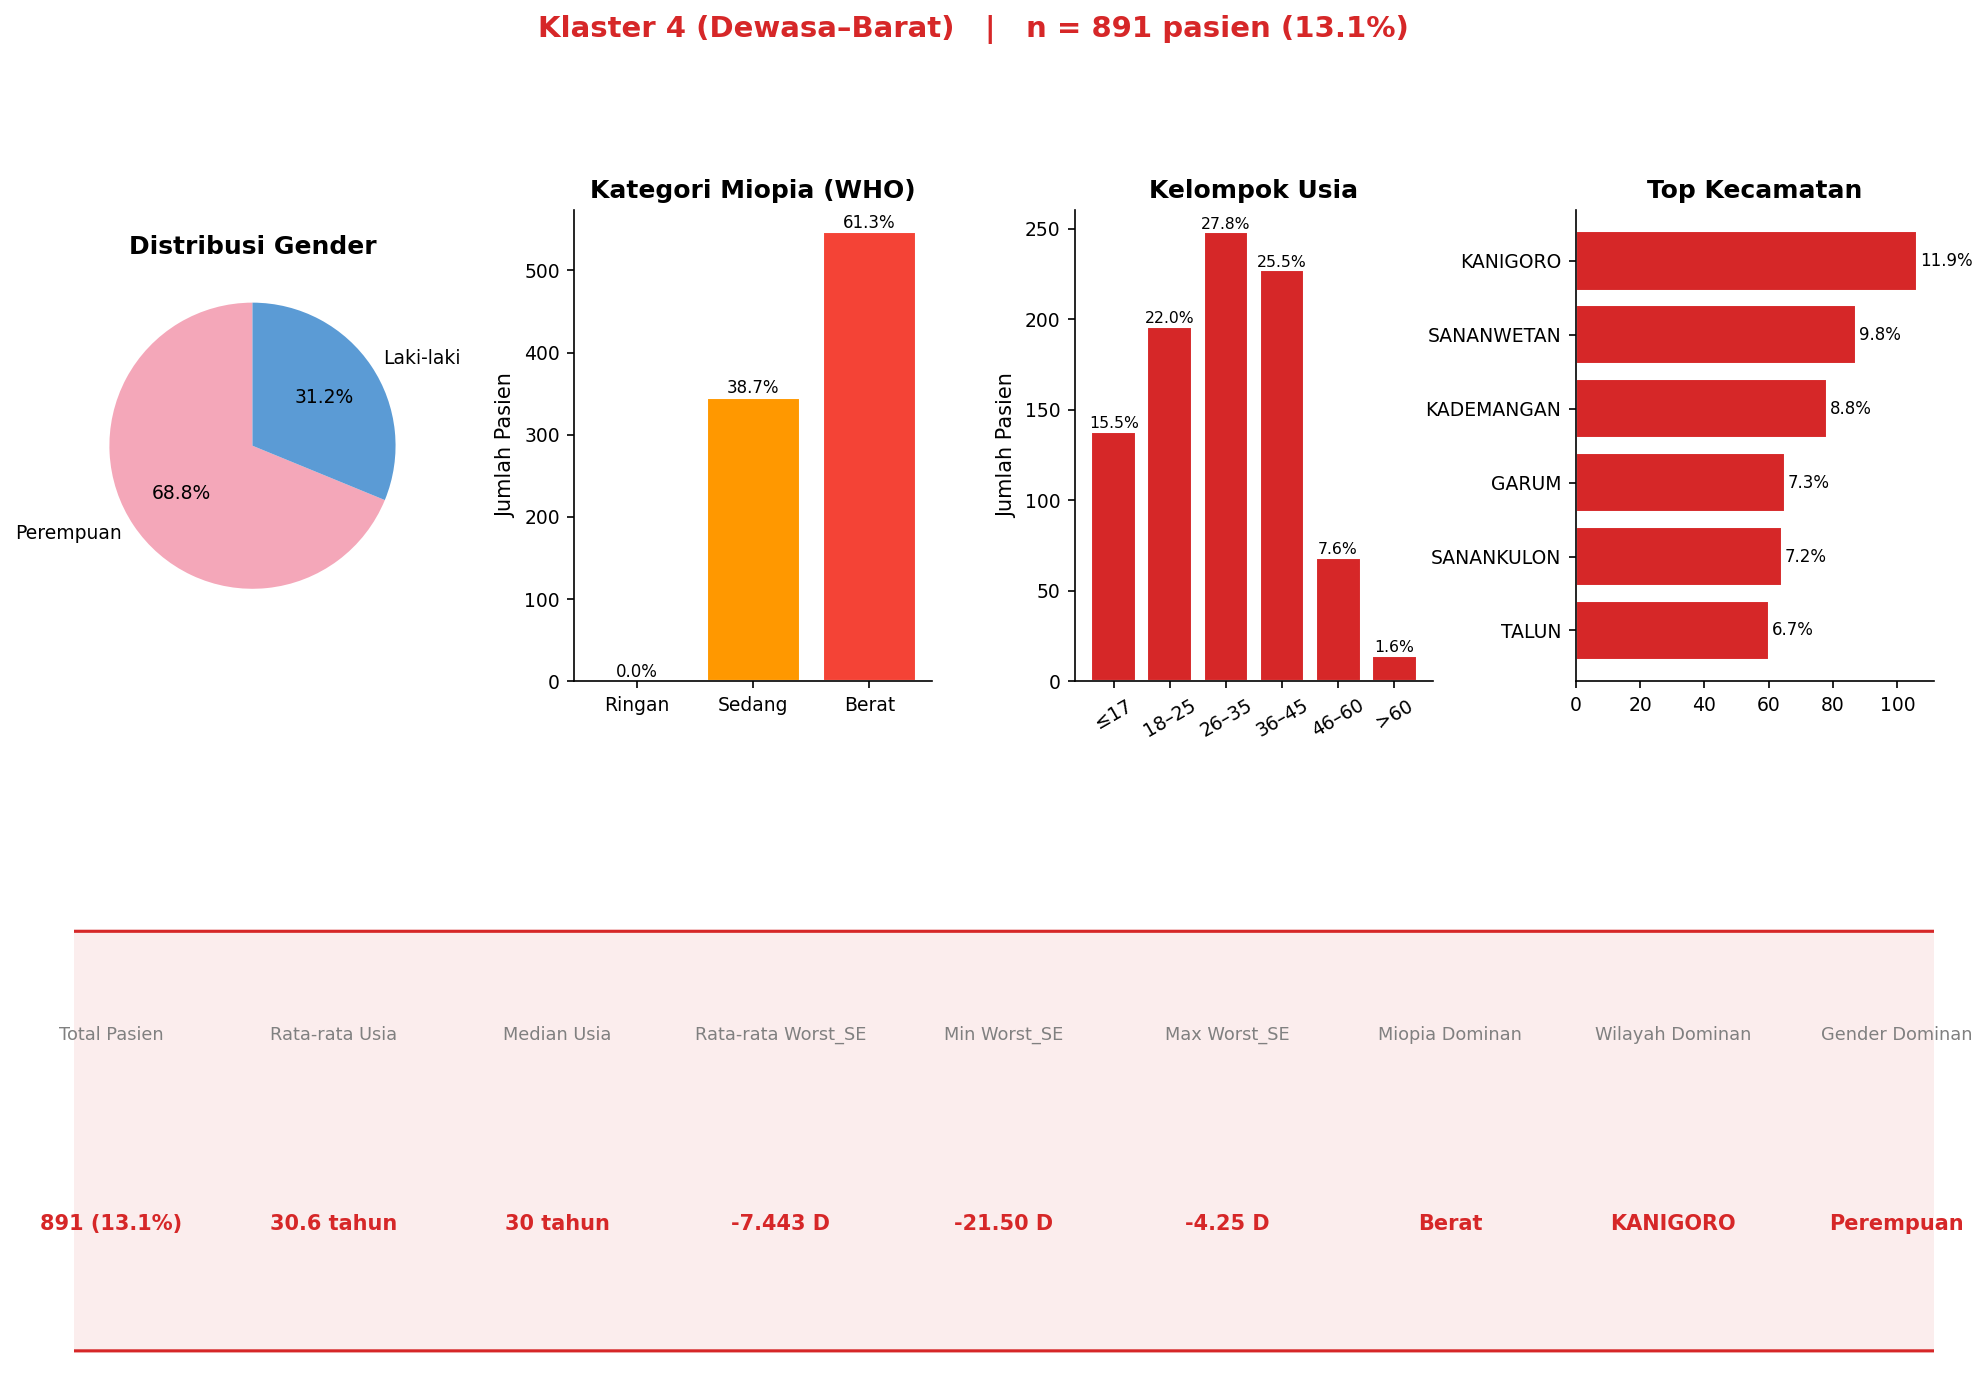

  ✓ Tersimpan → Chart_01_04_Dashboard_Klaster_4.png


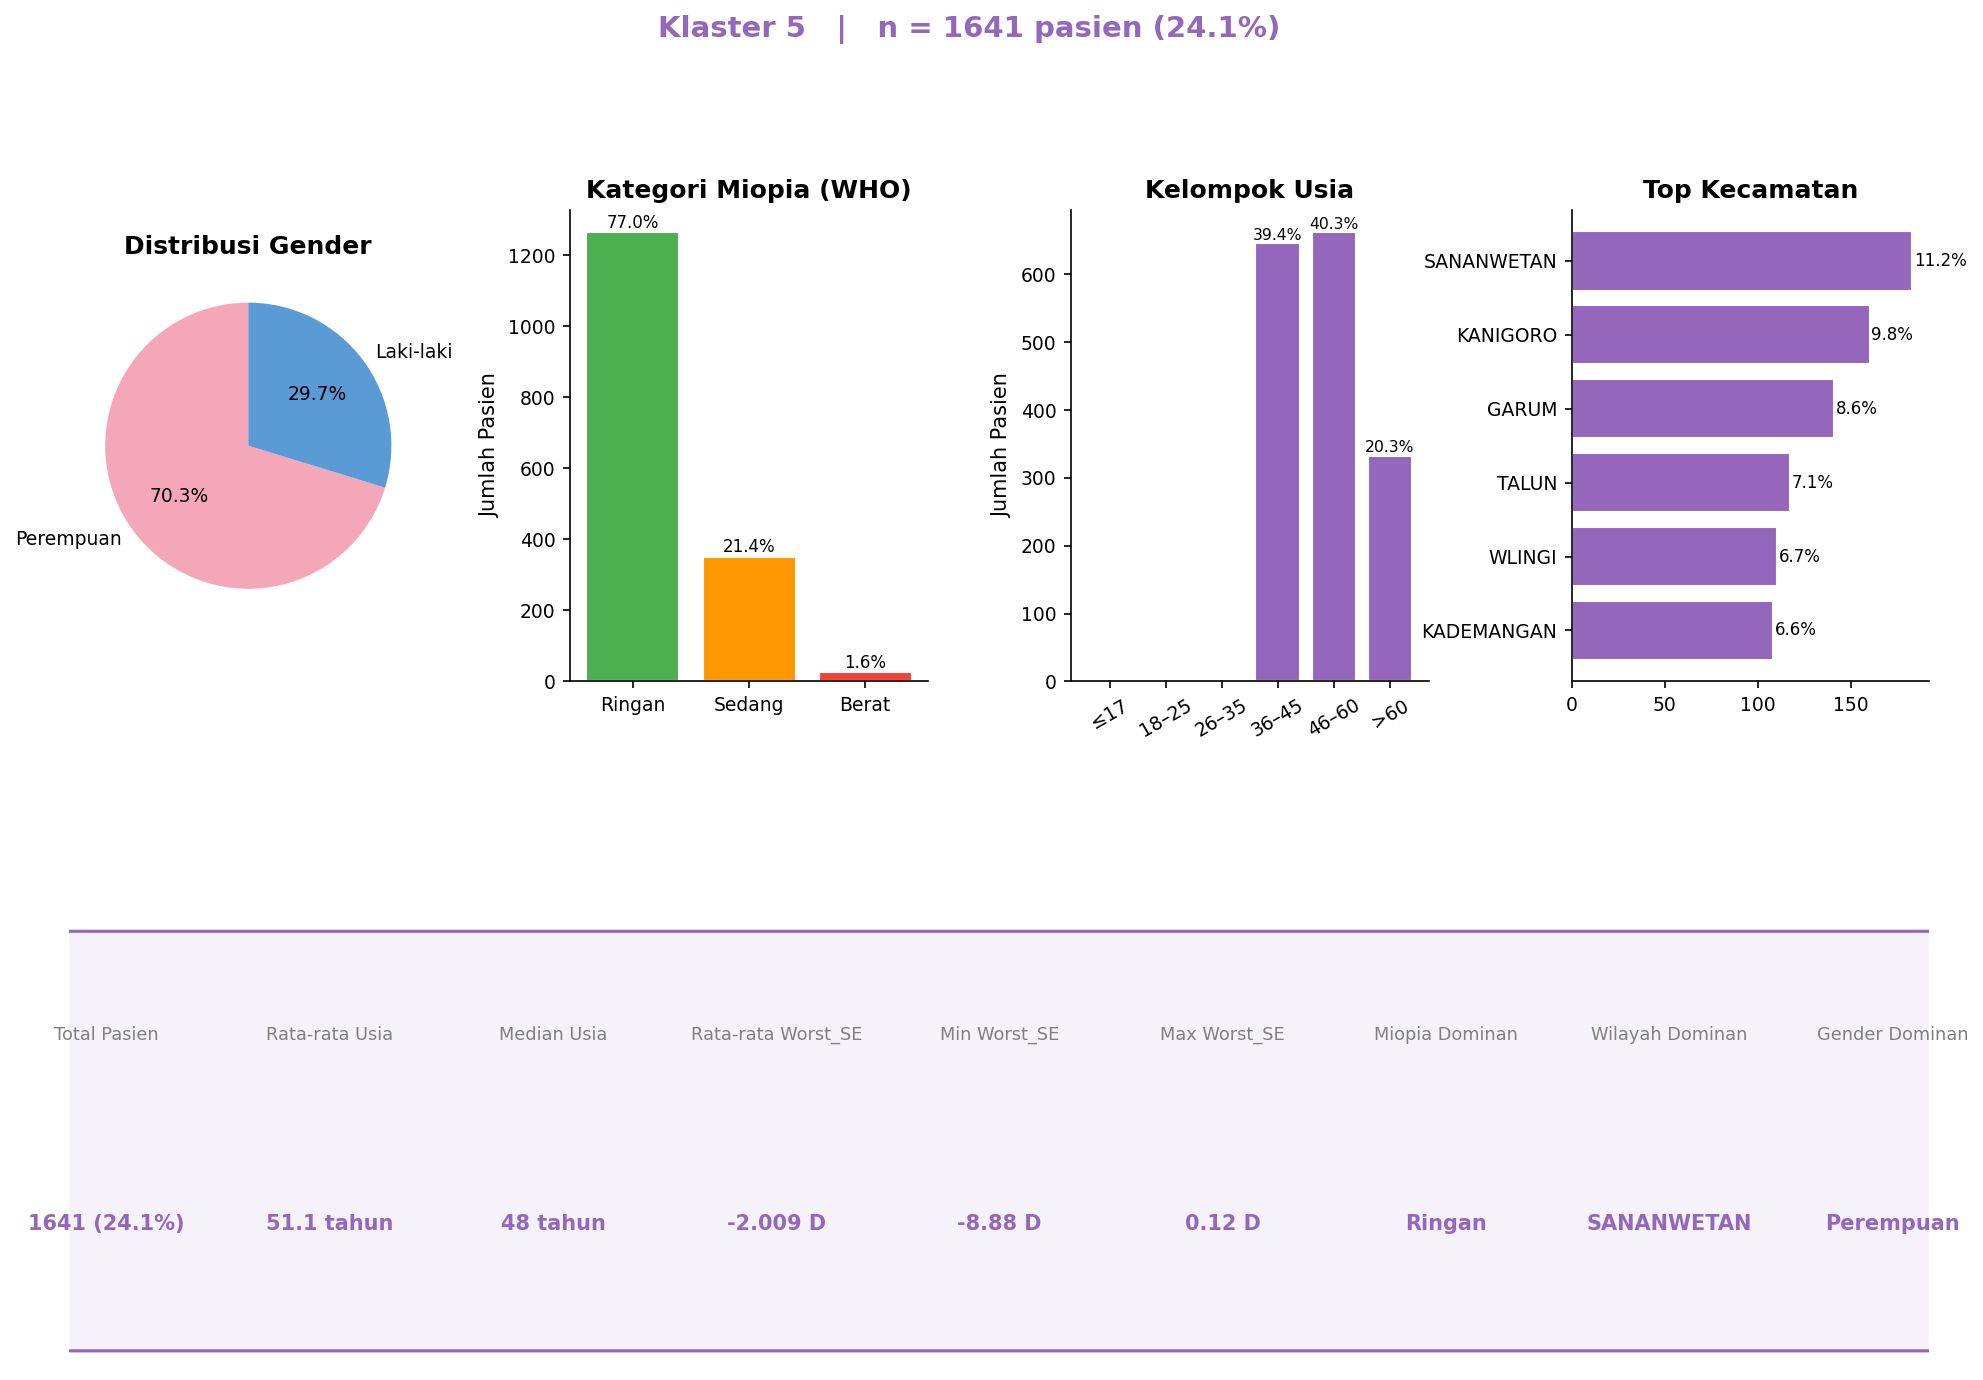

  ✓ Tersimpan → Chart_01_05_Dashboard_Klaster_5.png

[SEKSI 2] Distribusi Individual...


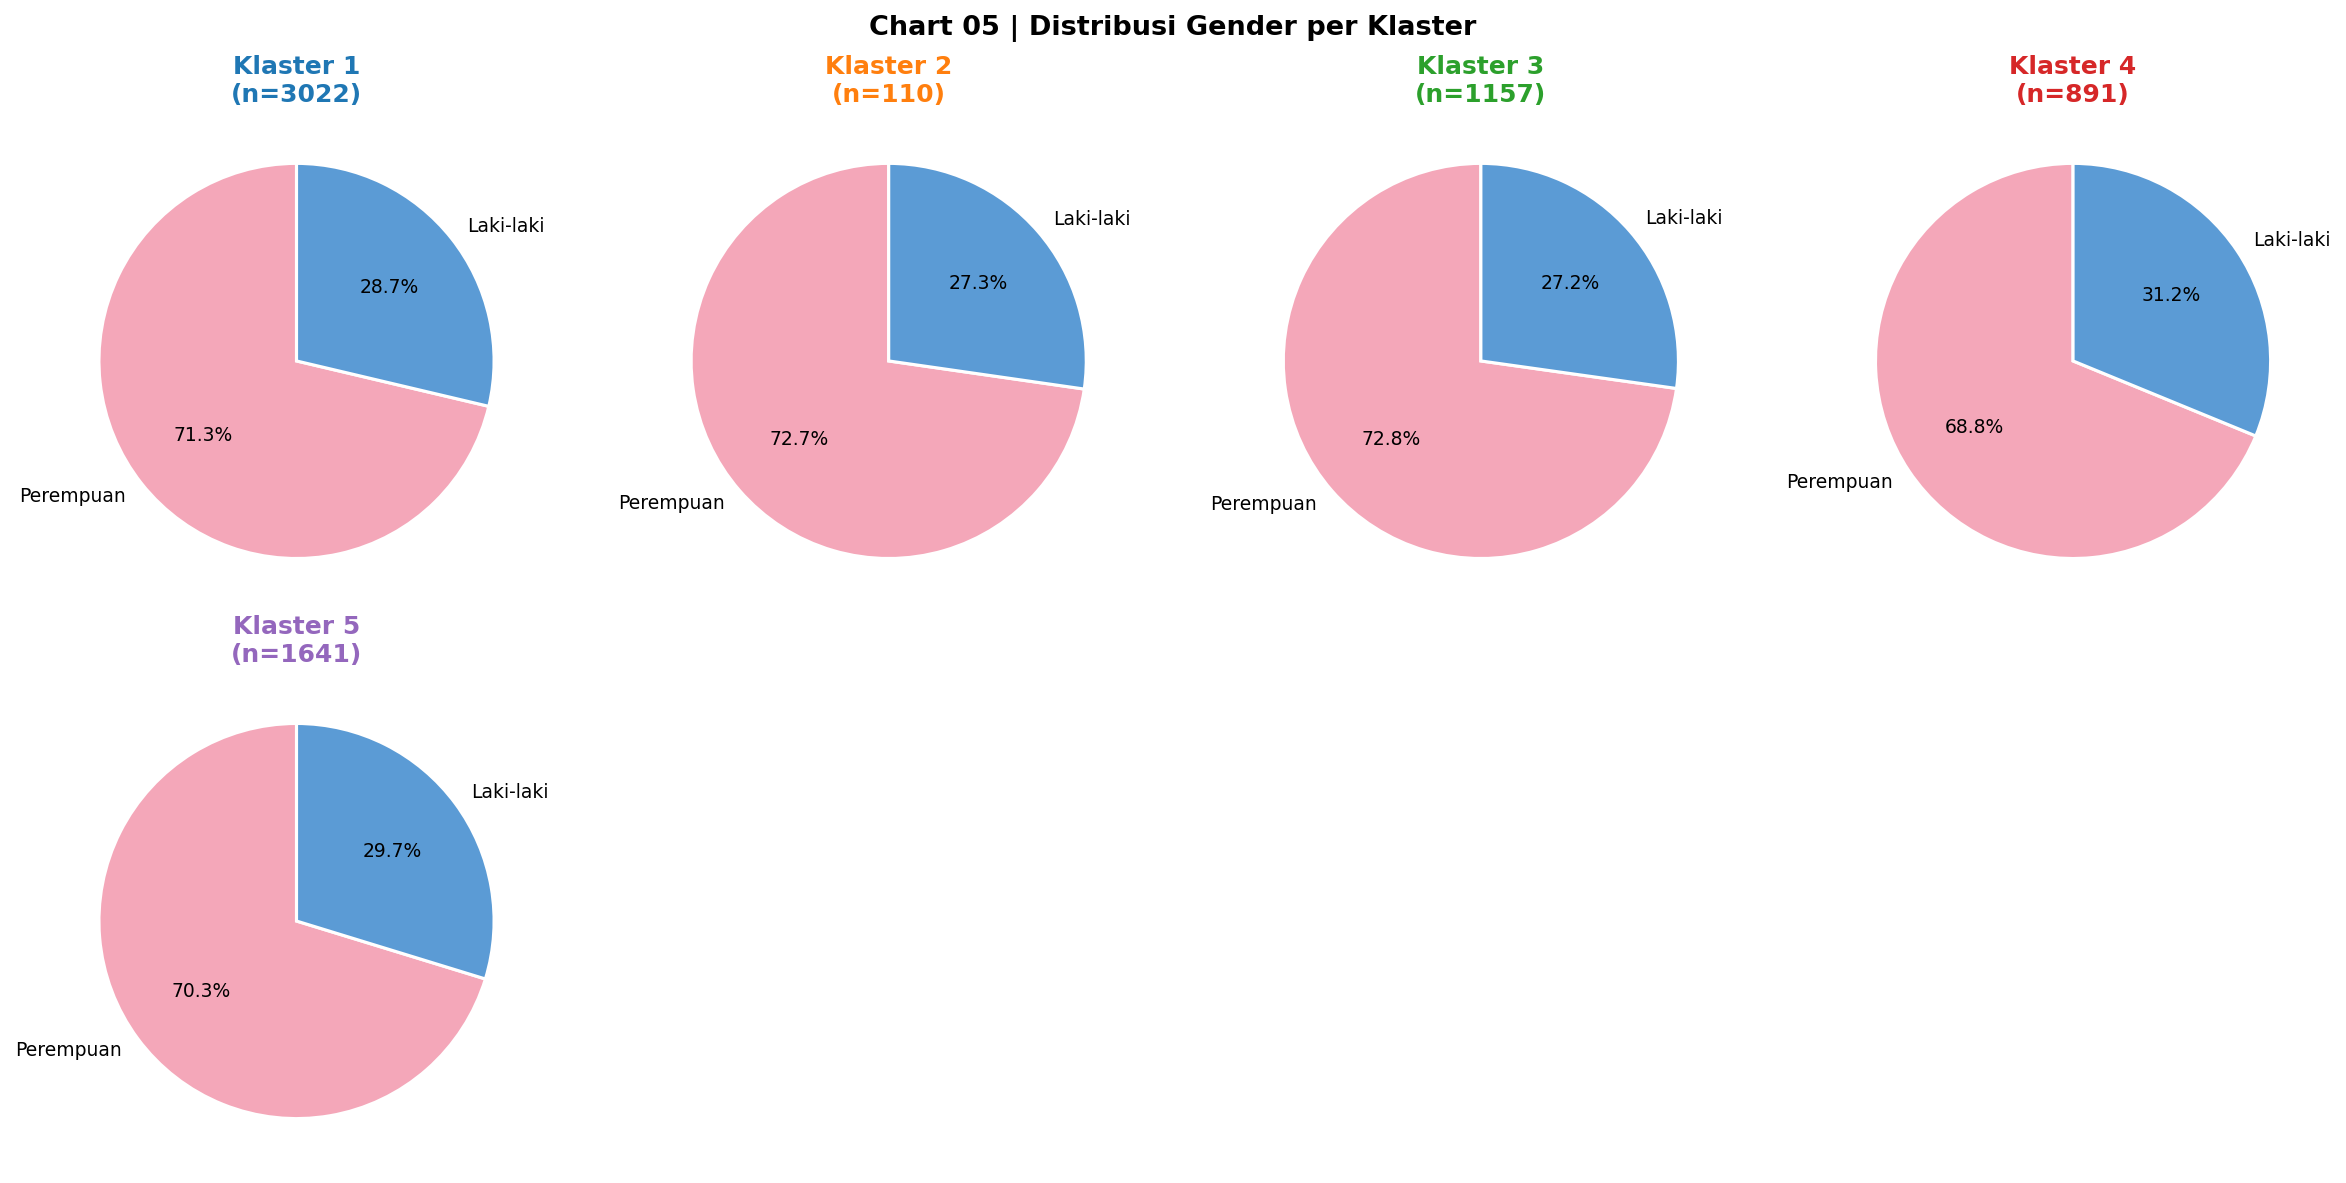

  ✓ Tersimpan → Chart_05_Gender_Per_Klaster.png


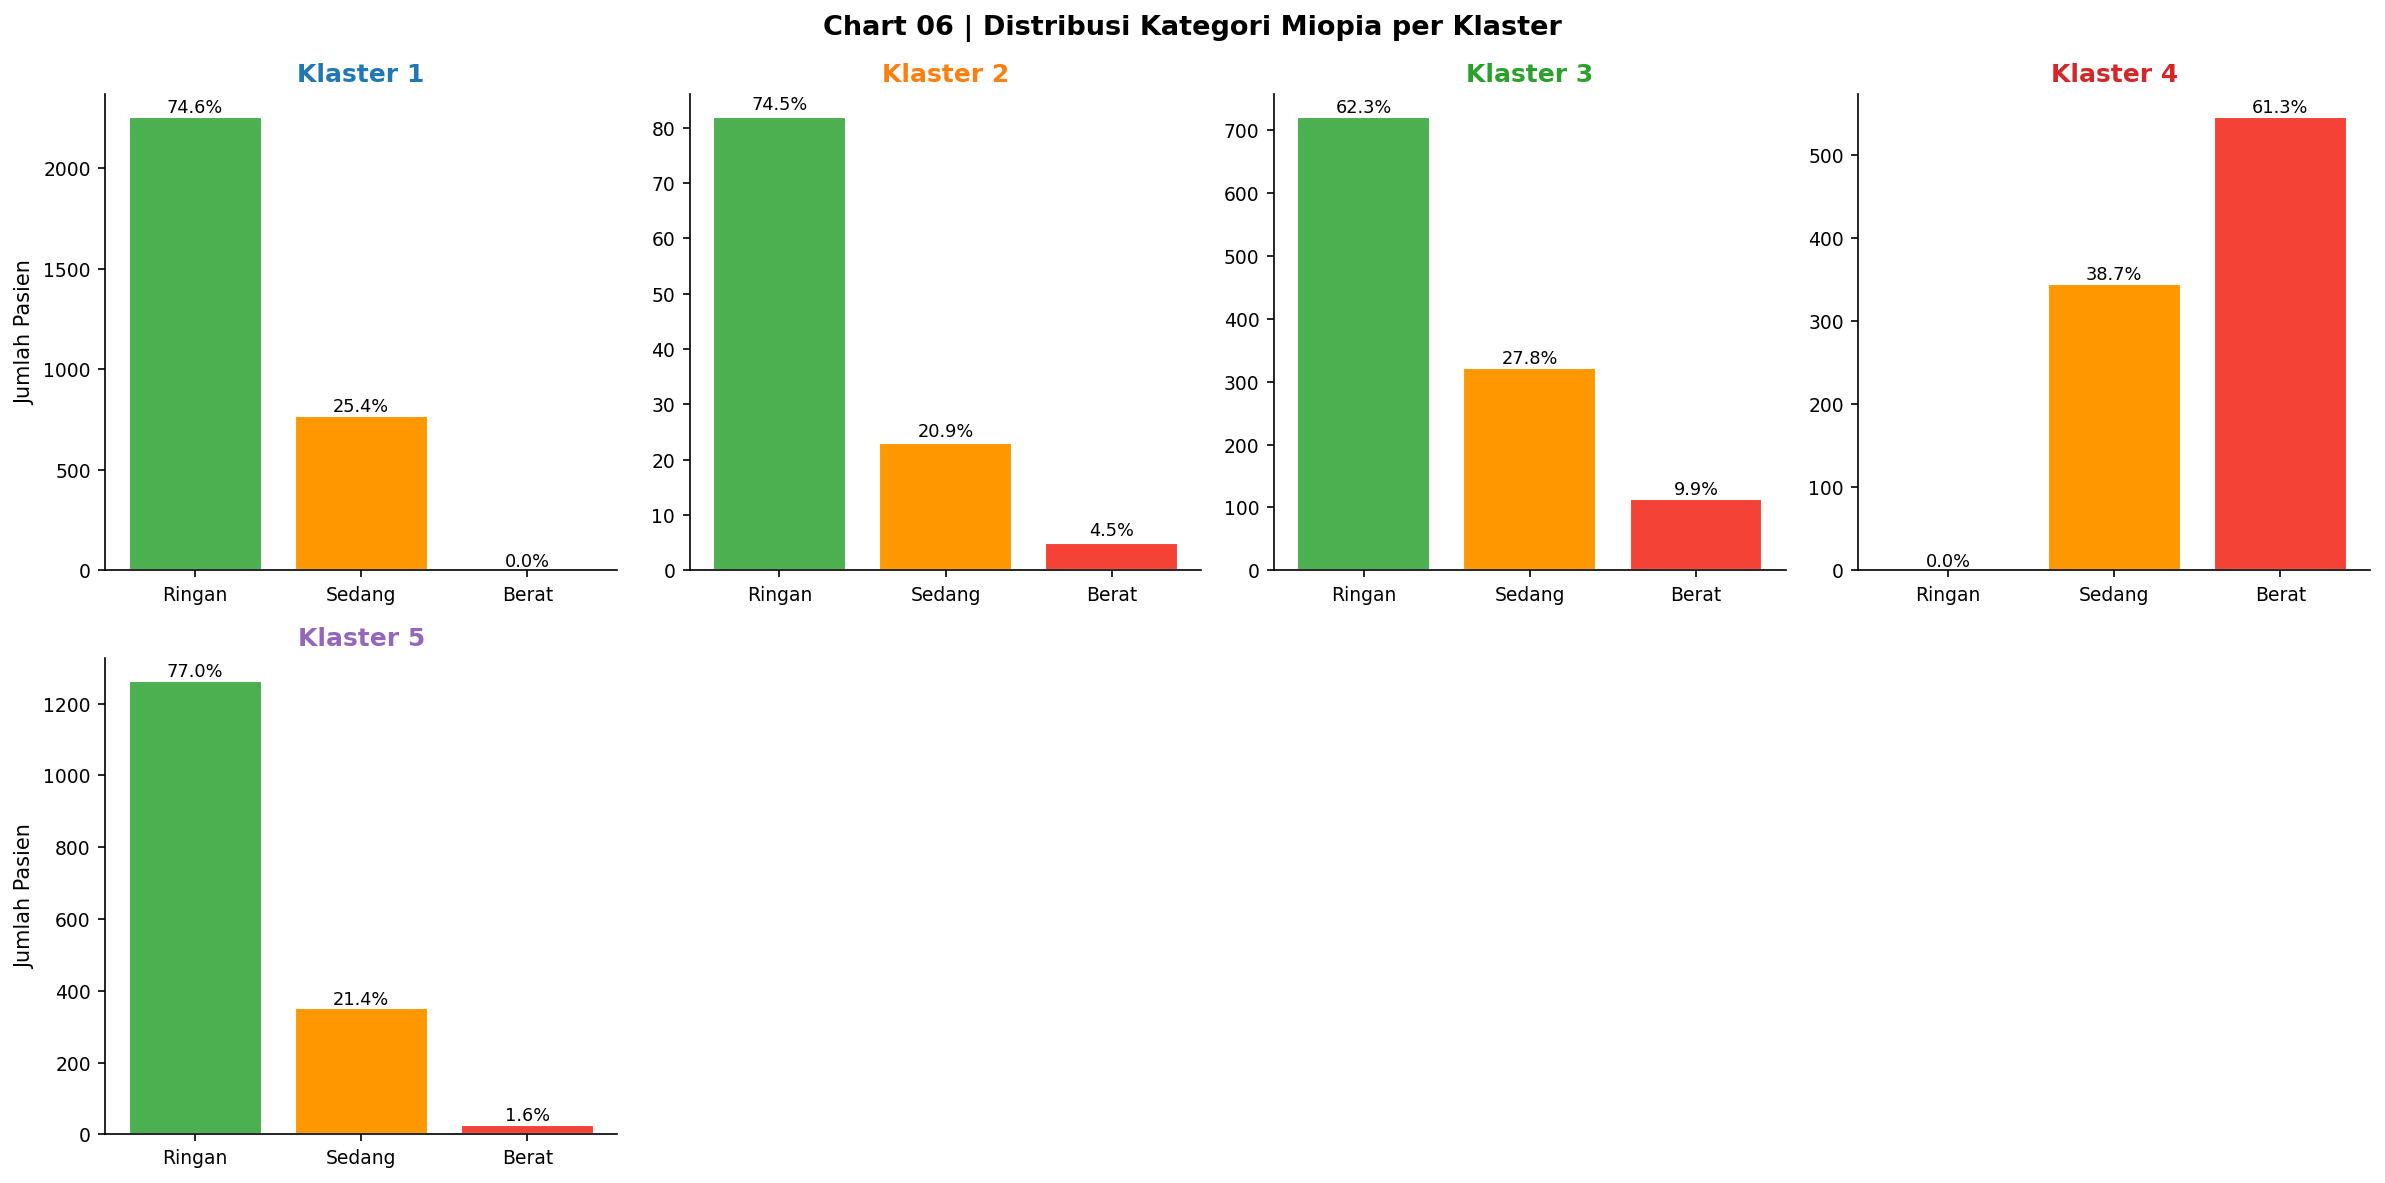

  ✓ Tersimpan → Chart_06_Miopia_Per_Klaster.png


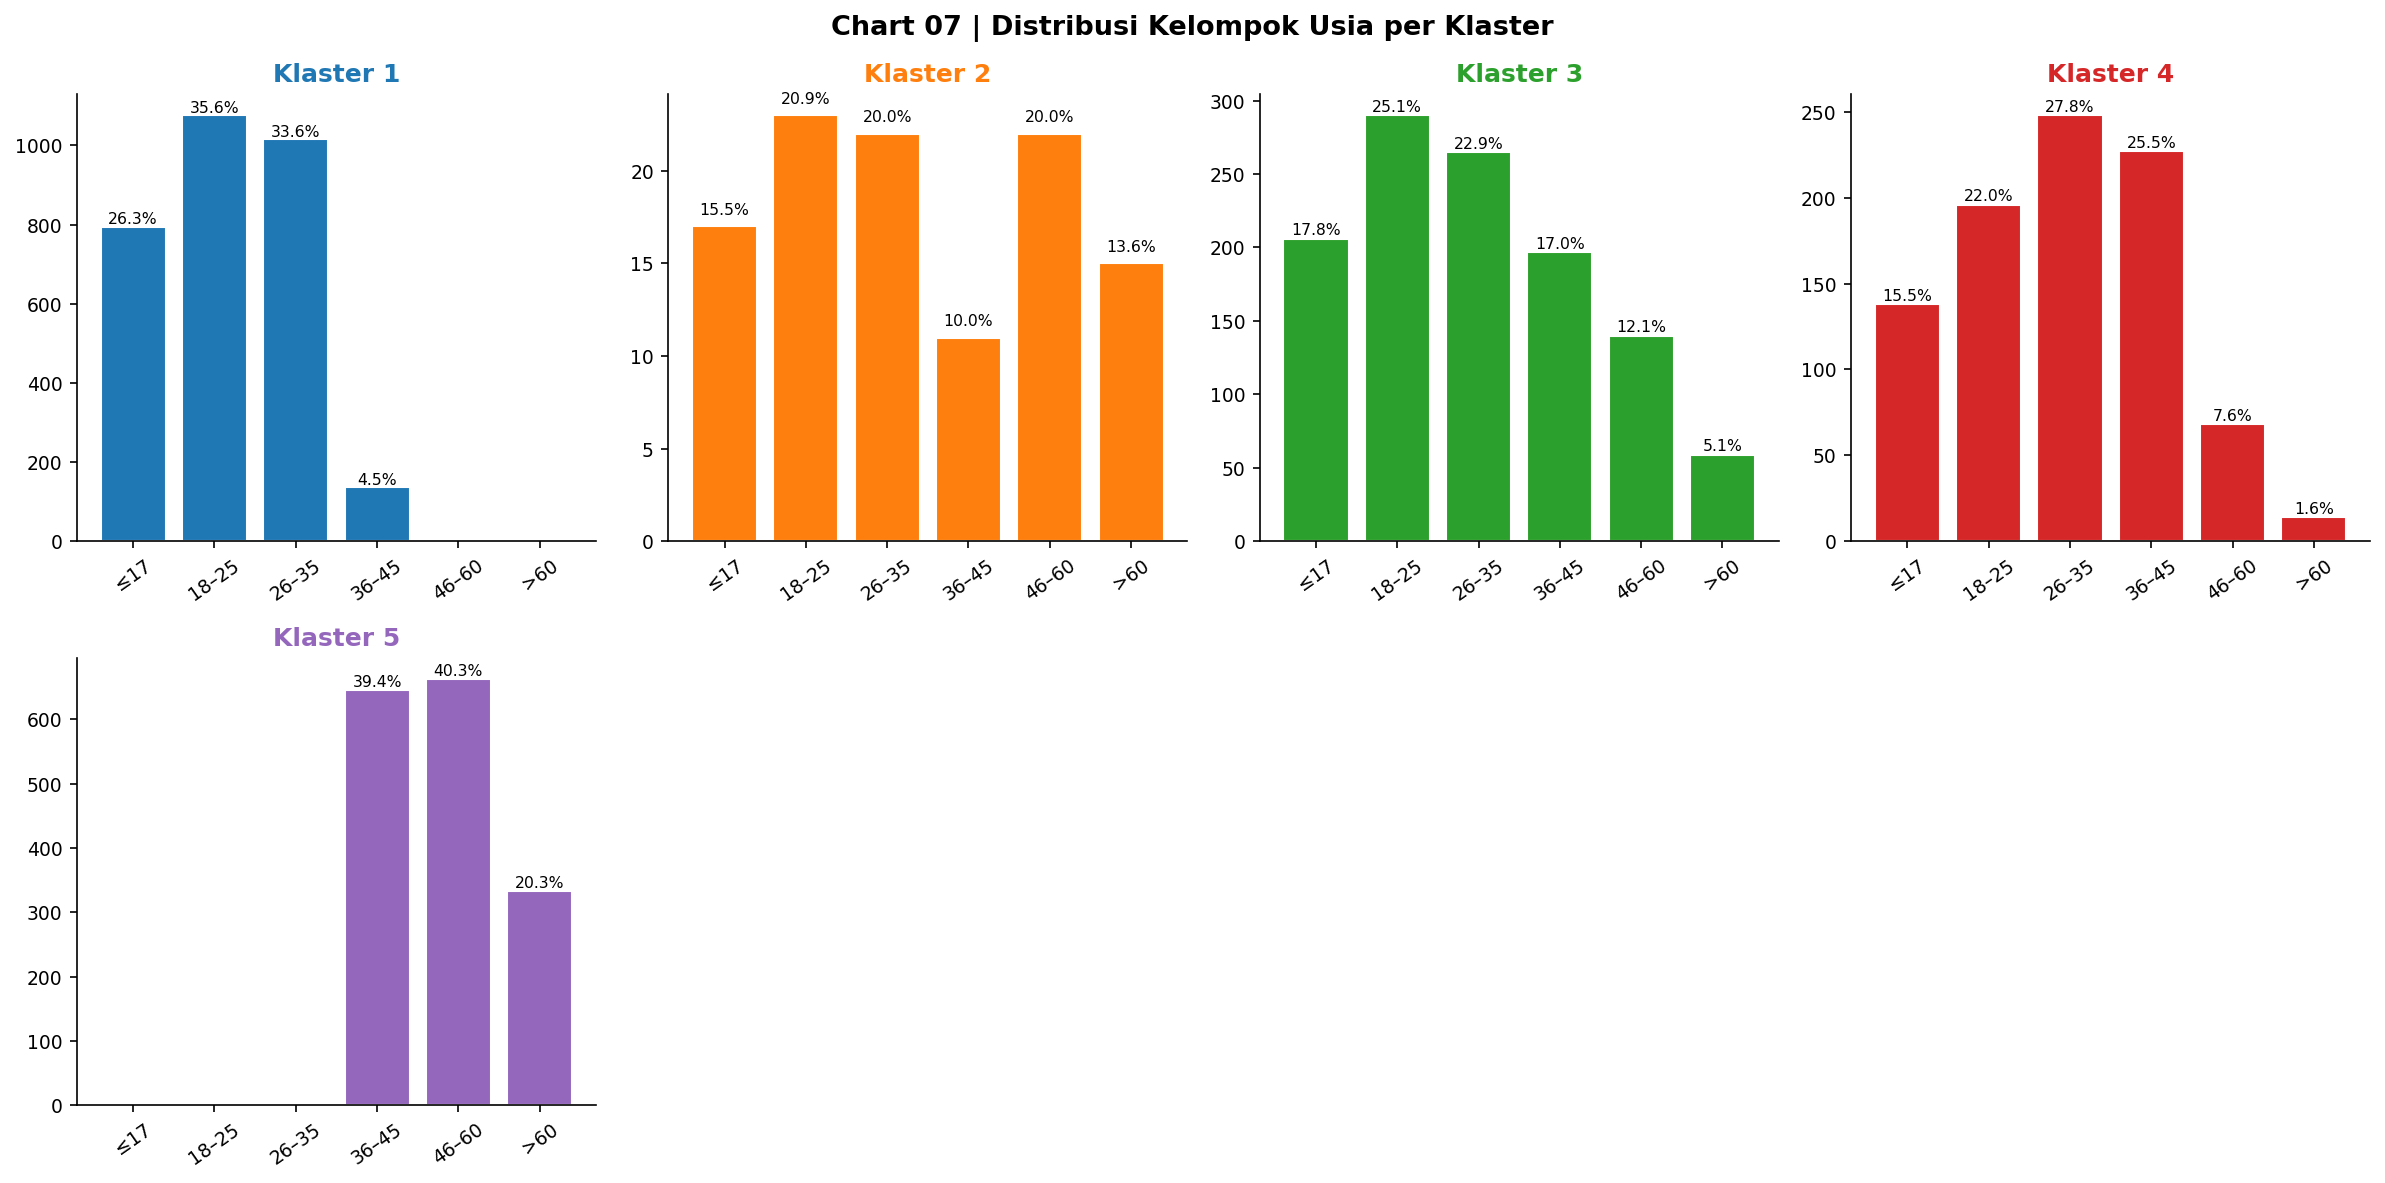

  ✓ Tersimpan → Chart_07_Usia_Per_Klaster.png


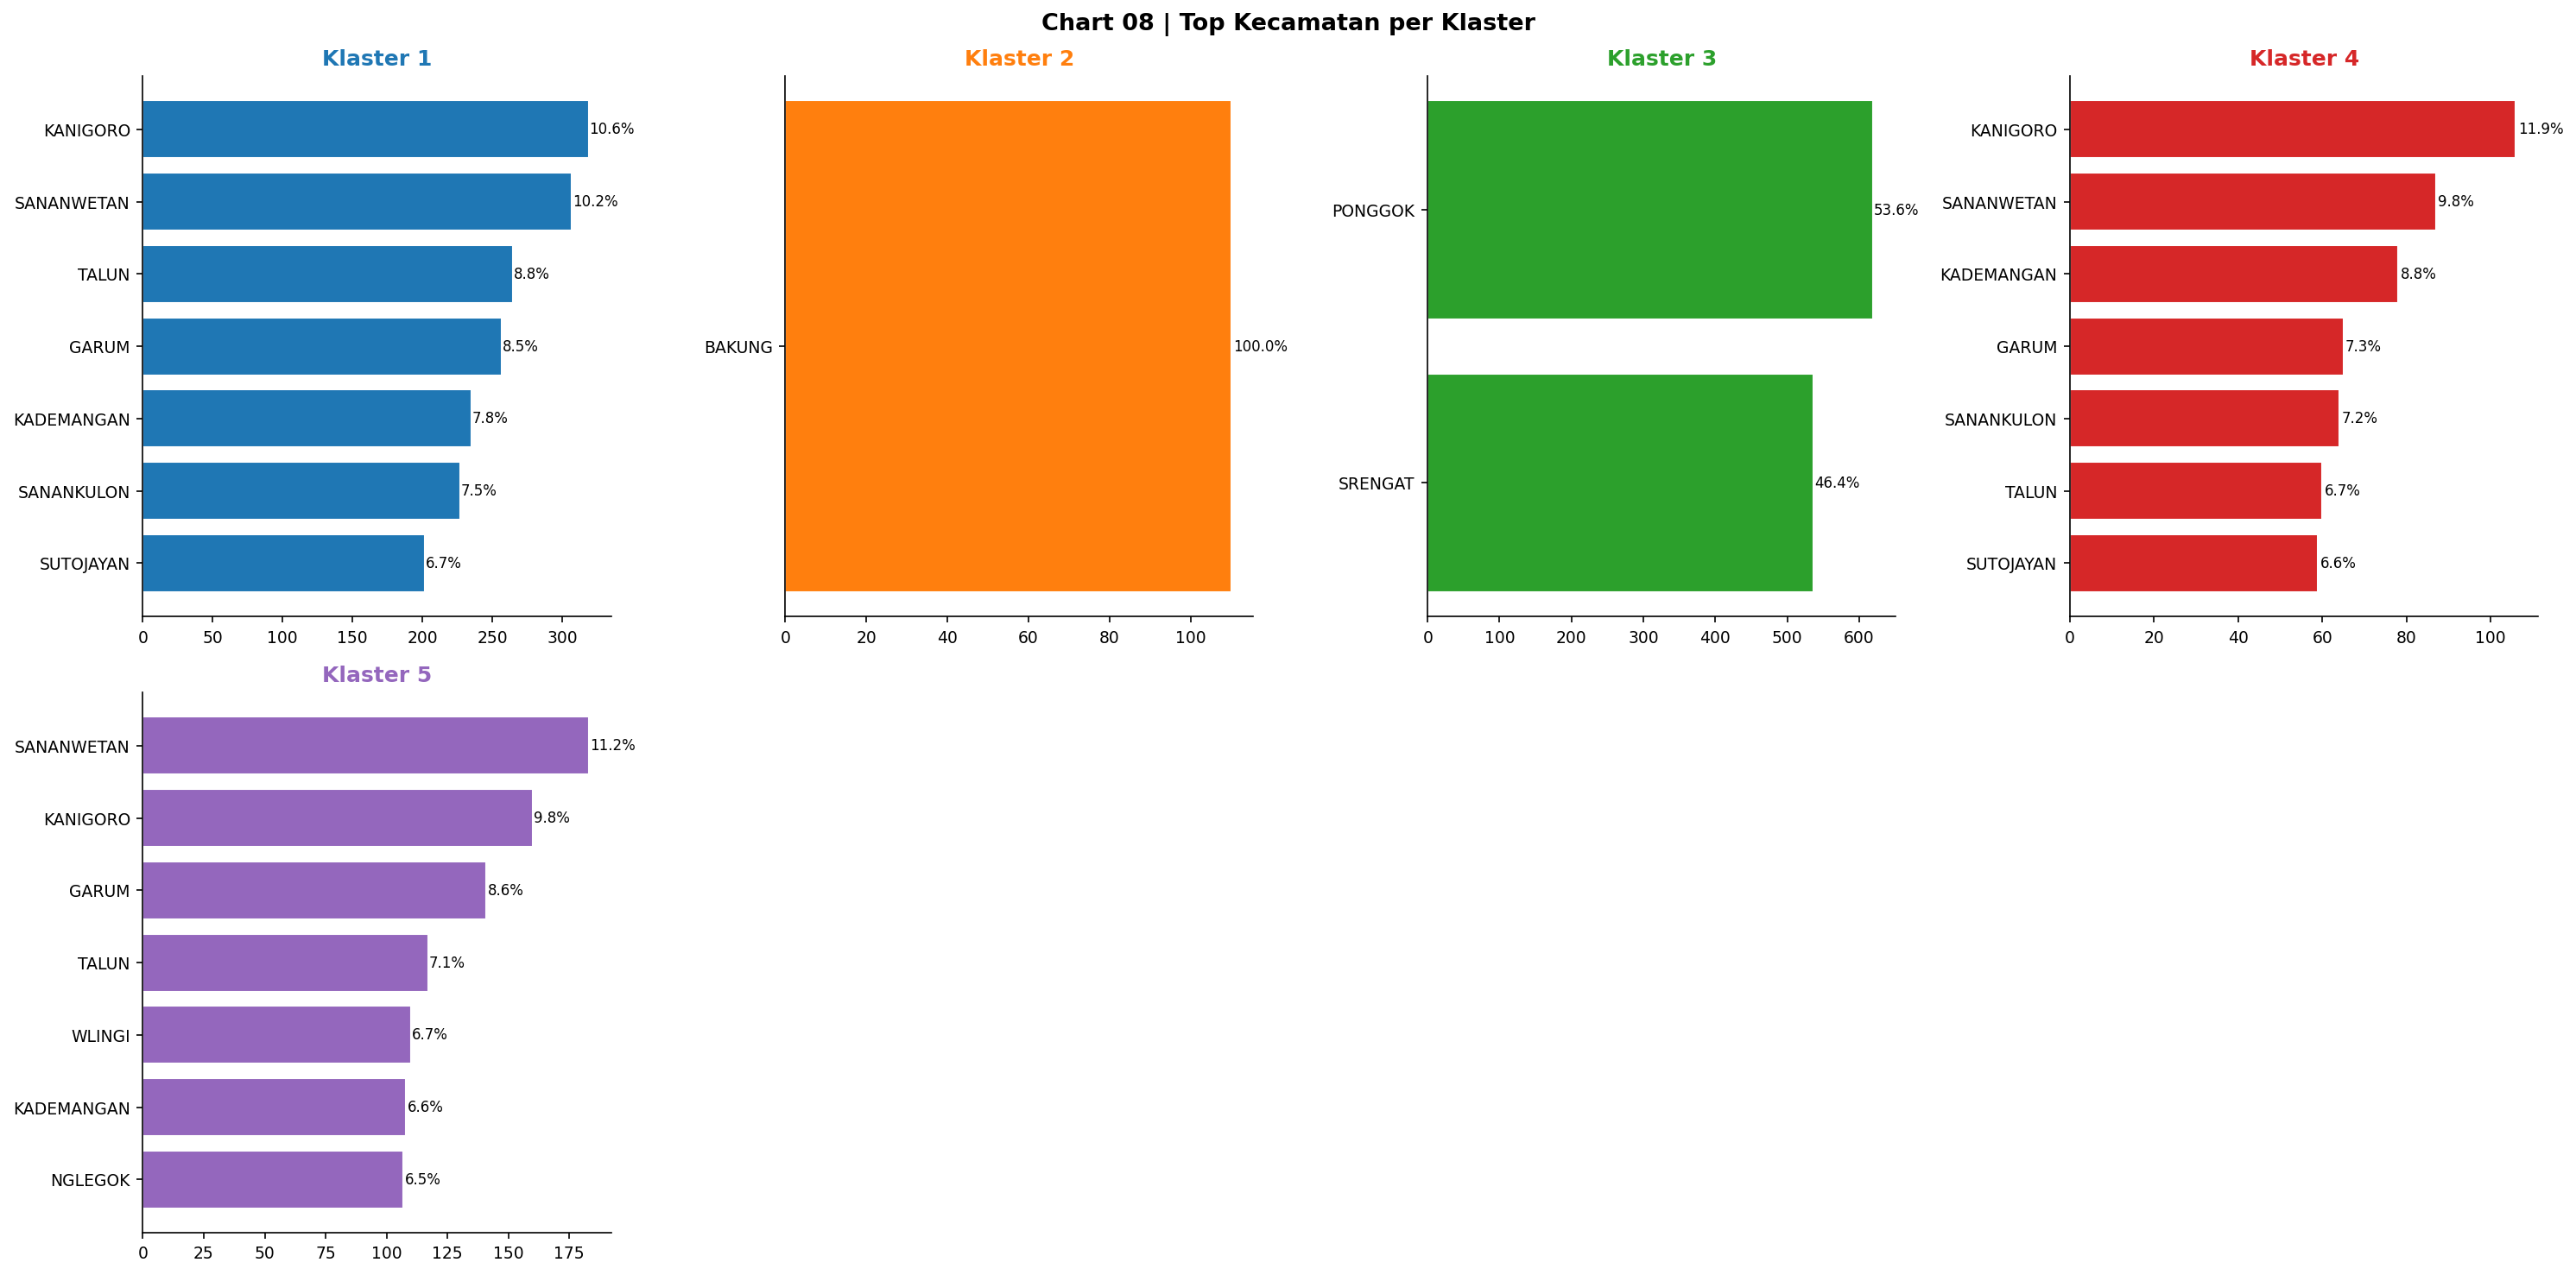

  ✓ Tersimpan → Chart_08_Kecamatan_Per_Klaster.png


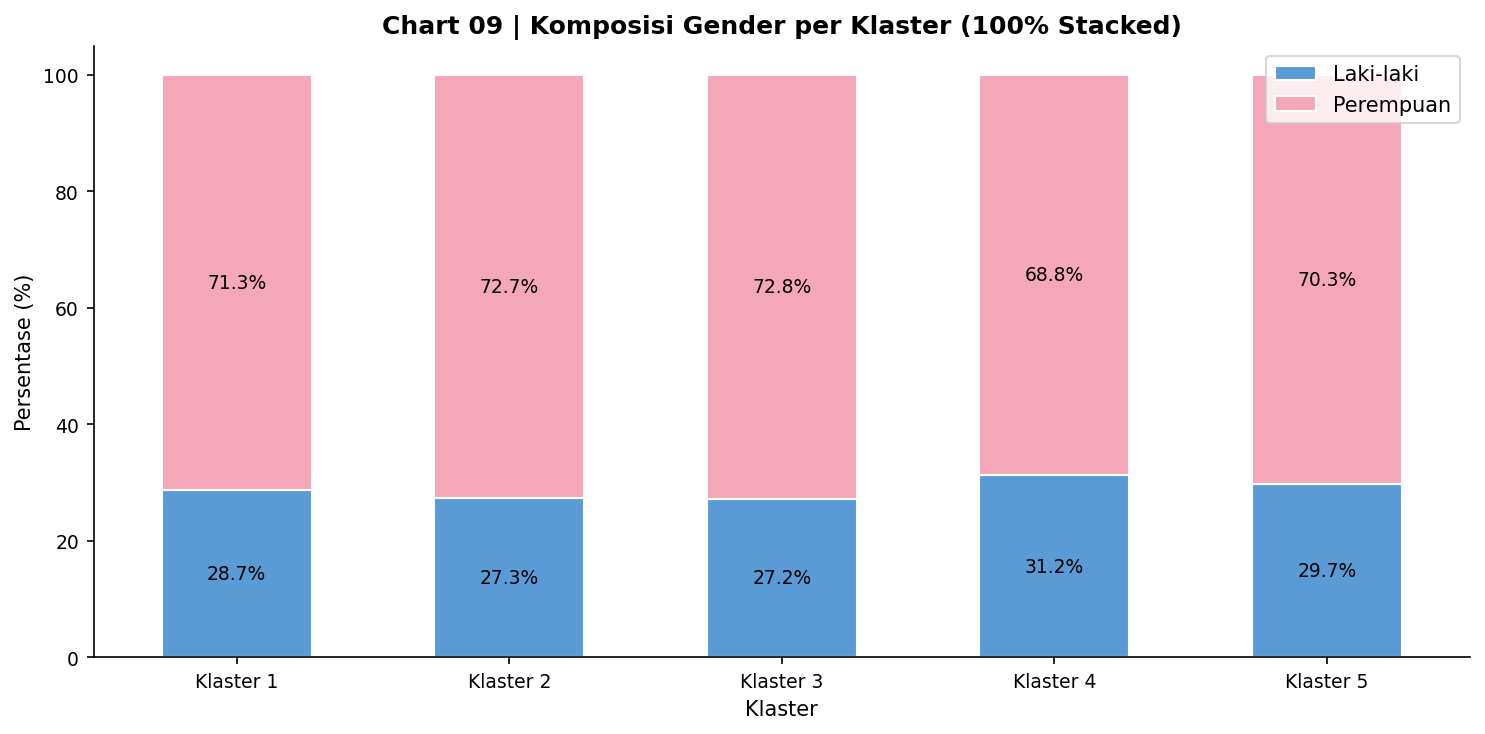

  ✓ Tersimpan → Chart_09_Stacked_Gender.png


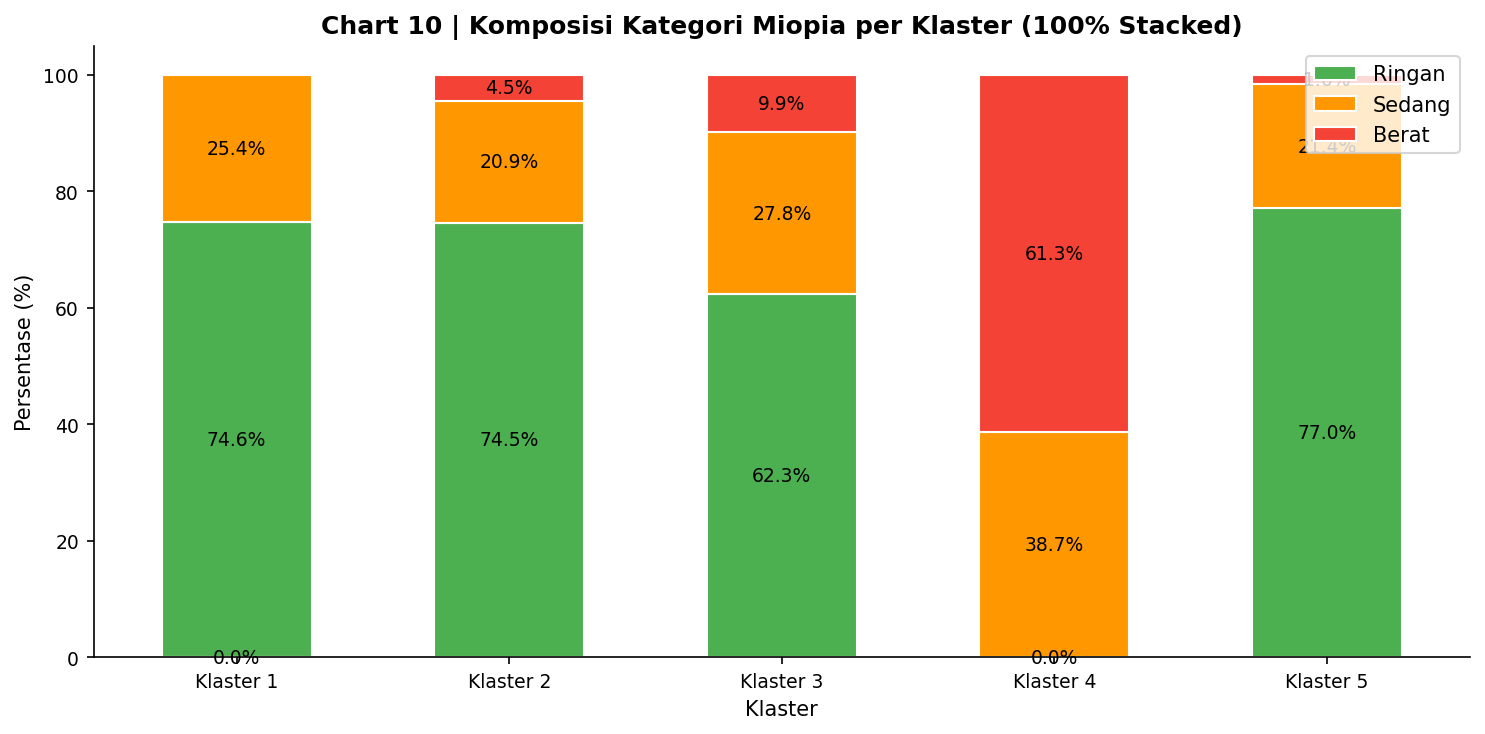

  ✓ Tersimpan → Chart_10_Stacked_Miopia.png

[SEKSI 3] Komparatif Antar Klaster...


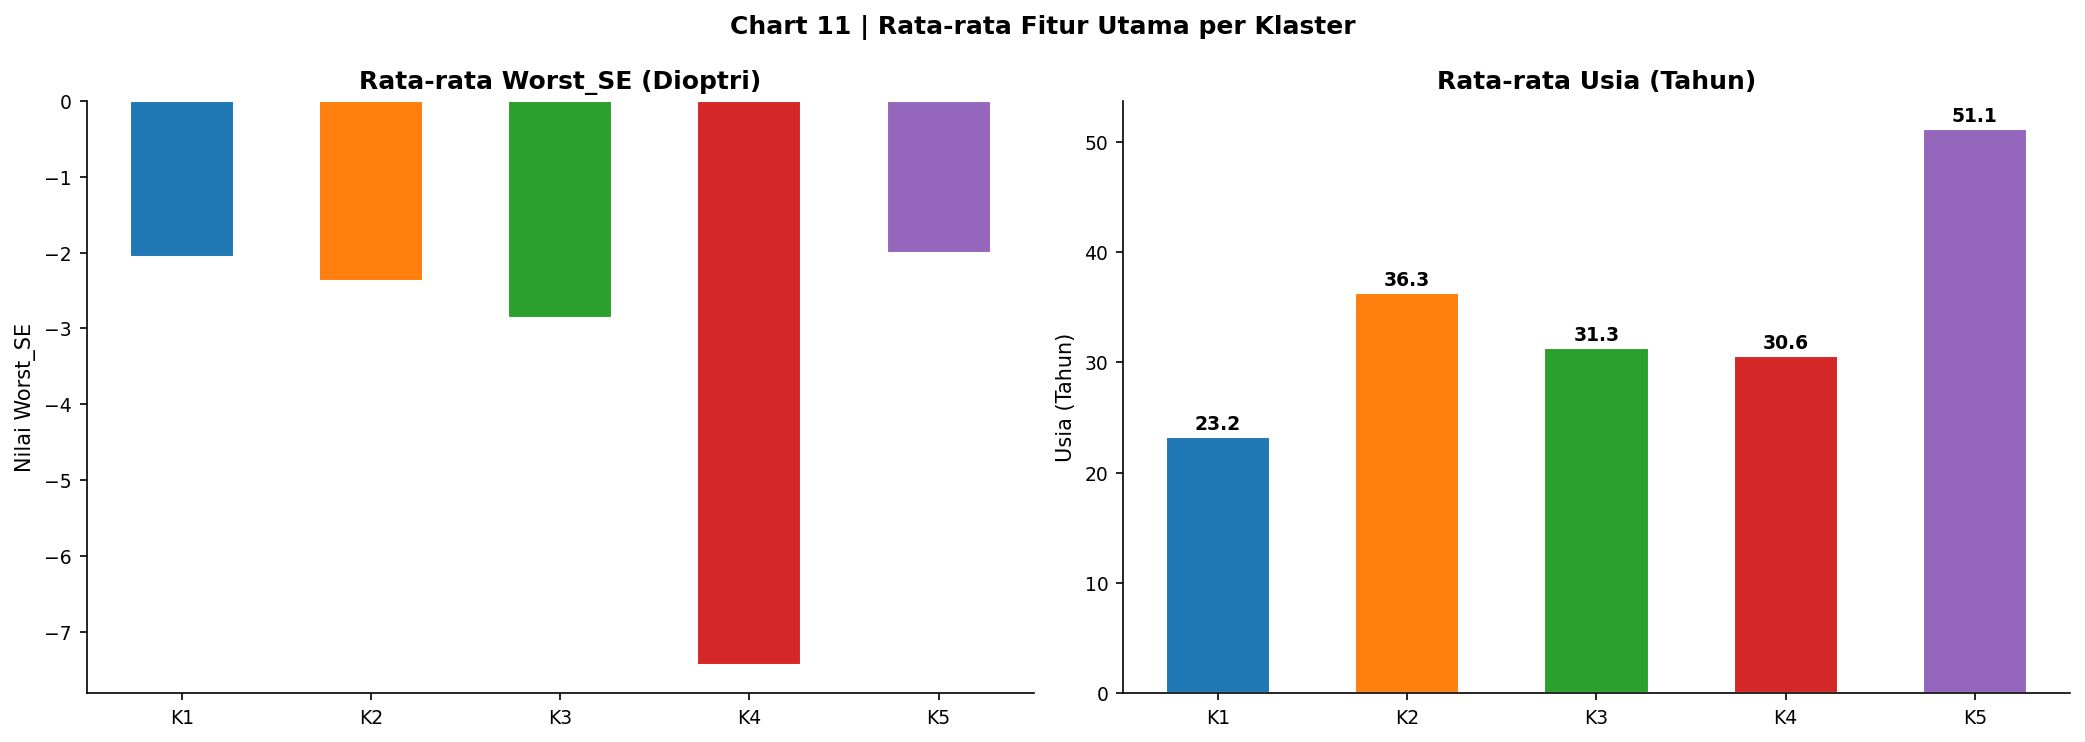

  ✓ Tersimpan → Chart_11_Rata2_Fitur_Klaster.png


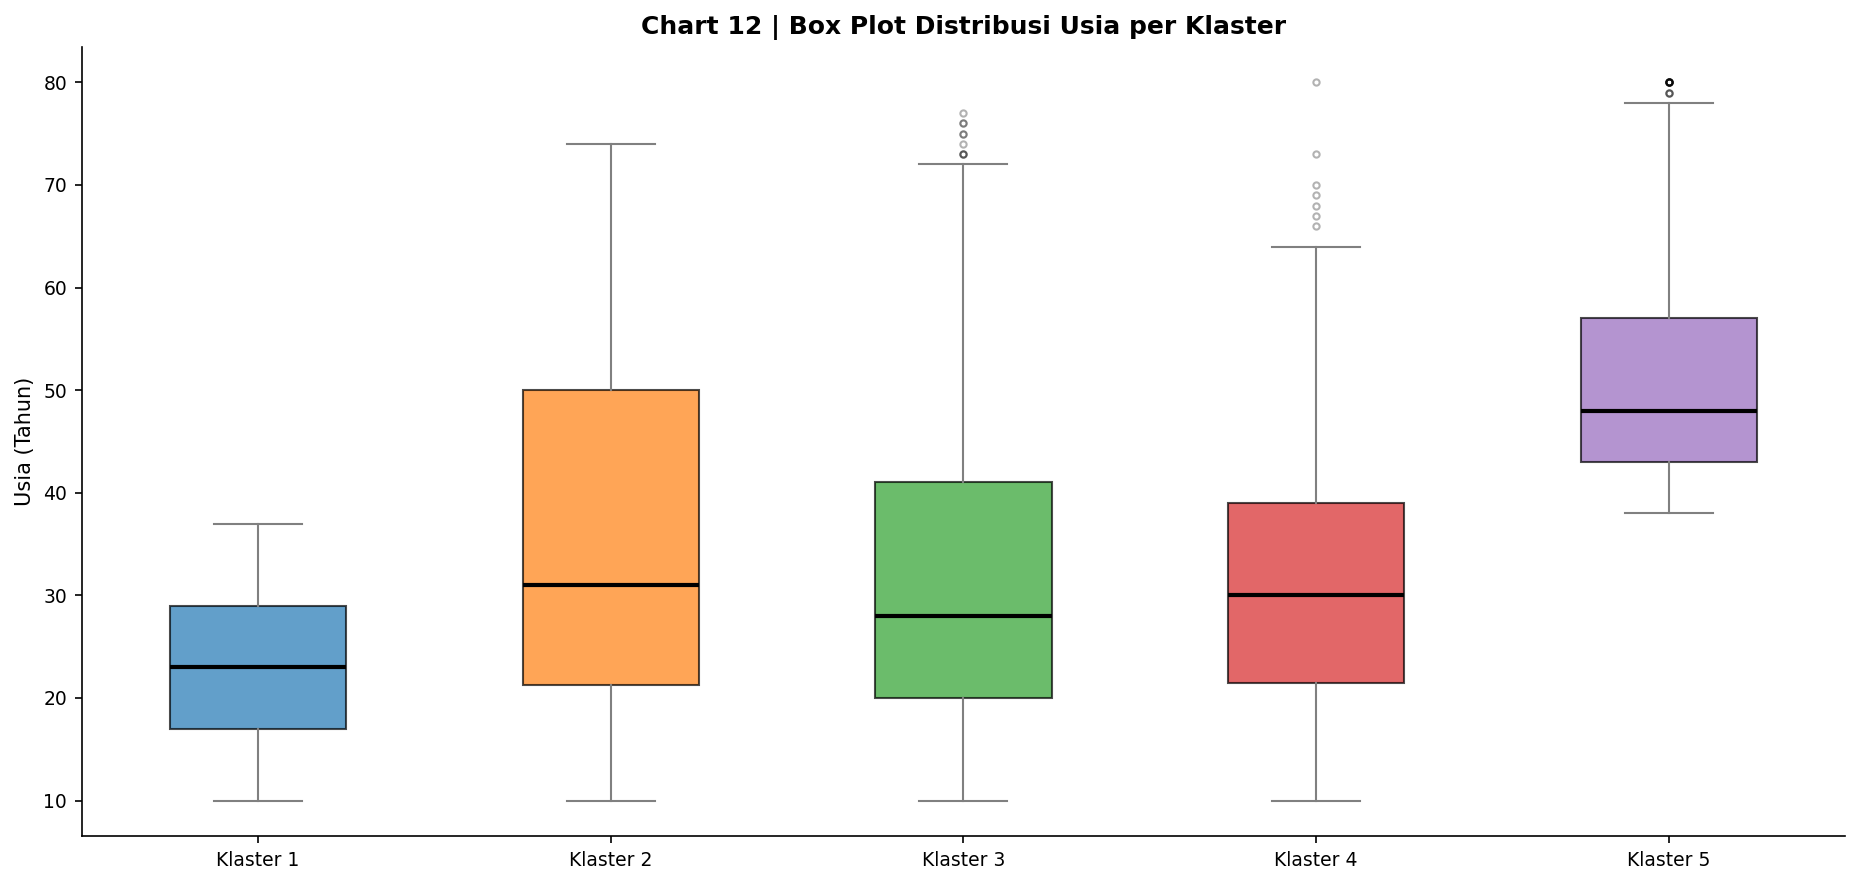

  ✓ Tersimpan → Chart_12_Boxplot_Usia.png


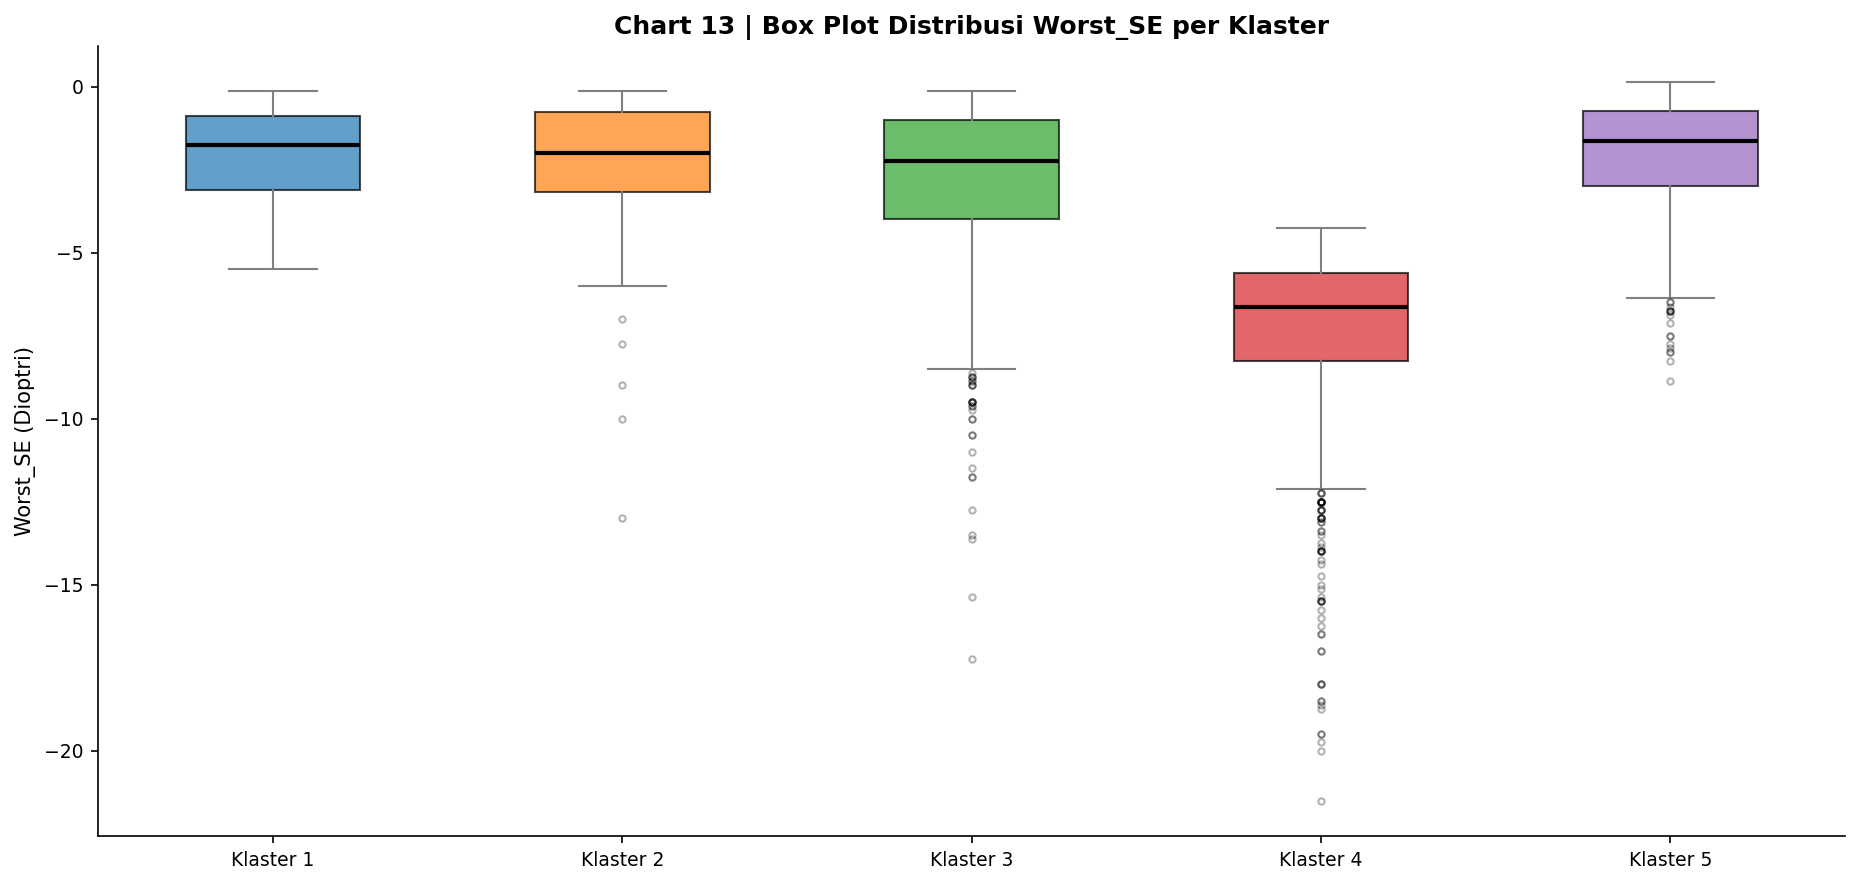

  ✓ Tersimpan → Chart_13_Boxplot_WorstSE.png


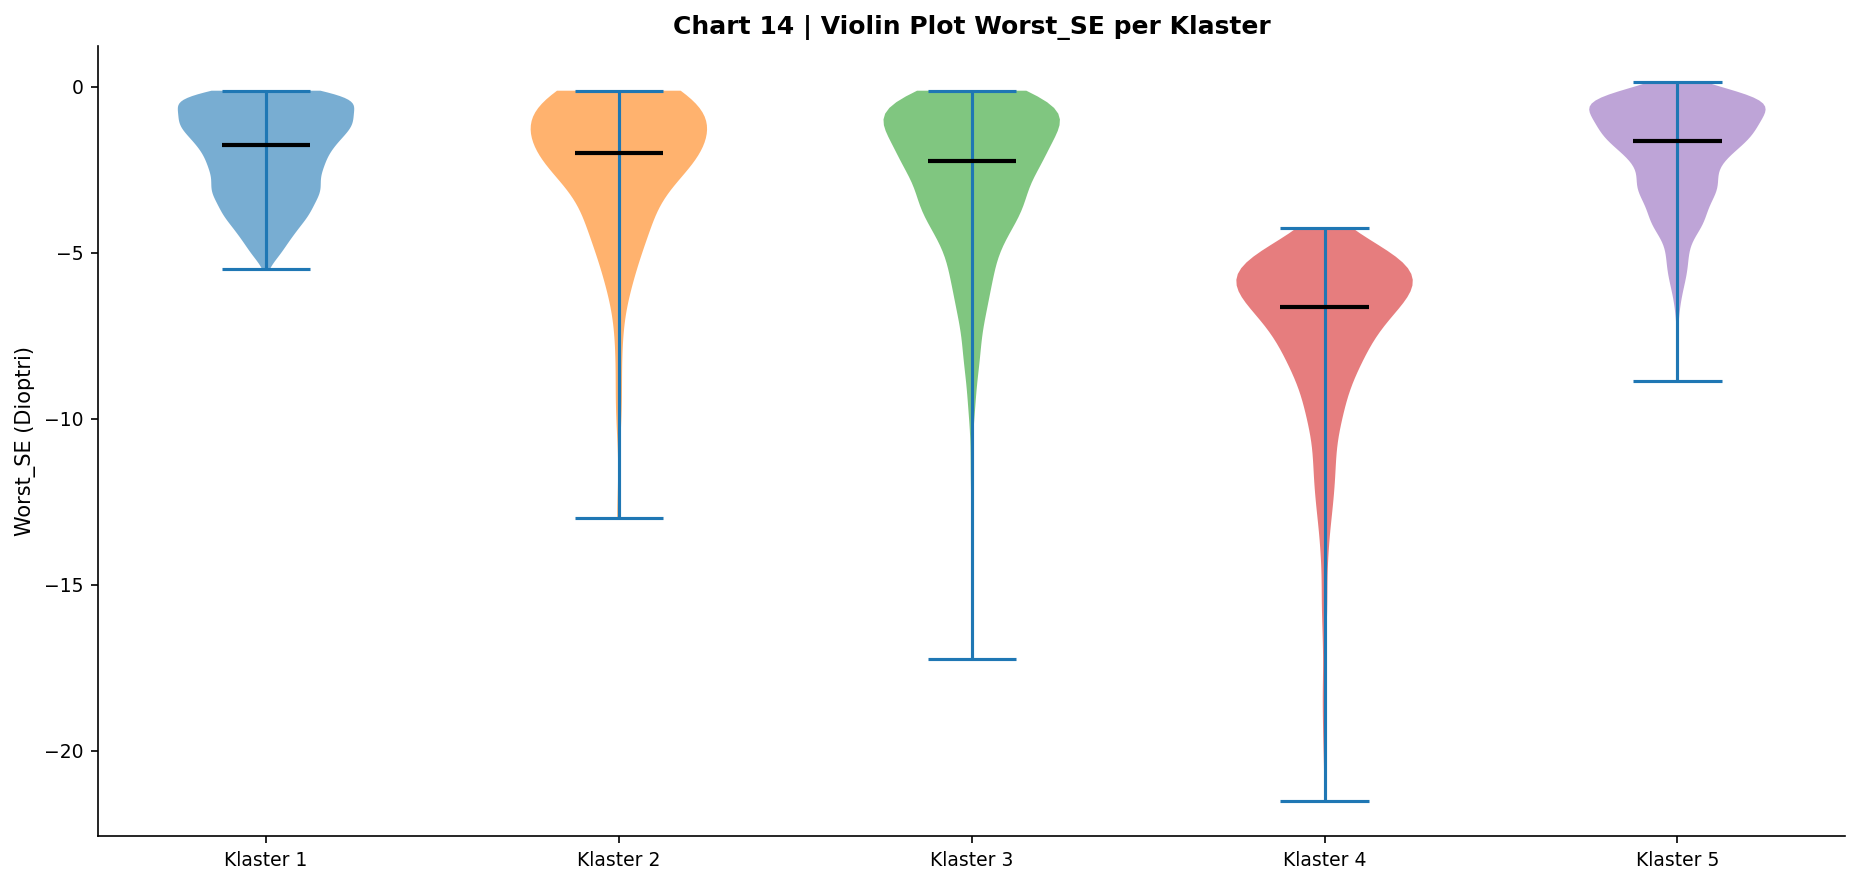

  ✓ Tersimpan → Chart_14_Violin_WorstSE.png


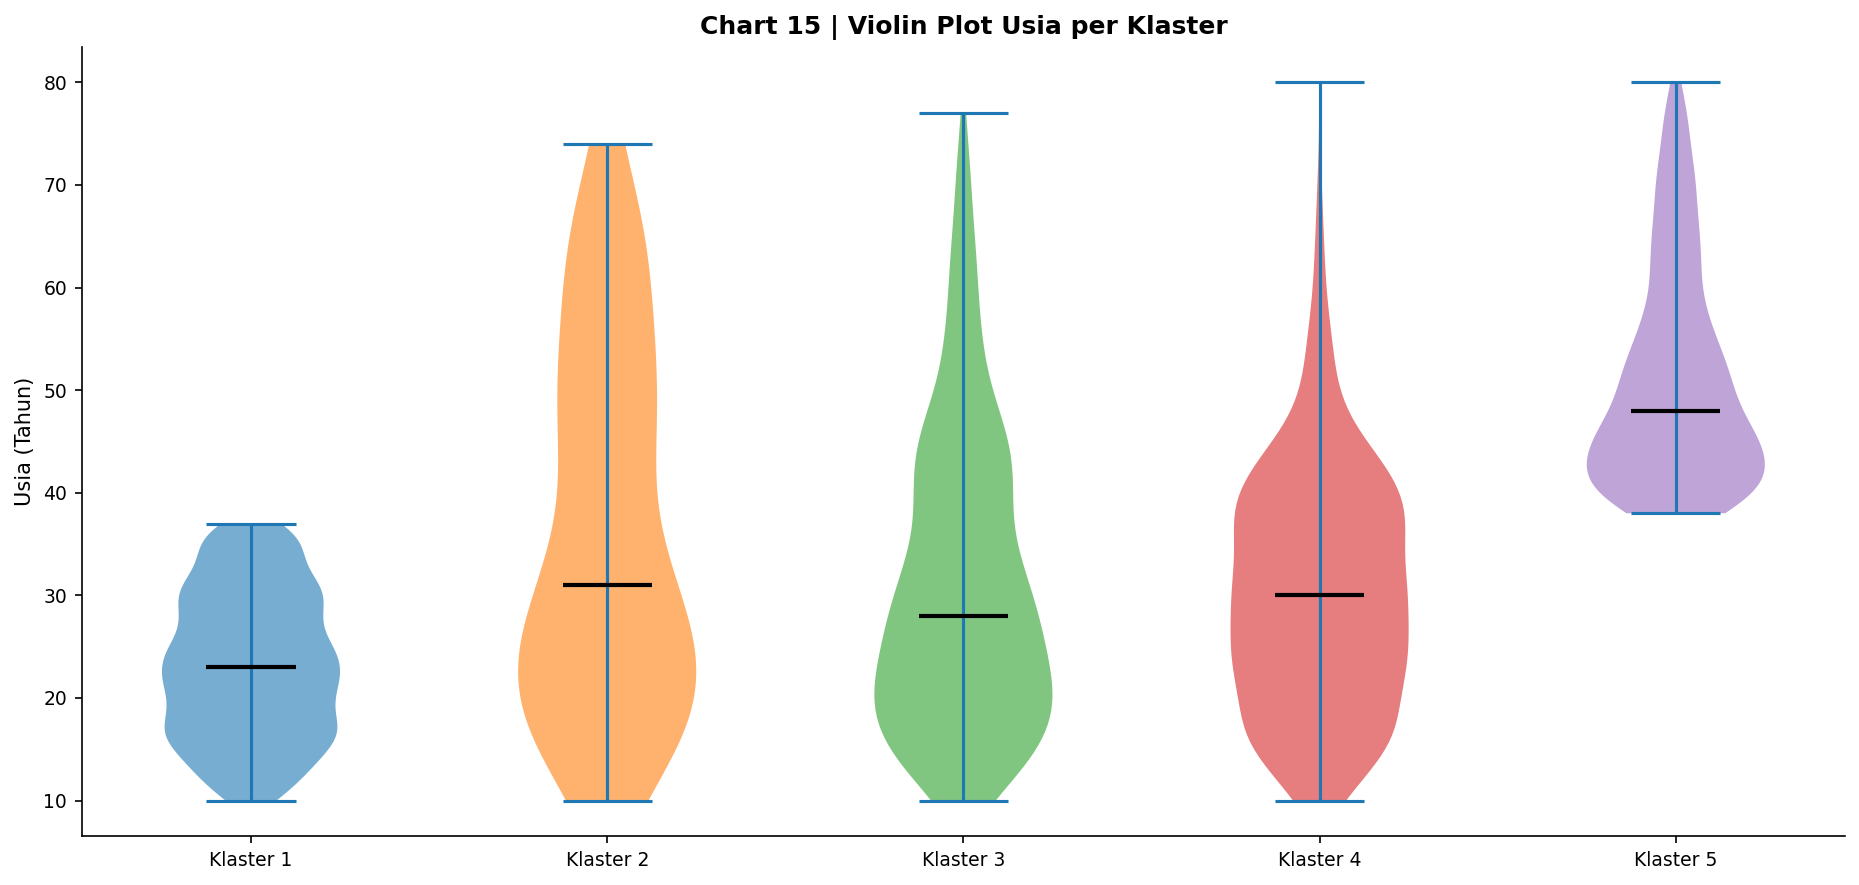

  ✓ Tersimpan → Chart_15_Violin_Usia.png


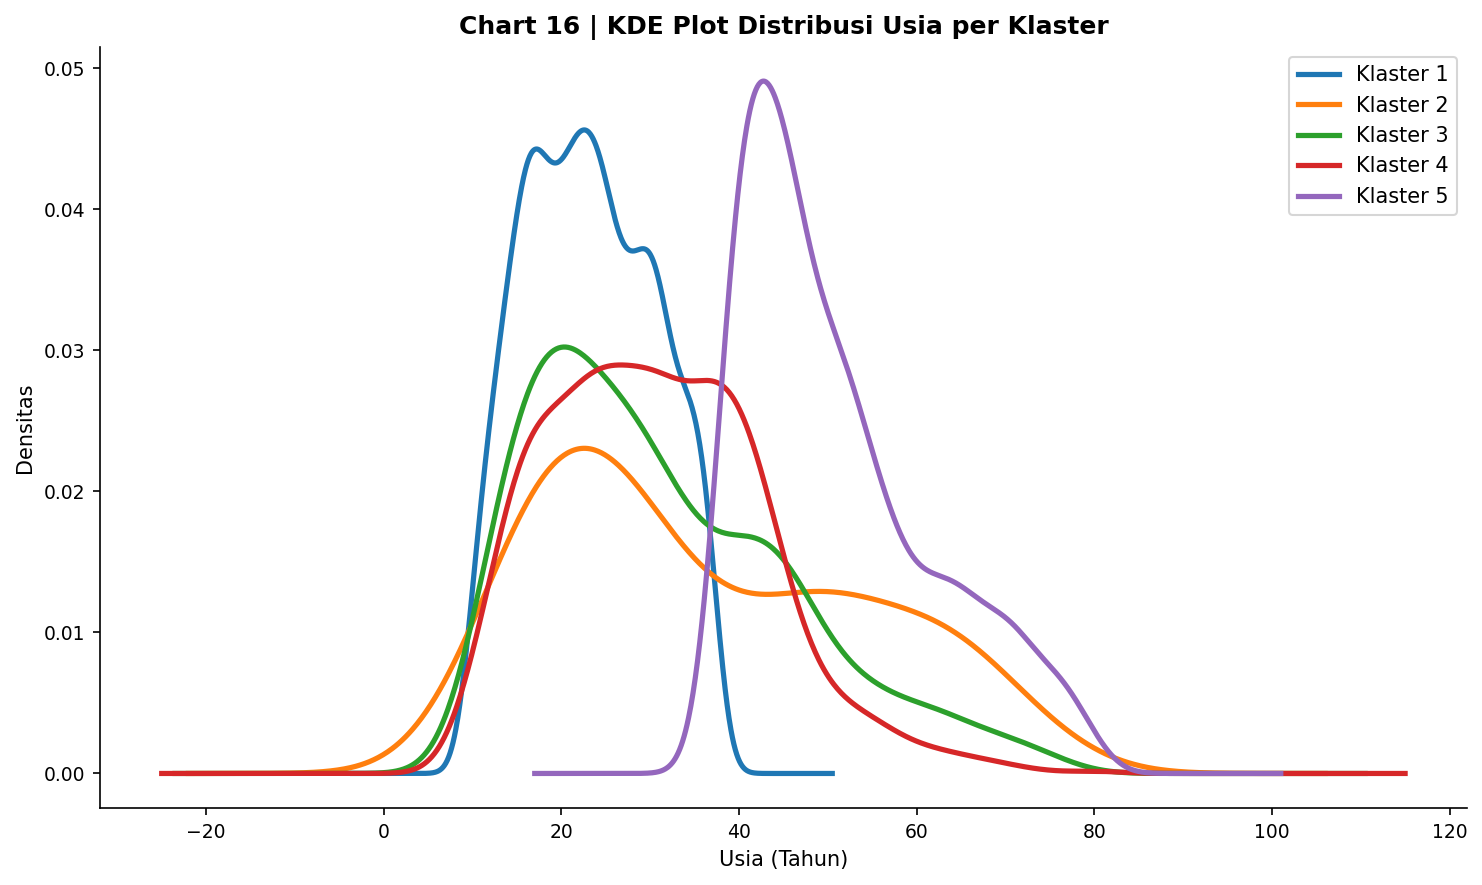

  ✓ Tersimpan → Chart_16_KDE_Usia.png


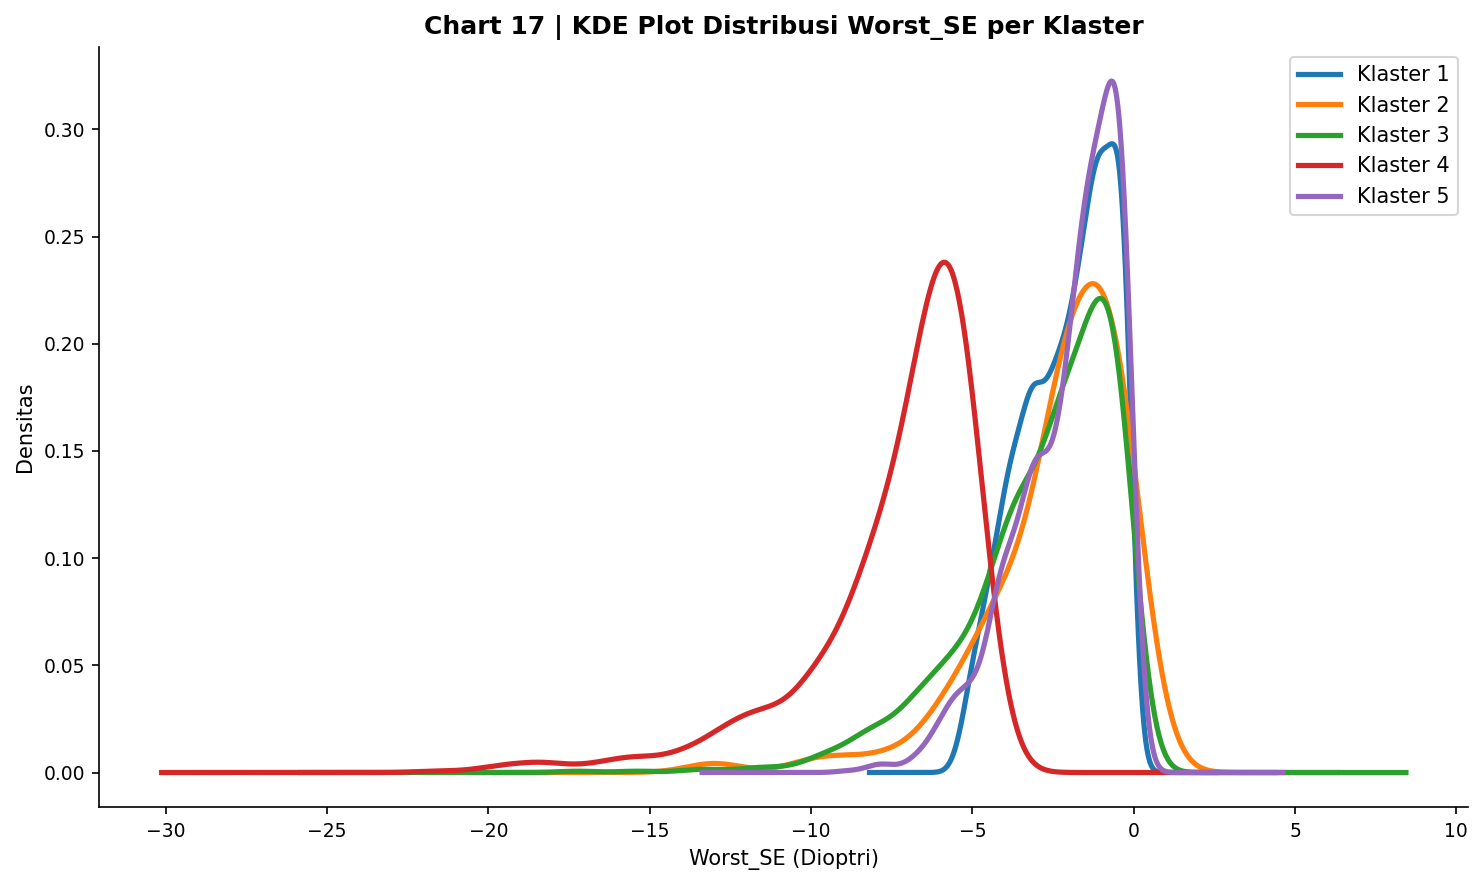

  ✓ Tersimpan → Chart_17_KDE_WorstSE.png


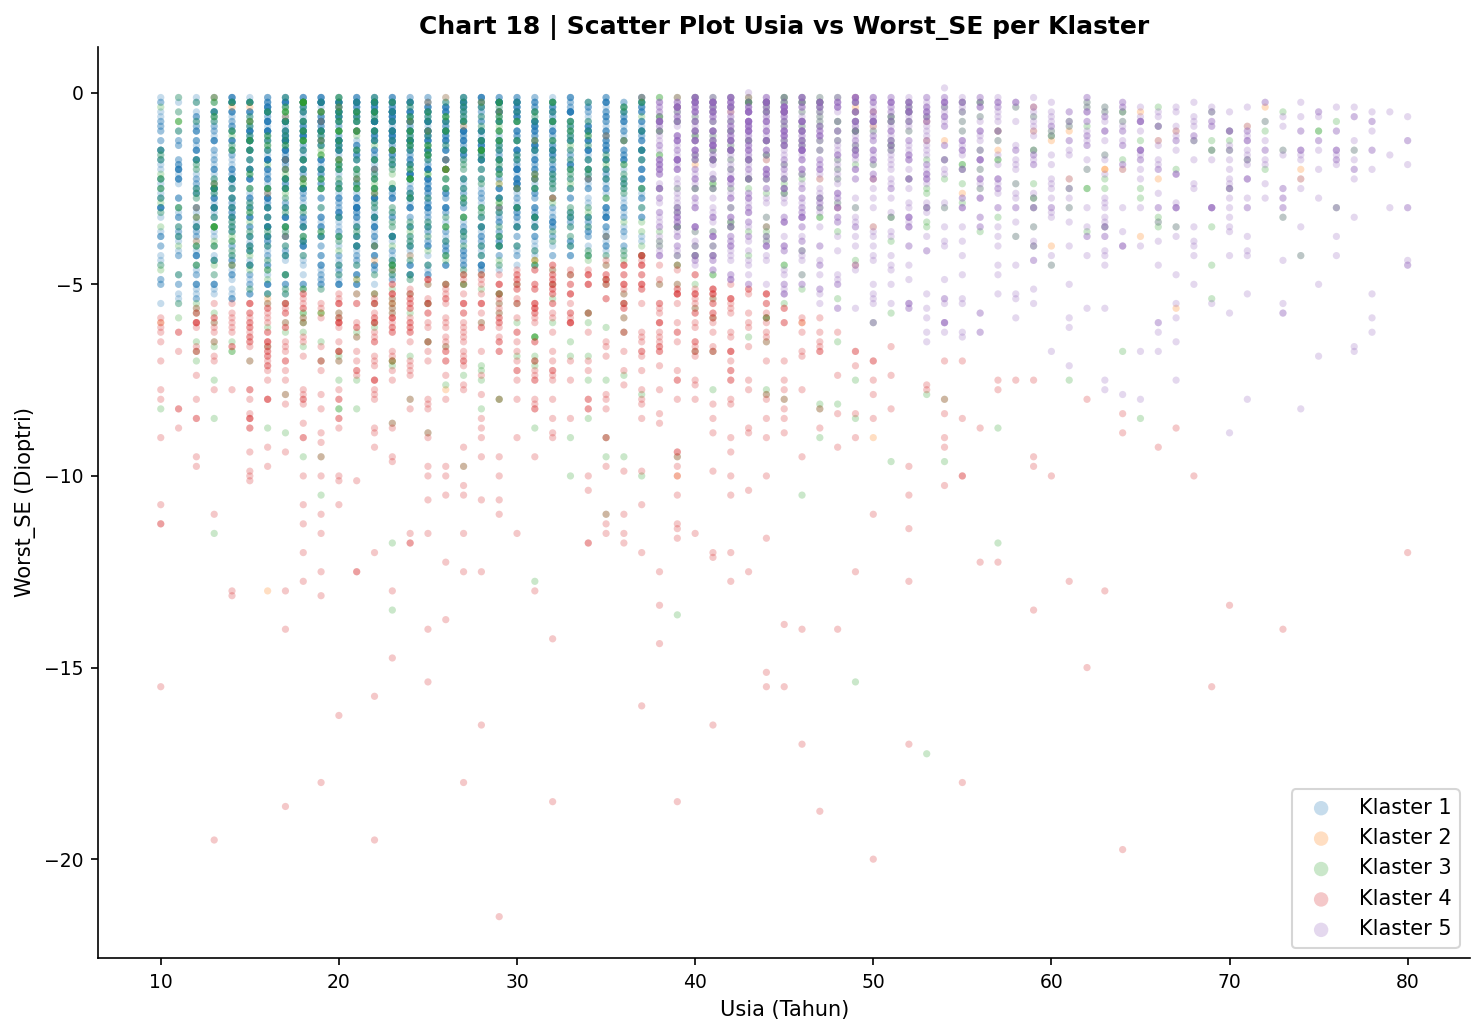

  ✓ Tersimpan → Chart_18_Scatter_Usia_WorstSE.png


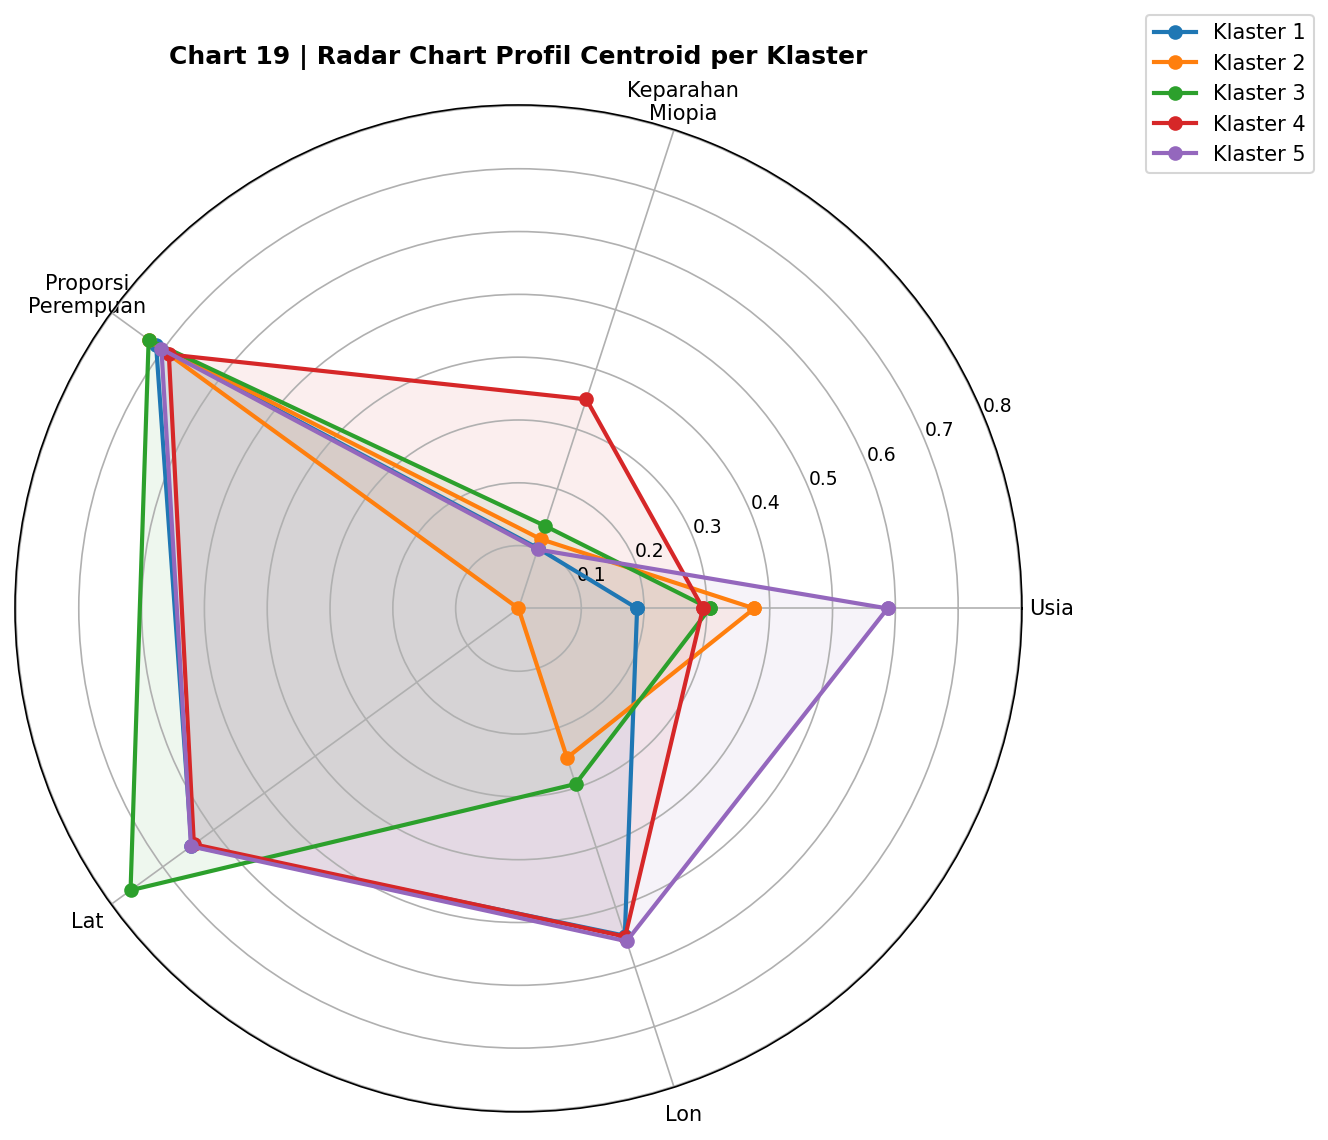

  ✓ Tersimpan → Chart_19_Radar_Centroid.png


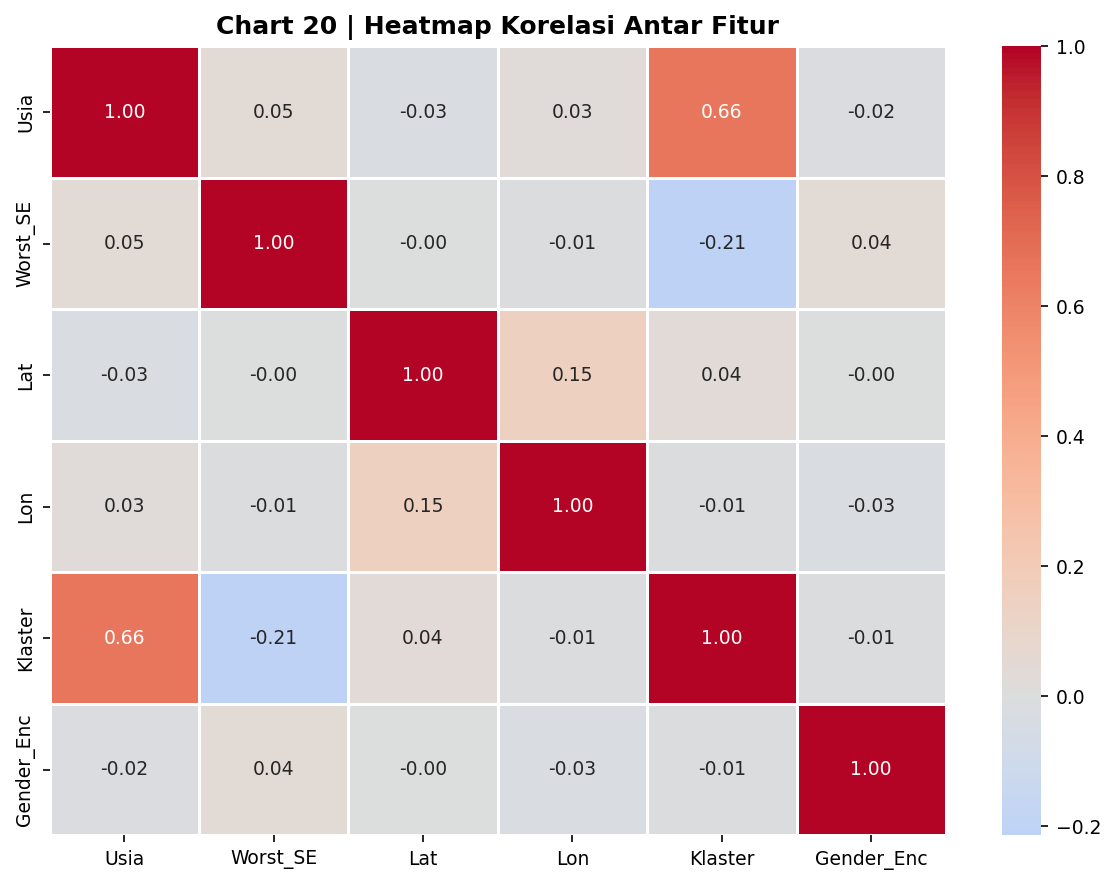

  ✓ Tersimpan → Chart_20_Heatmap_Korelasi.png


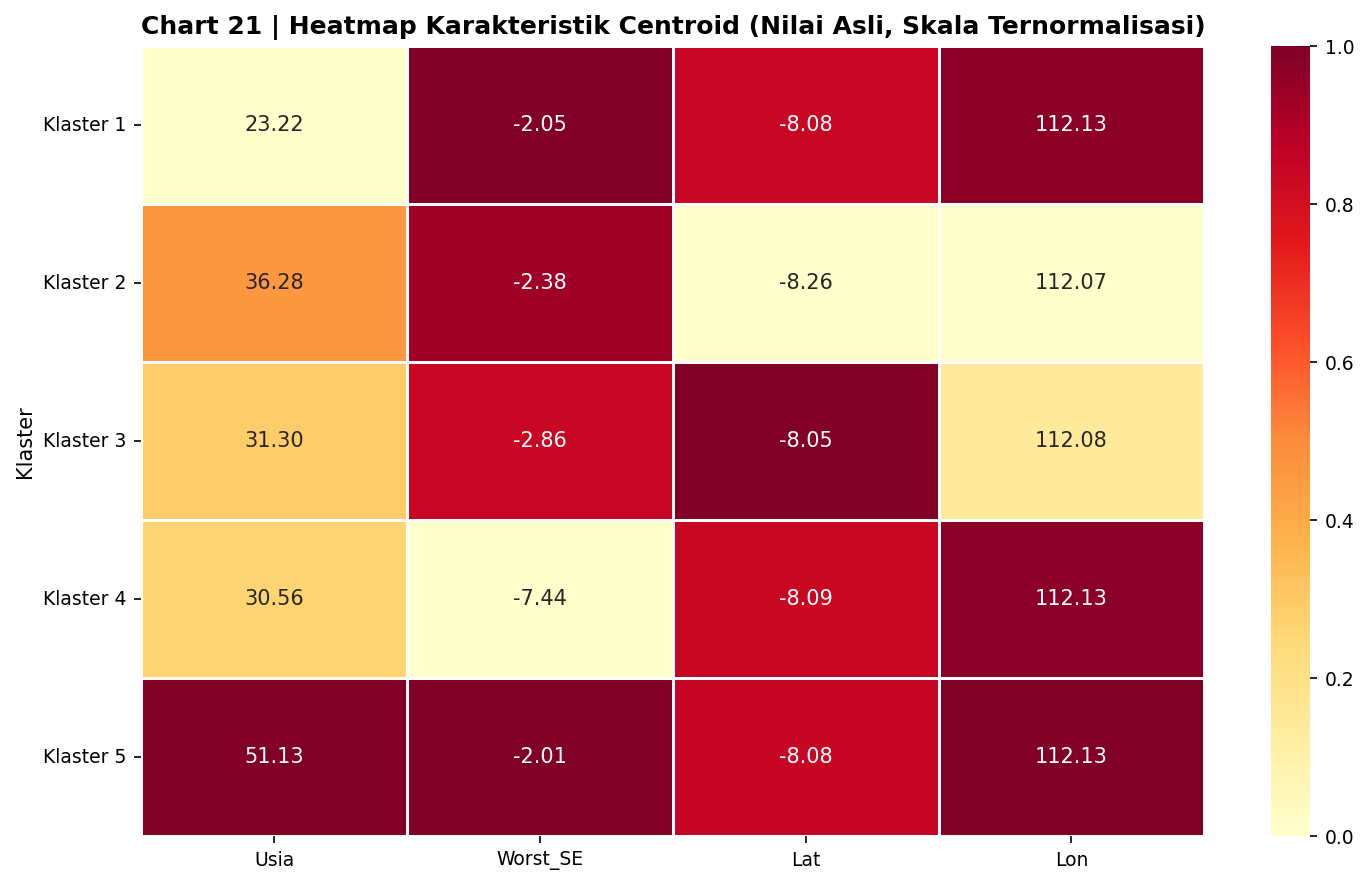

  ✓ Tersimpan → Chart_21_Heatmap_Centroid.png

[SEKSI 4] Visualisasi Spasial...


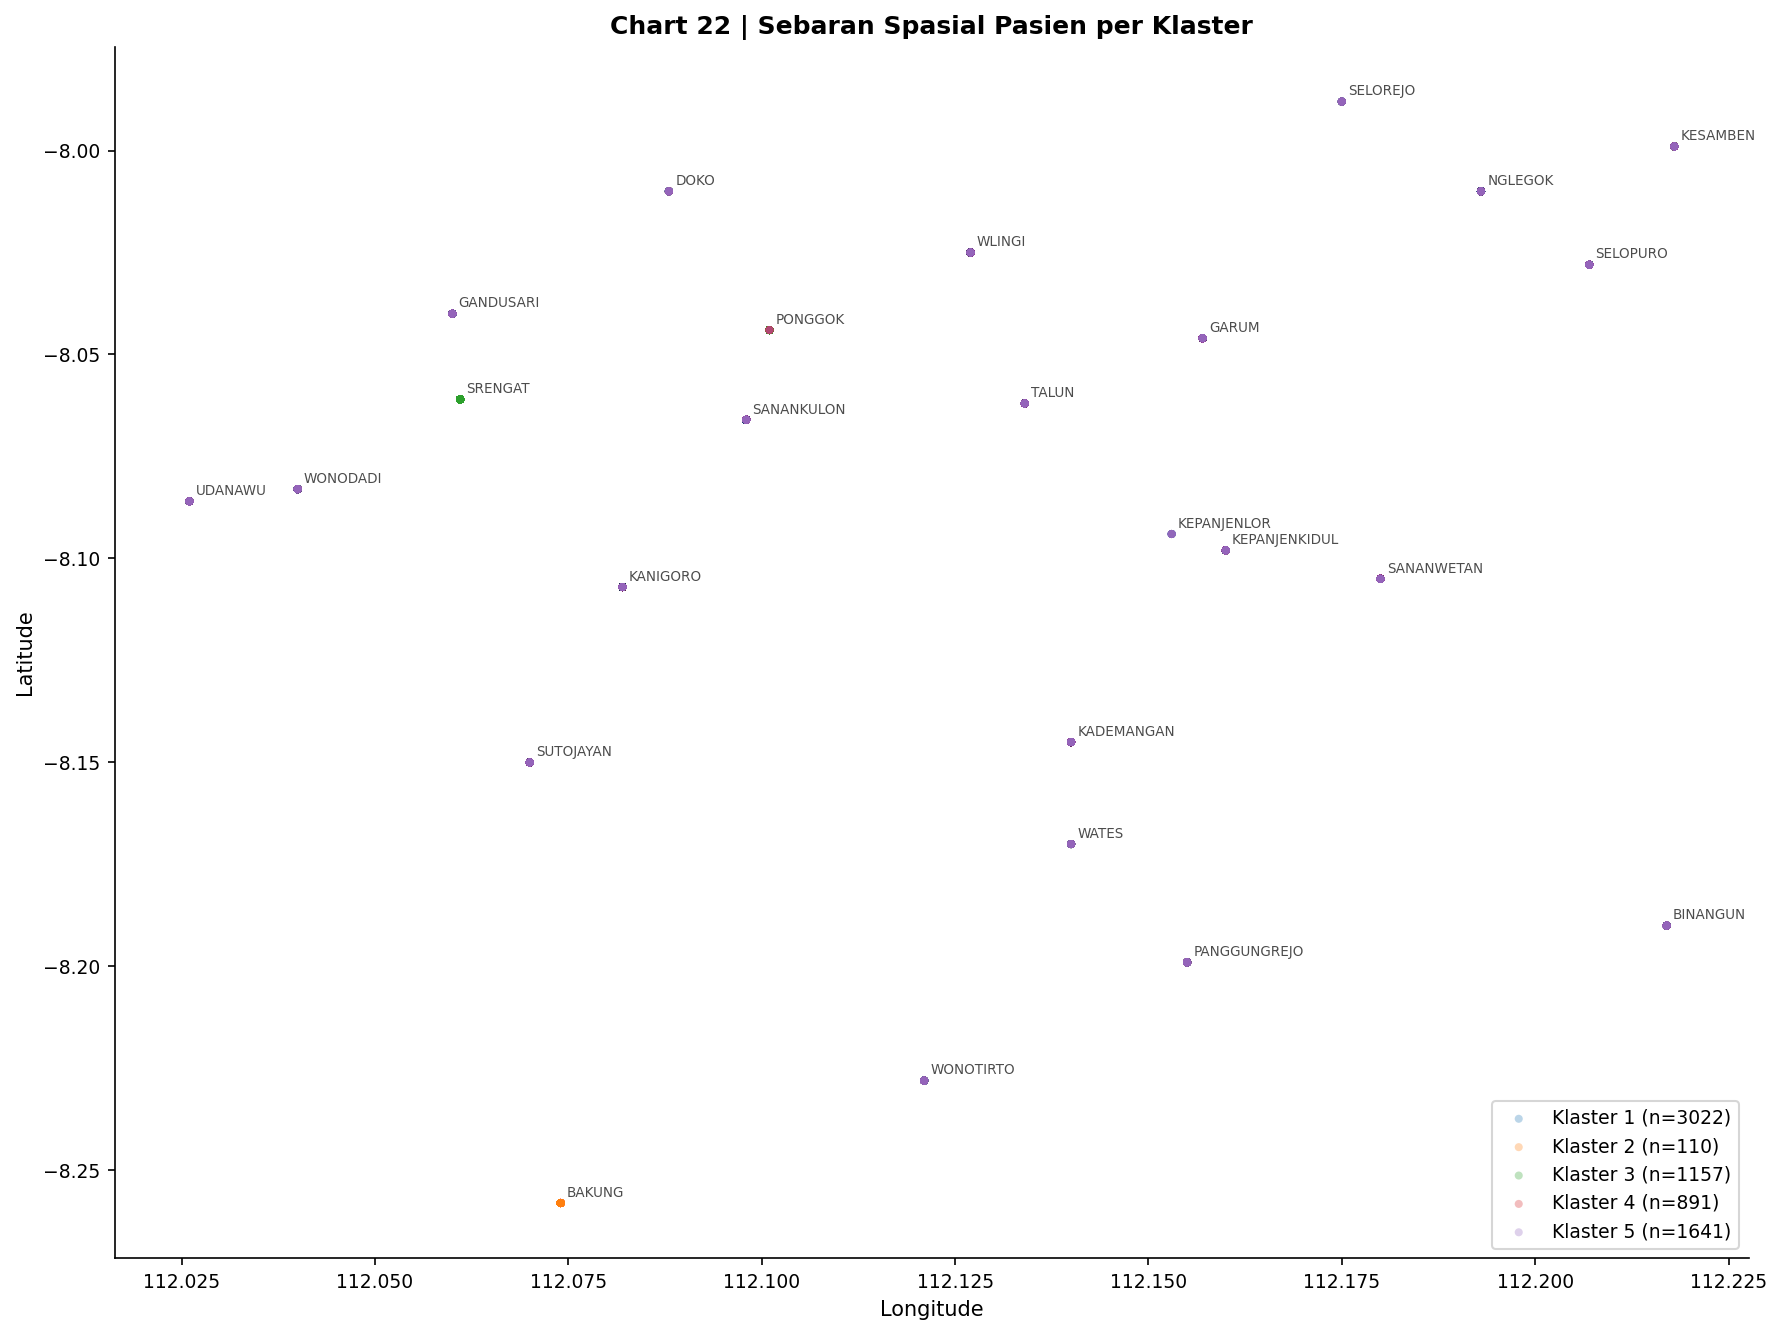

  ✓ Tersimpan → Chart_22_Scatter_Map_Semua.png


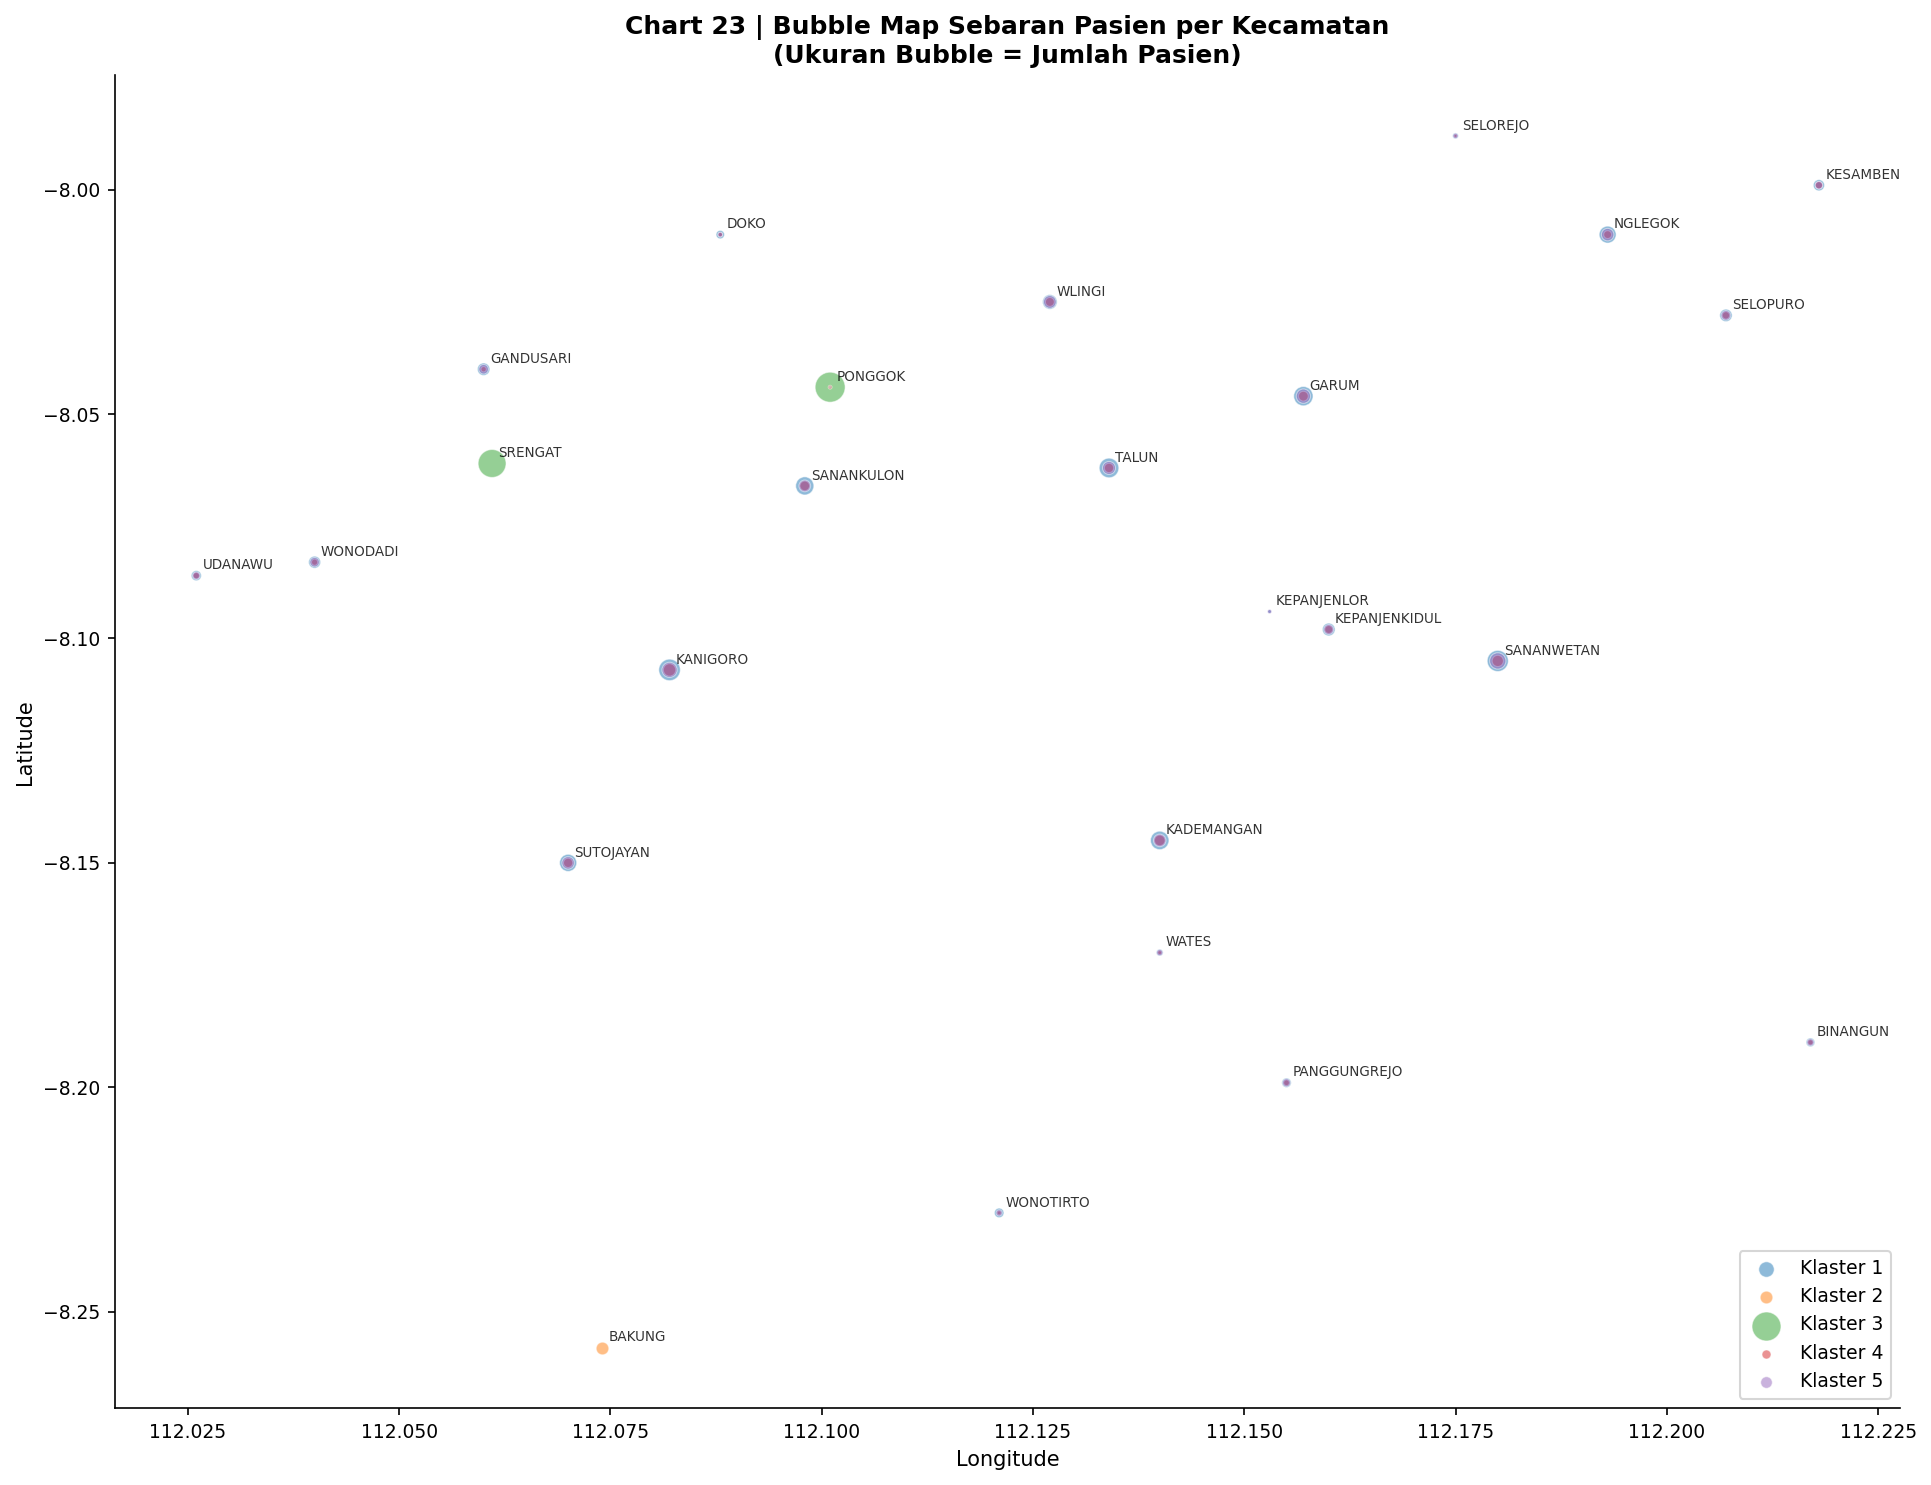

  ✓ Tersimpan → Chart_23_Bubble_Map.png


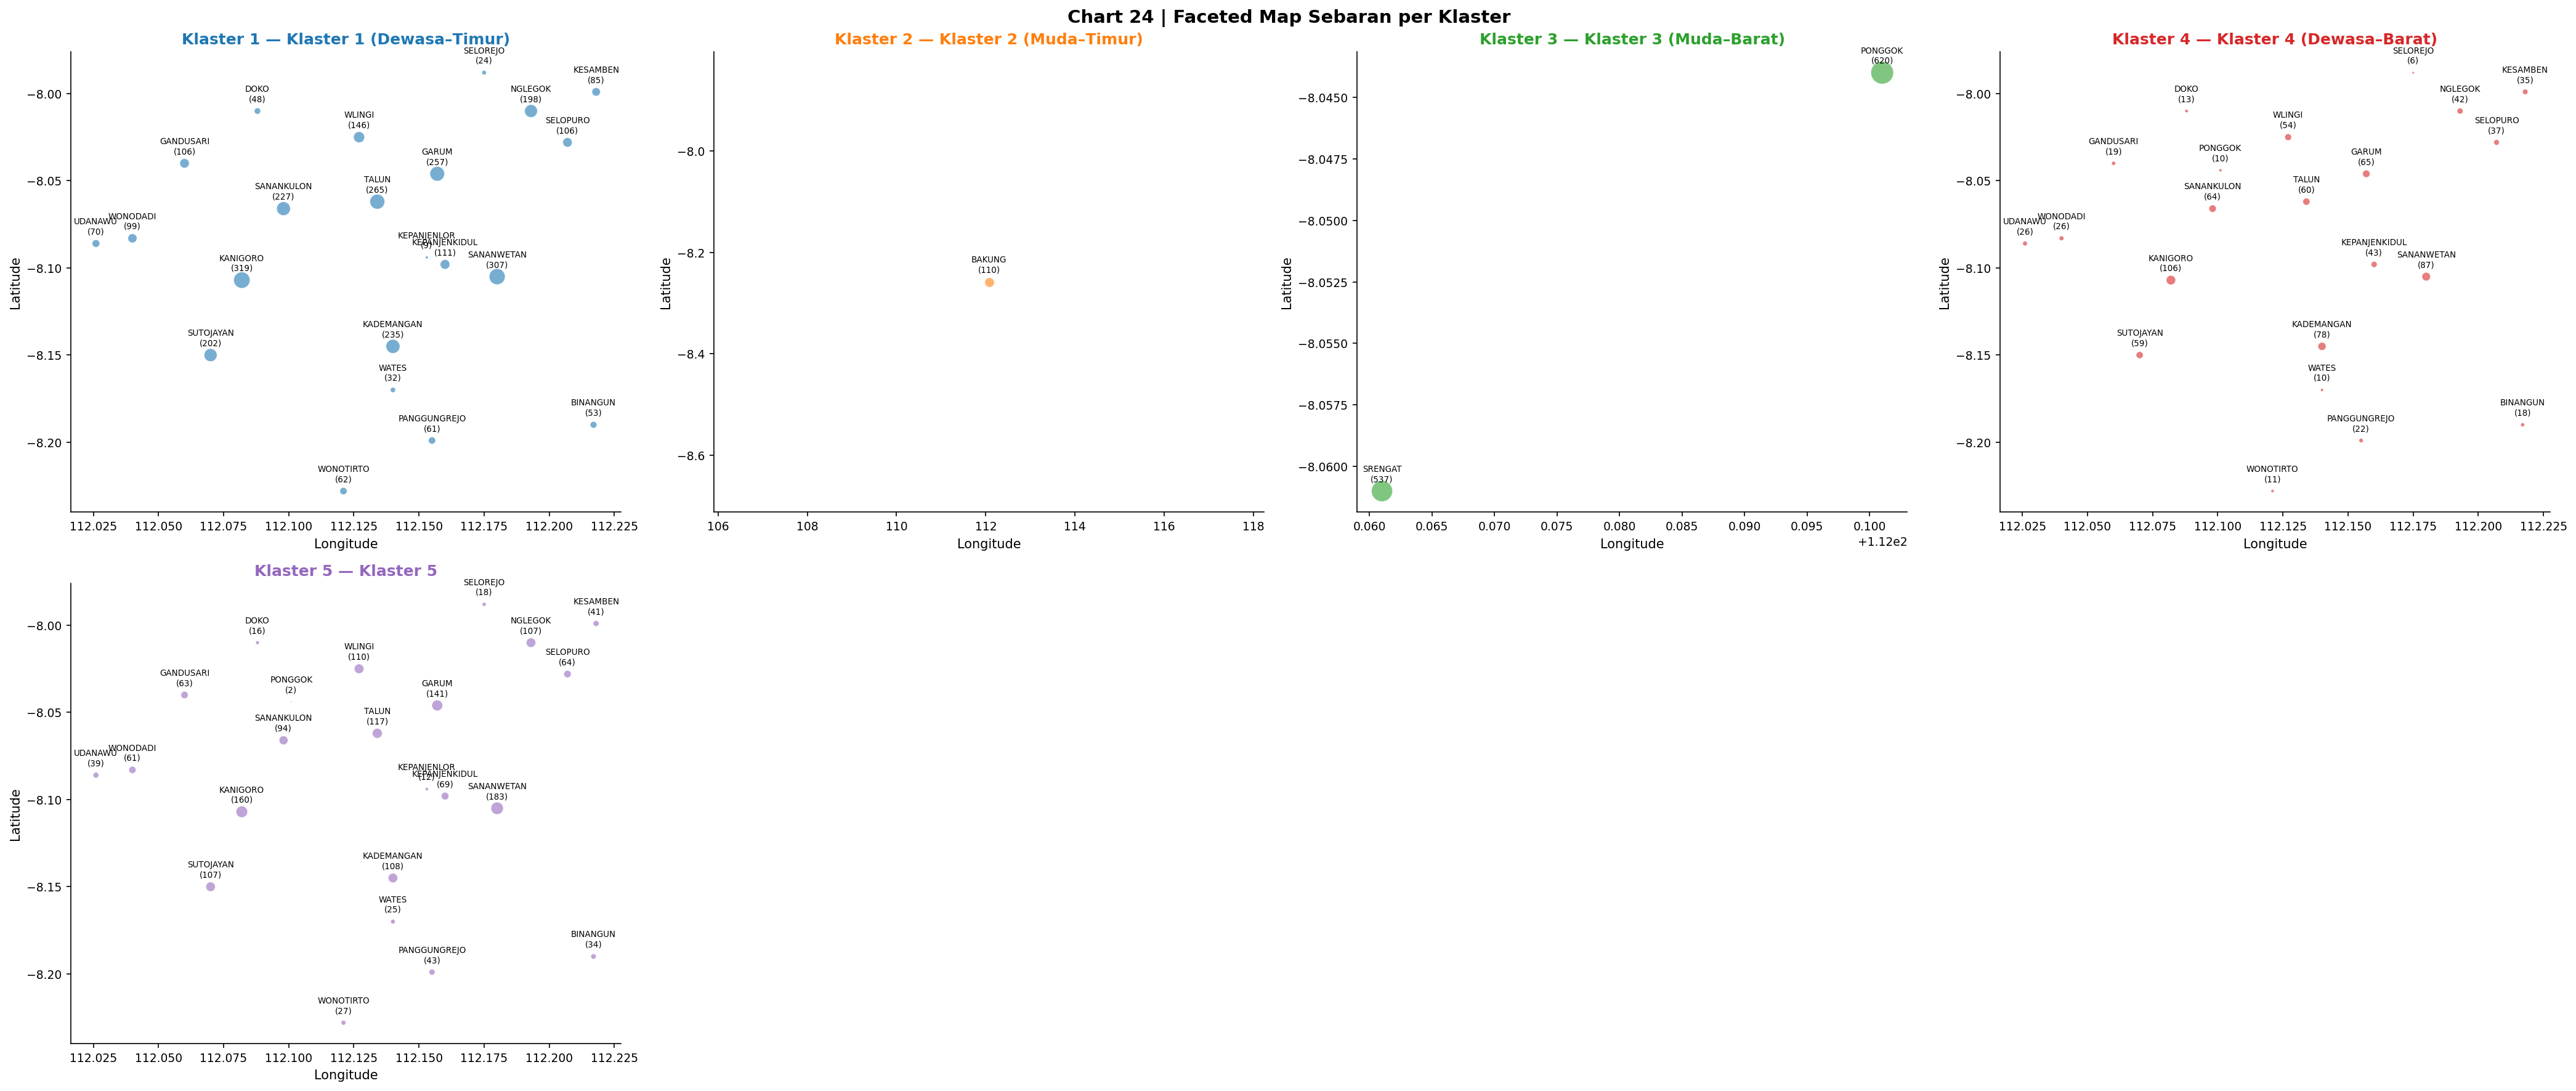

  ✓ Tersimpan → Chart_24_Faceted_Map.png


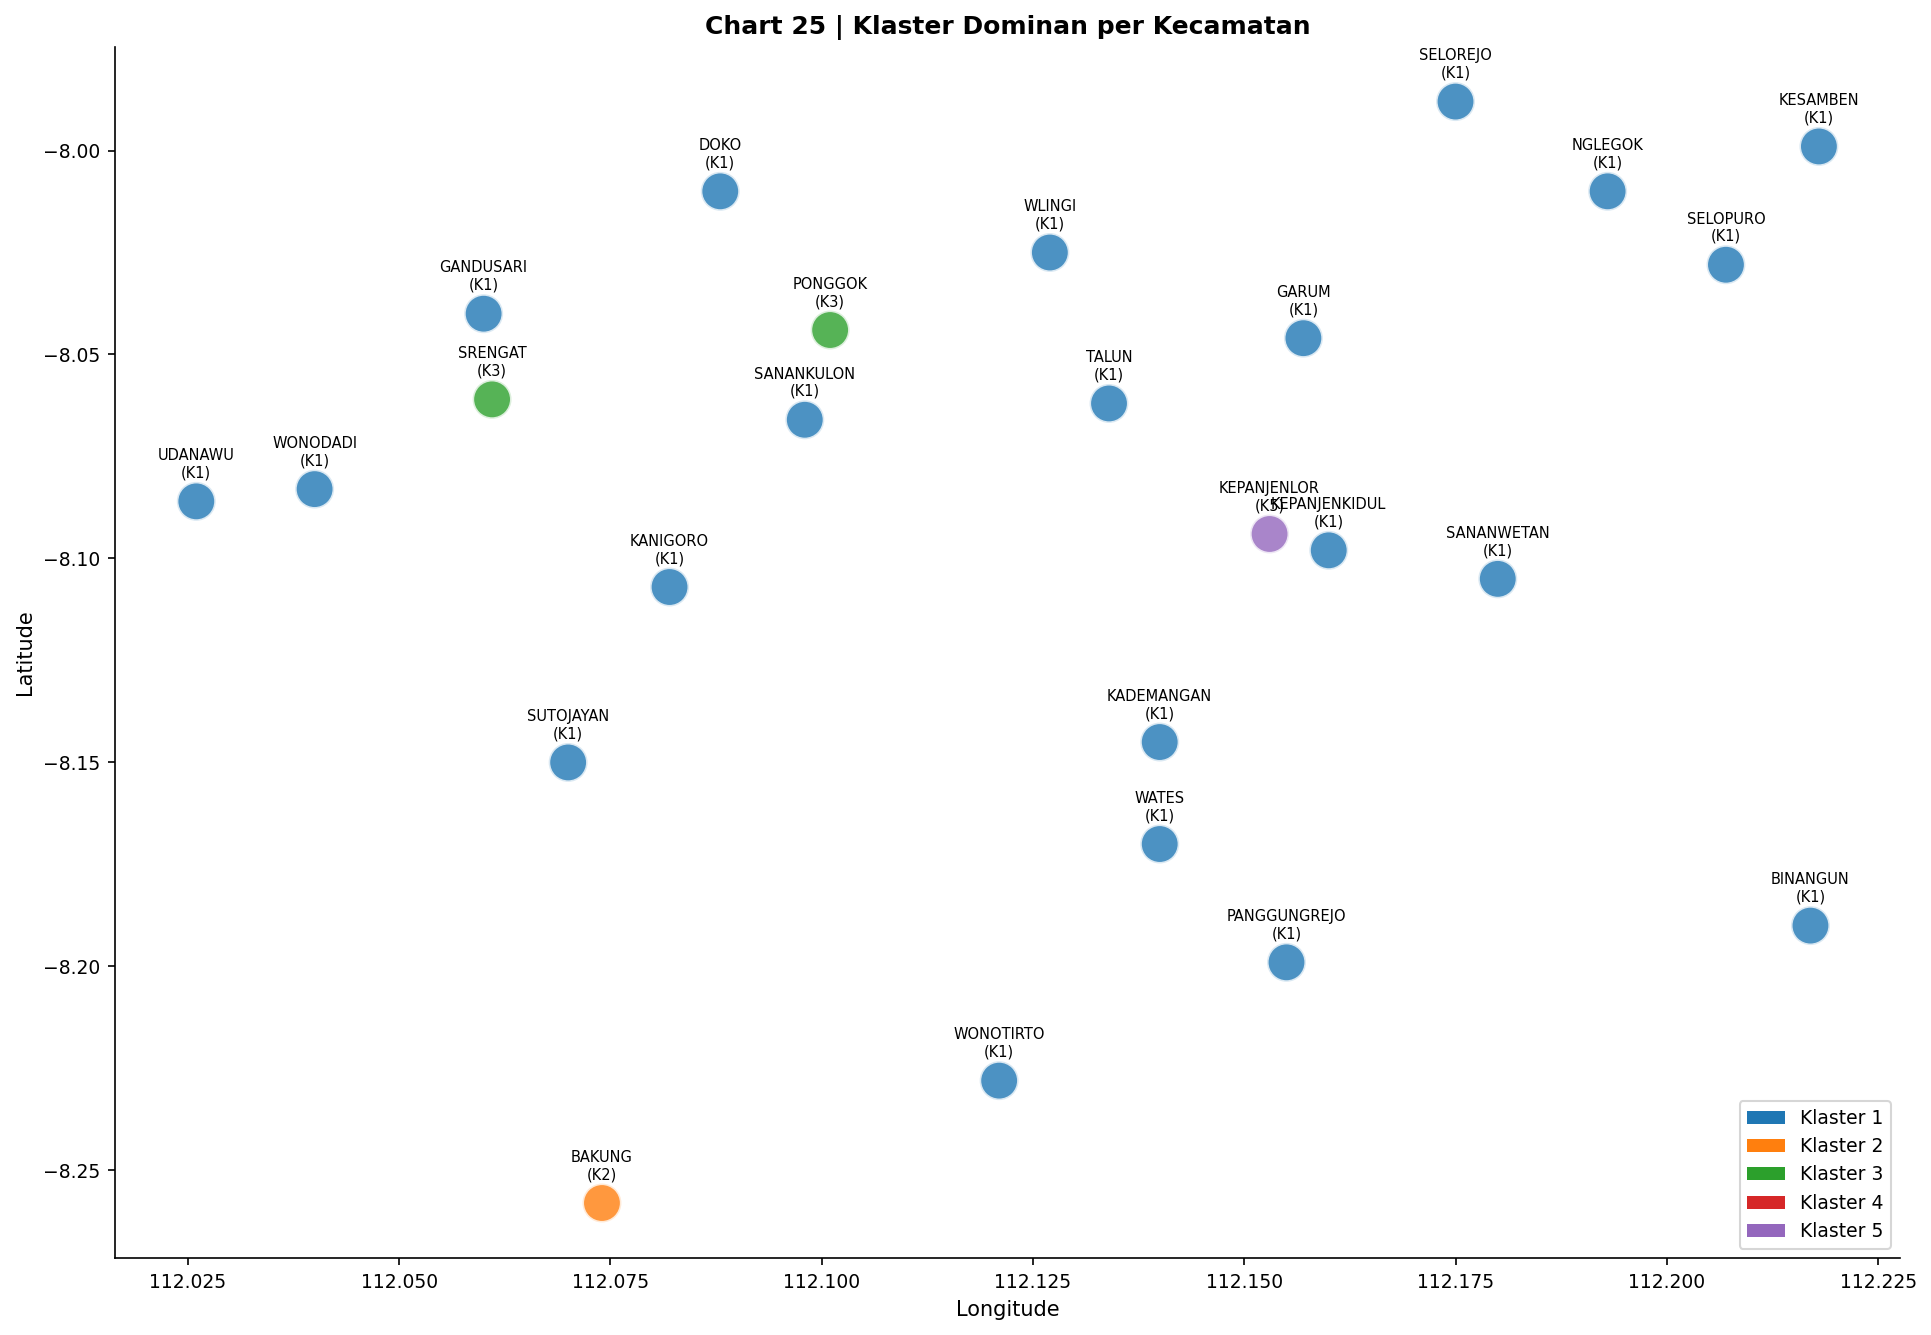

  ✓ Tersimpan → Chart_25_Dominan_Per_Kecamatan.png

[SEKSI 5] Evaluasi & Statistik...


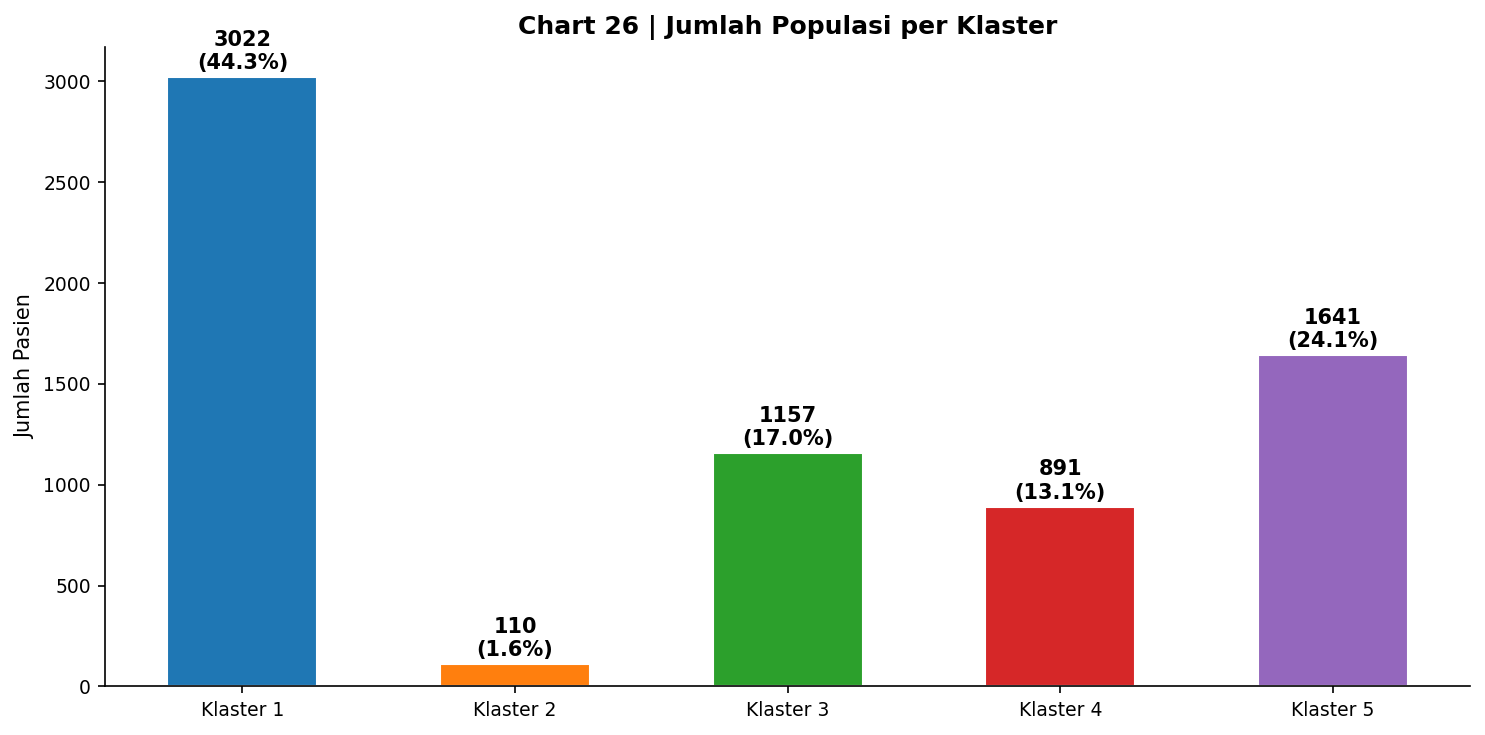

  ✓ Tersimpan → Chart_26_Populasi_Klaster.png


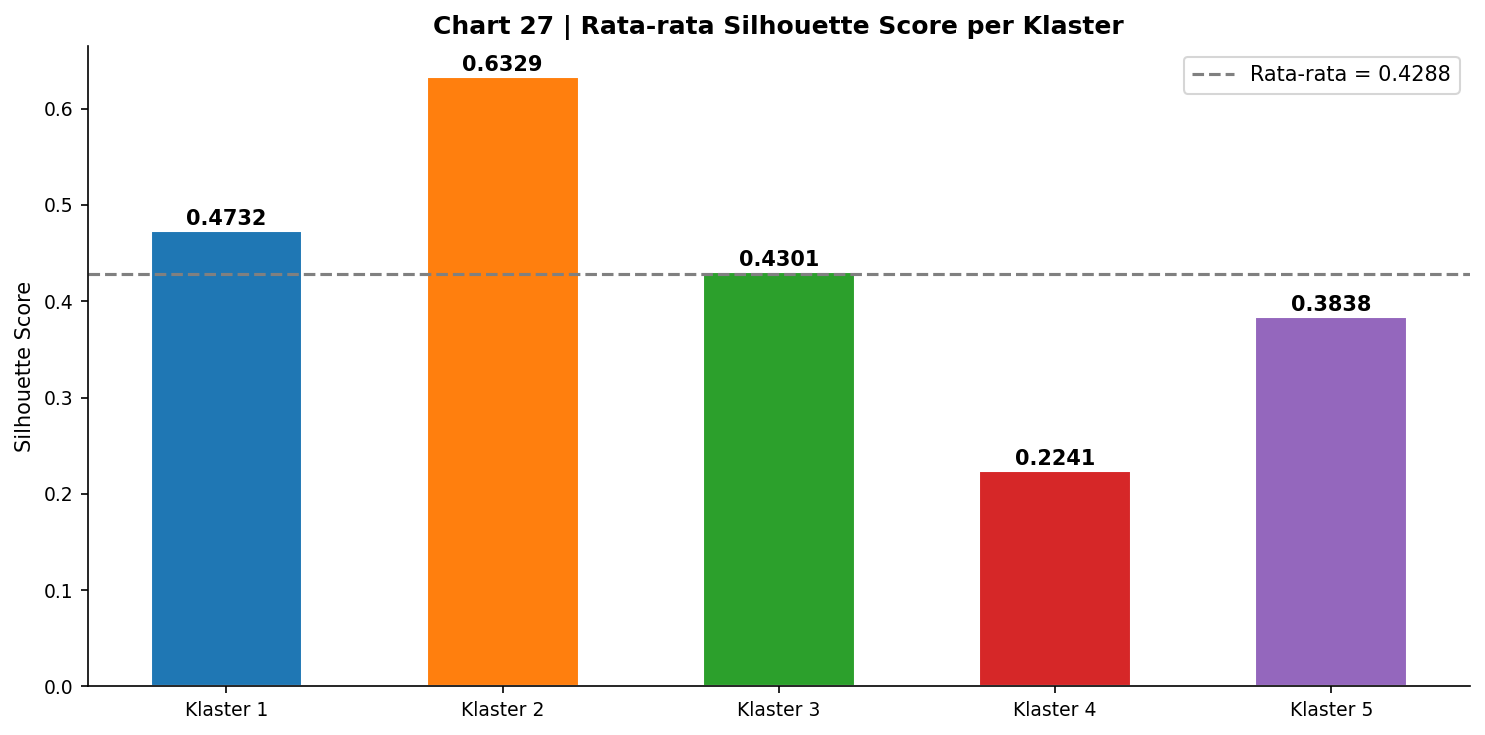

  ✓ Tersimpan → Chart_27_Silhouette_Per_Klaster.png


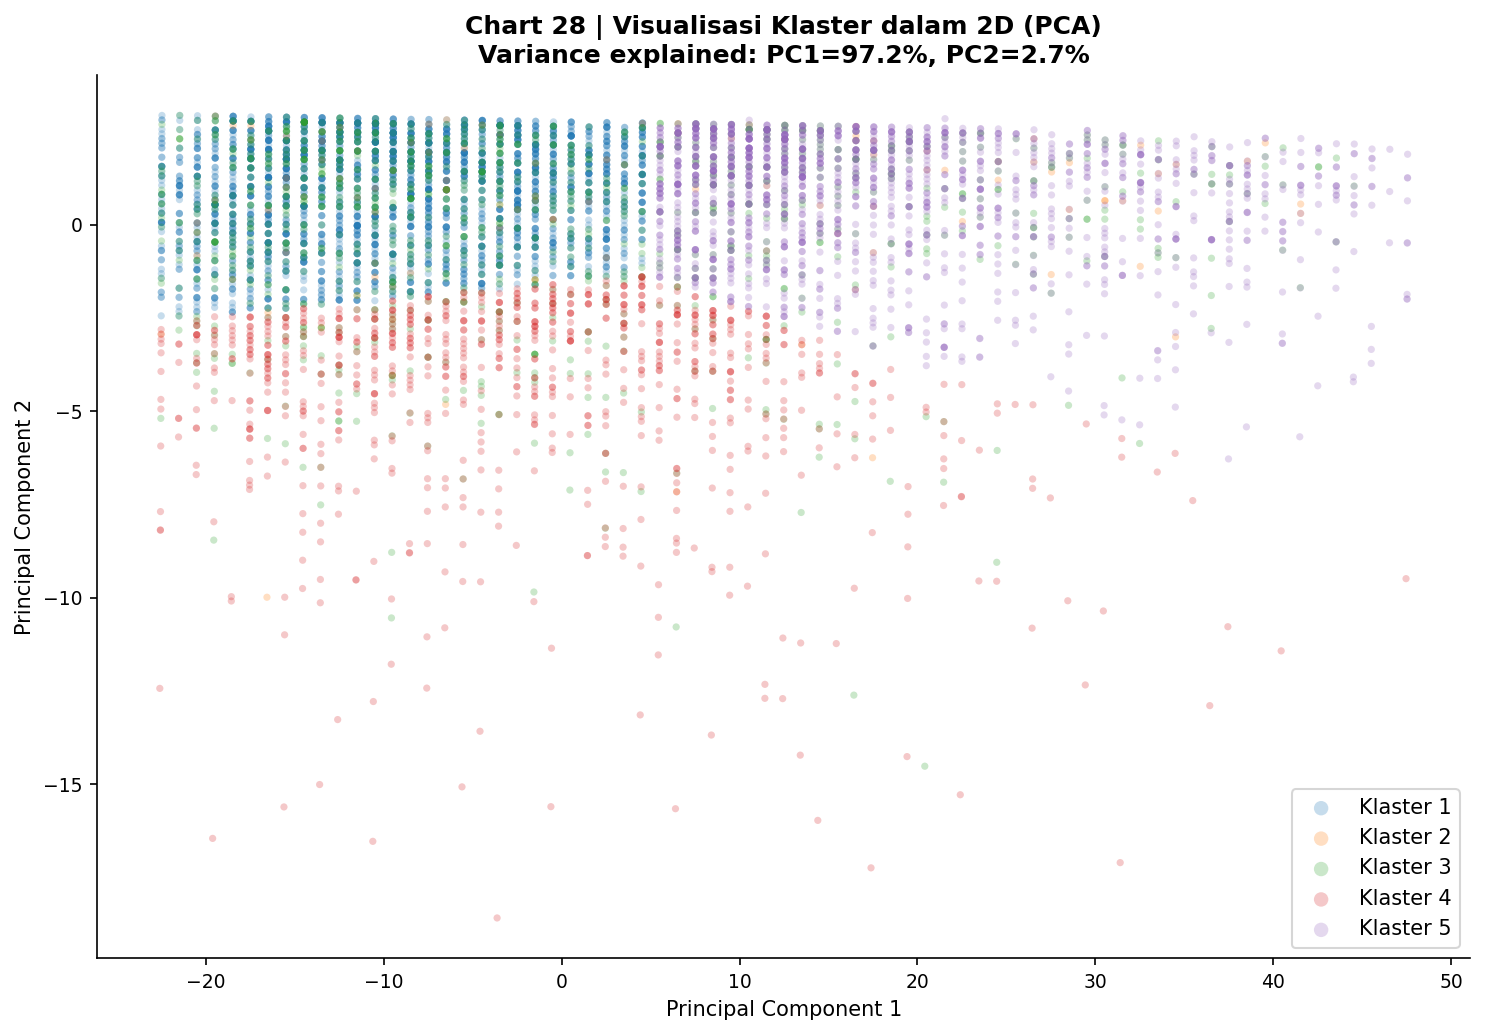

  ✓ Tersimpan → Chart_28_PCA_2D.png


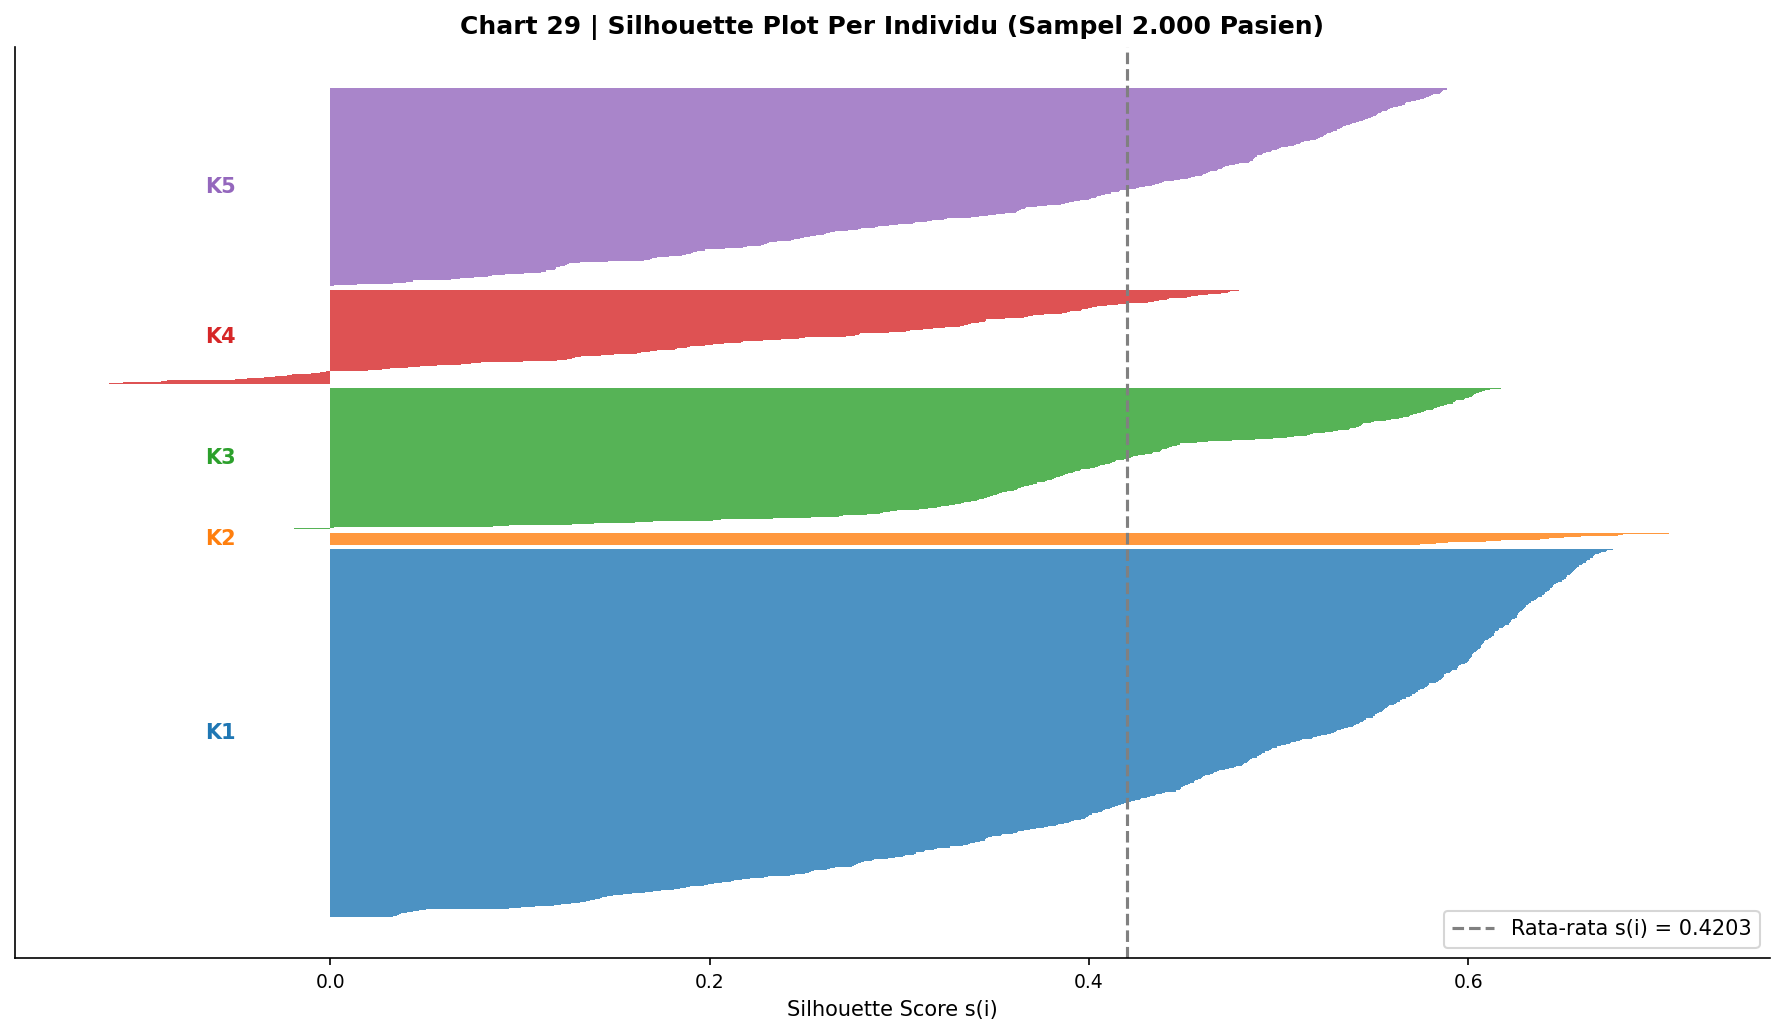

  ✓ Tersimpan → Chart_29_Silhouette_Per_Individu.png

[SEKSI 6] Master Dashboard...


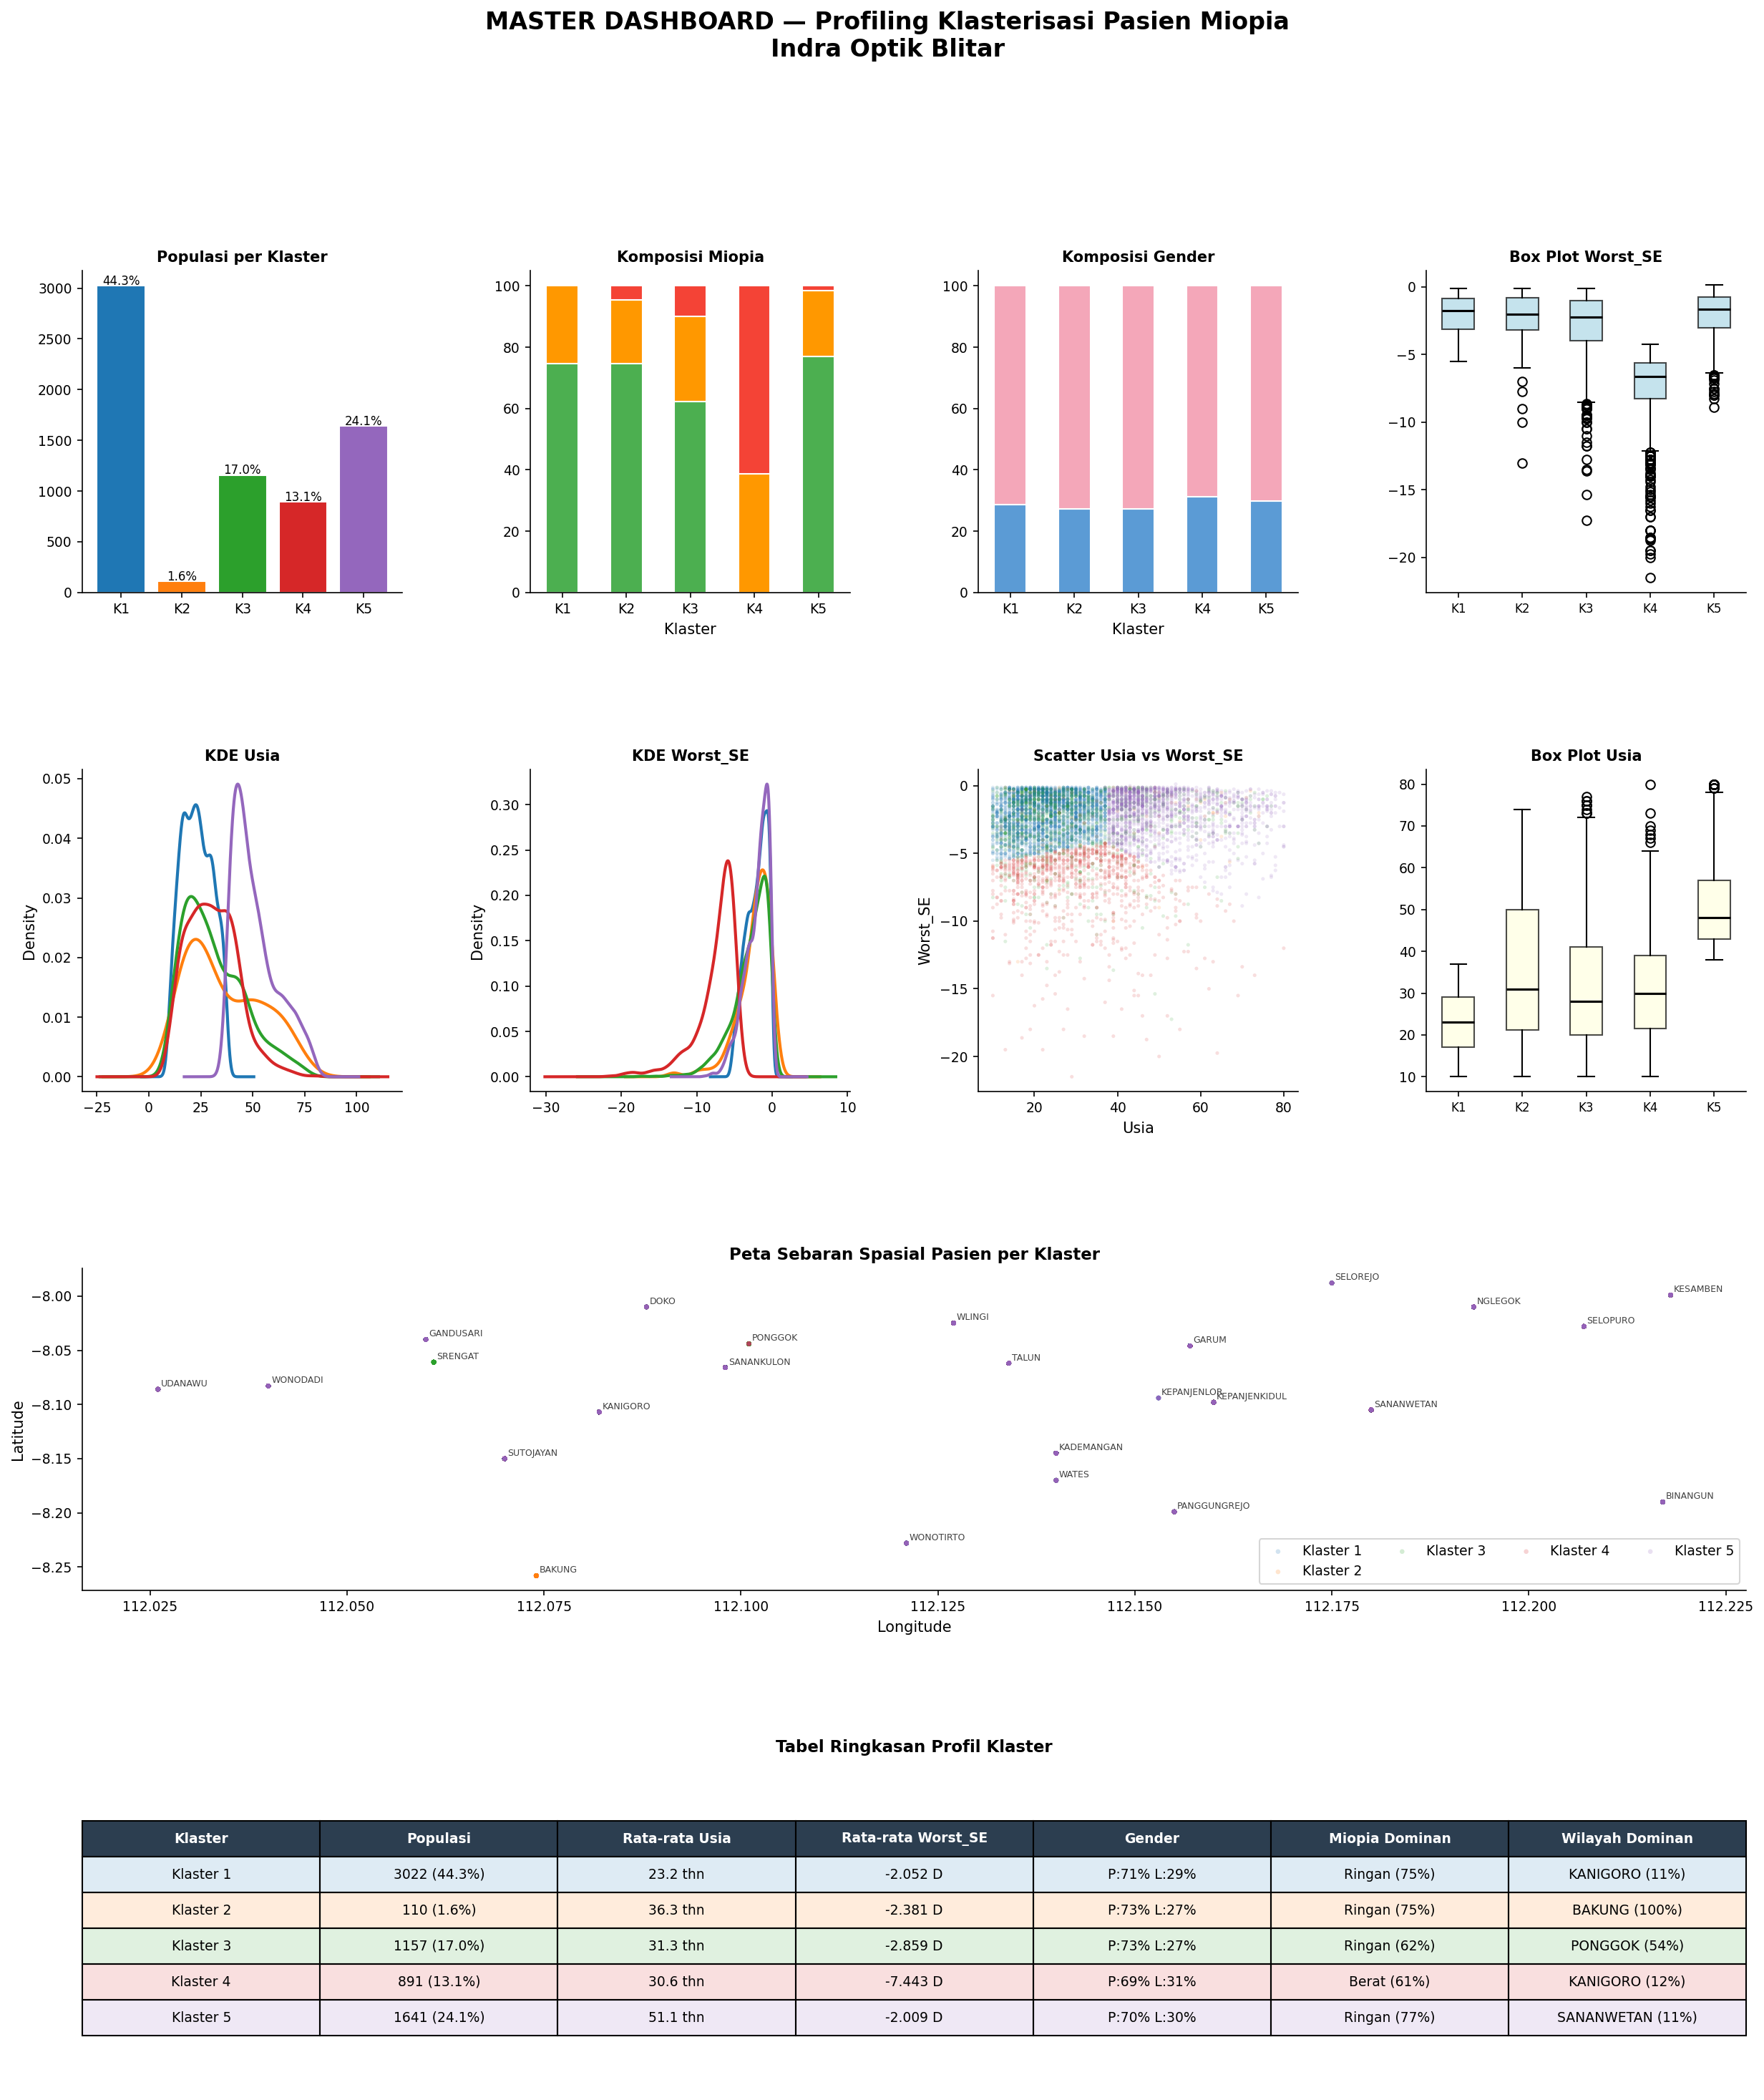

  ✓ Tersimpan → Chart_30_Master_Dashboard.png

  SEMUA CHART BERHASIL DIPROSES & TERSIMPAN!

📁 Lokasi file  : /content/drive/My Drive/SKRIPSI/PROGRAM2/GRAFIK_PROFILING
📊 Jumlah klaster : 5  → [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Daftar file yang dihasilkan:
  ✓ Chart_01_01_Dashboard_Klaster_1.png (151 KB)
  ✓ Chart_01_02_Dashboard_Klaster_2.png (124 KB)
  ✓ Chart_01_03_Dashboard_Klaster_3.png (139 KB)
  ✓ Chart_01_04_Dashboard_Klaster_4.png (151 KB)
  ✓ Chart_01_05_Dashboard_Klaster_5.png (145 KB)
  ✓ Chart_05_Gender_Per_Klaster.png (124 KB)
  ✓ Chart_06_Miopia_Per_Klaster.png (99 KB)
  ✓ Chart_07_Usia_Per_Klaster.png (112 KB)
  ✓ Chart_08_Kecamatan_Per_Klaster.png (121 KB)
  ✓ Chart_09_Stacked_Gender.png (46 KB)
  ✓ Chart_10_Stacked_Miopia.png (58 KB)
  ✓ Chart_11_Rata2_Fitur_Klaster.png (45 KB)
  ✓ Chart_12_Boxplot_Usia.png (36 KB)
  ✓ Chart_13_Boxplot_WorstSE.png (45 KB)
  ✓ Chart_14_Violin_WorstSE.png (53 KB)
  ✓ Chart_15_Violin_Usia.png (63 KB)
  ✓ Ch

In [ ]:
# =============================================================================
# PART 8: PROFILING & VISUALISASI LENGKAP HASIL KLASTERISASI K-MEANS
# Versi DINAMIS — otomatis menyesuaikan jumlah klaster dari data
# =============================================================================

import sys
!{sys.executable} -m pip install squarify contextily --quiet

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from sklearn.decomposition import PCA
import warnings
import os

warnings.filterwarnings('ignore')

try:
    import squarify
    SQUARIFY_OK = True
except:
    SQUARIFY_OK = False

try:
    import contextily as ctx
    CONTEXTILY_OK = True
except:
    CONTEXTILY_OK = False

# =============================================================================
# KONFIGURASI PATH
# =============================================================================
path_drive      = '/content/drive/My Drive/SKRIPSI/PROGRAM2'
file_utama      = os.path.join(path_drive, '8_Data_Denormalisasi.xlsx')
file_silhouette = os.path.join(path_drive, '7_Hasil_Evaluasi_Silhouette.xlsx')
output_dir      = os.path.join(path_drive, 'GRAFIK_PROFILING')
os.makedirs(output_dir, exist_ok=True)

# =============================================================================
# WARNA TETAP (non-klaster)
# =============================================================================
WARNA_MIOPIA = {'Ringan': '#4CAF50', 'Sedang': '#FF9800', 'Berat': '#F44336'}
WARNA_GENDER = {'L': '#5B9BD5', 'P': '#F4A7B9'}
urut_miopia  = ['Ringan', 'Sedang', 'Berat']

plt.rcParams.update({
    'figure.dpi'     : 150,
    'font.family'    : 'DejaVu Sans',
    'axes.titlesize' : 12,
    'axes.labelsize' : 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

def simpan(fig, nama_file):
    path = os.path.join(output_dir, nama_file)
    fig.savefig(path, bbox_inches='tight', dpi=150, facecolor='white')
    plt.show()
    print(f"  ✓ Tersimpan → {nama_file}")
    plt.close(fig)

# =============================================================================
# LOAD DATA
# =============================================================================
print("=" * 65)
print("  PART 8: PROFILING & VISUALISASI LENGKAP K-MEANS")
print("=" * 65)

df = pd.read_excel(file_utama)

# =============================================================================
# AUTO-DETECT KLASTER → semua konfigurasi ikut otomatis
# =============================================================================
KLASTERS   = sorted(df['Klaster'].unique())
N_KLASTER  = len(KLASTERS)

# Palet warna — cukup untuk 10 klaster, tambah jika perlu
_COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
    '#bcbd22', '#17becf'
]
PALET = {k: _COLORS[i % len(_COLORS)] for i, k in enumerate(KLASTERS)}

# Label klaster — edit sesuai interpretasi penelitian
# Jika klaster tidak ada di dict ini, label fallback otomatis dipakai
_LABEL_CUSTOM = {
    1: 'Klaster 1 (Dewasa–Timur)',
    2: 'Klaster 2 (Muda–Timur)',
    3: 'Klaster 3 (Muda–Barat)',
    4: 'Klaster 4 (Dewasa–Barat)',
}
LABEL_KLASTER = {k: _LABEL_CUSTOM.get(k, f'Klaster {k}') for k in KLASTERS}
WARNA_LIST    = [PALET[k] for k in KLASTERS]

# =============================================================================
# KOORDINAT KECAMATAN
# =============================================================================
KOORDINAT = {
    'BAKUNG'       : (-8.258, 112.074),
    'BINANGUN'     : (-8.190, 112.217),
    'DOKO'         : (-8.010, 112.088),
    'GANDUSARI'    : (-8.040, 112.060),
    'GARUM'        : (-8.046, 112.157),
    'KADEMANGAN'   : (-8.145, 112.140),
    'KANIGORO'     : (-8.107, 112.082),
    'KEPANJENKIDUL': (-8.098, 112.160),
    'KEPANJENLOR'  : (-8.094, 112.153),
    'KESAMBEN'     : (-7.999, 112.218),
    'NGLEGOK'      : (-8.010, 112.193),
    'PANGGUNGREJO' : (-8.199, 112.155),
    'PONGGOK'      : (-8.044, 112.101),
    'SANANKULON'   : (-8.066, 112.098),
    'SANANWETAN'   : (-8.105, 112.180),
    'SELOPURO'     : (-8.028, 112.207),
    'SELOREJO'     : (-7.988, 112.175),
    'SRENGAT'      : (-8.061, 112.061),
    'SUTOJAYAN'    : (-8.150, 112.070),
    'TALUN'        : (-8.062, 112.134),
    'UDANAWU'      : (-8.086, 112.026),
    'WATES'        : (-8.170, 112.140),
    'WLINGI'       : (-8.025, 112.127),
    'WONODADI'     : (-8.083, 112.040),
    'WONOTIRTO'    : (-8.228, 112.121),
}

# =============================================================================
# FEATURE ENGINEERING
# =============================================================================
df['Lat'] = df['Alamat'].map(lambda x: KOORDINAT.get(x, (-8.09, 112.16))[0])
df['Lon'] = df['Alamat'].map(lambda x: KOORDINAT.get(x, (-8.09, 112.16))[1])

def kat_miopia(se):
    if se >= -3.00:   return 'Ringan'
    elif se >= -6.00: return 'Sedang'
    else:             return 'Berat'

df['Kategori_Miopia'] = df['Worst_SE'].apply(kat_miopia)

bins_u  = [0, 17, 25, 35, 45, 60, 120]
label_u = ['≤17', '18–25', '26–35', '36–45', '46–60', '>60']
df['Kelompok_Usia'] = pd.cut(df['Usia'], bins=bins_u, labels=label_u)
df['Warna']         = df['Klaster'].map(PALET)

n_total = len(df)
print(f"\n✓ Data berhasil dimuat  : {n_total} pasien")
print(f"✓ Jumlah klaster        : {N_KLASTER}  → {KLASTERS}")
print(f"✓ Output folder         : {output_dir}\n")

# Precompute data box (dipakai di beberapa chart)
data_box_usia = [df[df['Klaster'] == k]['Usia'].values     for k in KLASTERS]
data_box_se   = [df[df['Klaster'] == k]['Worst_SE'].values for k in KLASTERS]

# Precompute stacked pct (dipakai di Chart 09, 10, Master Dashboard)
gender_pct = df.groupby(['Klaster', 'Gender']).size().unstack(fill_value=0)
gender_pct = gender_pct.div(gender_pct.sum(axis=1), axis=0) * 100

mio_pct = df.groupby(['Klaster', 'Kategori_Miopia']).size().unstack(fill_value=0)
mio_pct = mio_pct.reindex(columns=urut_miopia, fill_value=0)
mio_pct_norm = mio_pct.div(mio_pct.sum(axis=1), axis=0) * 100

# =============================================================================
# HELPER: layout grid untuk faceted subplot
# =============================================================================
def hitung_grid(n):
    """Return (n_rows, n_cols) yang rapi untuk n subplot."""
    n_cols = min(n, 4)
    n_rows = math.ceil(n / n_cols)
    return n_rows, n_cols

# =============================================================================
# SEKSI 1: DASHBOARD PER KLASTER (Chart 01–N_KLASTER)
# =============================================================================
print("\n[SEKSI 1] Dashboard Per Klaster...")

for idx, k in enumerate(KLASTERS, start=1):
    sub = df[df['Klaster'] == k]
    n_k = len(sub)
    pct = n_k / n_total * 100

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(
        f'{LABEL_KLASTER[k]}   |   n = {n_k} pasien ({pct:.1f}%)',
        fontsize=14, fontweight='bold', y=1.01, color=PALET[k]
    )
    gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

    # Gender Pie
    ax1   = fig.add_subplot(gs[0, 0])
    gend  = sub['Gender'].value_counts()
    ax1.pie(
        gend,
        labels=[('Perempuan' if g == 'P' else 'Laki-laki') for g in gend.index],
        colors=[WARNA_GENDER[g] for g in gend.index],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9}
    )
    ax1.set_title('Distribusi Gender', fontweight='bold')

    # Miopia Bar
    ax2  = fig.add_subplot(gs[0, 1])
    mio  = sub['Kategori_Miopia'].value_counts().reindex(urut_miopia, fill_value=0)
    bars = ax2.bar(mio.index, mio.values,
                   color=[WARNA_MIOPIA[m] for m in mio.index], edgecolor='white')
    for bar, val in zip(bars, mio.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val/n_k*100:.1f}%', ha='center', va='bottom', fontsize=8)
    ax2.set_title('Kategori Miopia (WHO)', fontweight='bold')
    ax2.set_ylabel('Jumlah Pasien')
    ax2.spines[['top', 'right']].set_visible(False)

    # Usia Bar
    ax3      = fig.add_subplot(gs[0, 2])
    usia_grp = sub['Kelompok_Usia'].value_counts().reindex(label_u, fill_value=0)
    bars3    = ax3.bar(usia_grp.index, usia_grp.values, color=PALET[k], edgecolor='white')
    for bar, val in zip(bars3, usia_grp.values):
        if val > 0:
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val/n_k*100:.1f}%', ha='center', va='bottom', fontsize=7.5)
    ax3.set_title('Kelompok Usia', fontweight='bold')
    ax3.set_ylabel('Jumlah Pasien')
    ax3.tick_params(axis='x', rotation=30)
    ax3.spines[['top', 'right']].set_visible(False)

    # Wilayah Bar
    ax4     = fig.add_subplot(gs[0, 3])
    top_wil = sub['Alamat'].value_counts().head(6)
    bars4   = ax4.barh(top_wil.index[::-1], top_wil.values[::-1],
                       color=PALET[k], edgecolor='white')
    for bar, val in zip(bars4, top_wil.values[::-1]):
        ax4.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val/n_k*100:.1f}%', va='center', fontsize=8)
    ax4.set_title('Top Kecamatan', fontweight='bold')
    ax4.spines[['top', 'right']].set_visible(False)

    # Statistik Ringkas
    ax5 = fig.add_subplot(gs[1, :])
    ax5.axis('off')
    stats = [
        ('Total Pasien',      f'{n_k} ({pct:.1f}%)'),
        ('Rata-rata Usia',    f'{sub["Usia"].mean():.1f} tahun'),
        ('Median Usia',       f'{sub["Usia"].median():.0f} tahun'),
        ('Rata-rata Worst_SE',f'{sub["Worst_SE"].mean():.3f} D'),
        ('Min Worst_SE',      f'{sub["Worst_SE"].min():.2f} D'),
        ('Max Worst_SE',      f'{sub["Worst_SE"].max():.2f} D'),
        ('Miopia Dominan',    mio.idxmax()),
        ('Wilayah Dominan',   sub['Alamat'].value_counts().index[0]),
        ('Gender Dominan',    'Perempuan' if sub['Gender'].value_counts().index[0] == 'P' else 'Laki-laki'),
    ]
    col_x = np.linspace(0.02, 0.98, len(stats))
    for x, (lbl, val_s) in zip(col_x, stats):
        ax5.text(x, 0.70, lbl,   ha='center', va='center',
                 fontsize=8.5, color='gray', transform=ax5.transAxes)
        ax5.text(x, 0.30, val_s, ha='center', va='center',
                 fontsize=10, fontweight='bold', color=PALET[k], transform=ax5.transAxes)
    rect = FancyBboxPatch((0, 0.05), 1, 0.85,
                          boxstyle='round,pad=0.02',
                          linewidth=1.5, edgecolor=PALET[k],
                          facecolor=PALET[k] + '15',
                          transform=ax5.transAxes)
    ax5.add_patch(rect)

    simpan(fig, f'Chart_01_{idx:02d}_Dashboard_Klaster_{k}.png')

# =============================================================================
# SEKSI 2: DISTRIBUSI INDIVIDUAL (Chart 05–10)
# =============================================================================
print("\n[SEKSI 2] Distribusi Individual...")

# Chart 05 — Pie Gender
n_rows_05, n_cols_05 = hitung_grid(N_KLASTER)
fig, axes = plt.subplots(n_rows_05, n_cols_05,
                         figsize=(4 * n_cols_05, 4 * n_rows_05))
axes = np.array(axes).flatten()
fig.suptitle('Chart 05 | Distribusi Gender per Klaster', fontsize=13, fontweight='bold')
for i, k in enumerate(KLASTERS):
    sub  = df[df['Klaster'] == k]
    gend = sub['Gender'].value_counts()
    axes[i].pie(
        gend,
        labels=[('Perempuan' if g == 'P' else 'Laki-laki') for g in gend.index],
        colors=[WARNA_GENDER[g] for g in gend.index],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    axes[i].set_title(f'Klaster {k}\n(n={len(sub)})', fontweight='bold', color=PALET[k])
for j in range(i + 1, len(axes)):   # sembunyikan subplot kosong
    axes[j].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_05_Gender_Per_Klaster.png')

# Chart 06 — Kategori Miopia
n_rows_06, n_cols_06 = hitung_grid(N_KLASTER)
fig, axes = plt.subplots(n_rows_06, n_cols_06,
                         figsize=(4 * n_cols_06, 4 * n_rows_06))
axes = np.array(axes).flatten()
fig.suptitle('Chart 06 | Distribusi Kategori Miopia per Klaster', fontsize=13, fontweight='bold')
for i, k in enumerate(KLASTERS):
    sub  = df[df['Klaster'] == k]
    mio  = sub['Kategori_Miopia'].value_counts().reindex(urut_miopia, fill_value=0)
    bars = axes[i].bar(mio.index, mio.values,
                       color=[WARNA_MIOPIA[m] for m in mio.index], edgecolor='white')
    for bar, val in zip(bars, mio.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val/len(sub)*100:.1f}%', ha='center', va='bottom', fontsize=8.5)
    axes[i].set_title(f'Klaster {k}', fontweight='bold', color=PALET[k])
    axes[i].set_ylabel('Jumlah Pasien' if i % n_cols_06 == 0 else '')
    axes[i].spines[['top', 'right']].set_visible(False)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_06_Miopia_Per_Klaster.png')

# Chart 07 — Kelompok Usia
n_rows_07, n_cols_07 = hitung_grid(N_KLASTER)
fig, axes = plt.subplots(n_rows_07, n_cols_07,
                         figsize=(4 * n_cols_07, 4 * n_rows_07))
axes = np.array(axes).flatten()
fig.suptitle('Chart 07 | Distribusi Kelompok Usia per Klaster', fontsize=13, fontweight='bold')
for i, k in enumerate(KLASTERS):
    sub      = df[df['Klaster'] == k]
    usia_grp = sub['Kelompok_Usia'].value_counts().reindex(label_u, fill_value=0)
    bars     = axes[i].bar(usia_grp.index, usia_grp.values, color=PALET[k], edgecolor='white')
    for bar, val in zip(bars, usia_grp.values):
        if val > 0:
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                         f'{val/len(sub)*100:.1f}%', ha='center', va='bottom', fontsize=7.5)
    axes[i].set_title(f'Klaster {k}', fontweight='bold', color=PALET[k])
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].spines[['top', 'right']].set_visible(False)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_07_Usia_Per_Klaster.png')

# Chart 08 — Top Kecamatan
n_rows_08, n_cols_08 = hitung_grid(N_KLASTER)
fig, axes = plt.subplots(n_rows_08, n_cols_08,
                         figsize=(5 * n_cols_08, 5 * n_rows_08))
axes = np.array(axes).flatten()
fig.suptitle('Chart 08 | Top Kecamatan per Klaster', fontsize=13, fontweight='bold')
for i, k in enumerate(KLASTERS):
    sub     = df[df['Klaster'] == k]
    top_wil = sub['Alamat'].value_counts().head(7)
    bars    = axes[i].barh(top_wil.index[::-1], top_wil.values[::-1],
                           color=PALET[k], edgecolor='white')
    for bar, val in zip(bars, top_wil.values[::-1]):
        axes[i].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val/len(sub)*100:.1f}%', va='center', fontsize=8)
    axes[i].set_title(f'Klaster {k}', fontweight='bold', color=PALET[k])
    axes[i].spines[['top', 'right']].set_visible(False)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_08_Kecamatan_Per_Klaster.png')

# Chart 09 — Stacked Bar 100% Gender
fig, ax = plt.subplots(figsize=(max(8, N_KLASTER * 2), 5))
gender_pct.plot(kind='bar', stacked=True, ax=ax,
                color=[WARNA_GENDER.get(c, '#aaaaaa') for c in gender_pct.columns],
                edgecolor='white', width=0.55)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)
ax.set_title('Chart 09 | Komposisi Gender per Klaster (100% Stacked)', fontweight='bold')
ax.set_xlabel('Klaster')
ax.set_ylabel('Persentase (%)')
ax.set_xticks(range(N_KLASTER))                                          # FIX
ax.set_xticklabels([f'Klaster {k}' for k in gender_pct.index], rotation=0)
gender_labels = [('Laki-laki' if c == 'L' else 'Perempuan') for c in gender_pct.columns]
ax.legend(gender_labels, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_09_Stacked_Gender.png')

# Chart 10 — Stacked Bar 100% Miopia
fig, ax = plt.subplots(figsize=(max(8, N_KLASTER * 2), 5))
mio_pct_norm.plot(kind='bar', stacked=True, ax=ax,
                  color=[WARNA_MIOPIA[m] for m in urut_miopia],
                  edgecolor='white', width=0.55)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)
ax.set_title('Chart 10 | Komposisi Kategori Miopia per Klaster (100% Stacked)', fontweight='bold')
ax.set_xlabel('Klaster')
ax.set_ylabel('Persentase (%)')
ax.set_xticks(range(N_KLASTER))                                          # FIX
ax.set_xticklabels([f'Klaster {k}' for k in mio_pct_norm.index], rotation=0)
ax.legend(urut_miopia, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_10_Stacked_Miopia.png')

# =============================================================================
# SEKSI 3: KOMPARATIF ANTAR KLASTER (Chart 11–21)
# =============================================================================
print("\n[SEKSI 3] Komparatif Antar Klaster...")

# Chart 11 — Rata-rata Worst_SE & Usia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 11 | Rata-rata Fitur Utama per Klaster', fontweight='bold')
means_se   = [df[df['Klaster'] == k]['Worst_SE'].mean() for k in KLASTERS]
means_usia = [df[df['Klaster'] == k]['Usia'].mean()     for k in KLASTERS]
x = np.arange(N_KLASTER)

bars1 = axes[0].bar(x, means_se, color=WARNA_LIST, edgecolor='white', width=0.55)
for bar, val in zip(bars1, means_se):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.05,
                 f'{val:.3f}', ha='center', va='top', fontsize=9,
                 color='white', fontweight='bold')
axes[0].set_title('Rata-rata Worst_SE (Dioptri)', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'K{k}' for k in KLASTERS])
axes[0].set_ylabel('Nilai Worst_SE')
axes[0].spines[['top', 'right']].set_visible(False)

bars2 = axes[1].bar(x, means_usia, color=WARNA_LIST, edgecolor='white', width=0.55)
for bar, val in zip(bars2, means_usia):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Rata-rata Usia (Tahun)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'K{k}' for k in KLASTERS])
axes[1].set_ylabel('Usia (Tahun)')
axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_11_Rata2_Fitur_Klaster.png')

# Chart 12 — Box Plot Usia
fig, ax = plt.subplots(figsize=(max(8, N_KLASTER * 2.5), 6))
bp = ax.boxplot(data_box_usia, patch_artist=True, notch=False,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], WARNA_LIST):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for w in bp['whiskers']: w.set_color('gray')
for c in bp['caps']:     c.set_color('gray')
for f in bp['fliers']:   f.set(marker='o', color='gray', alpha=0.3, markersize=3)
ax.set_title('Chart 12 | Box Plot Distribusi Usia per Klaster', fontweight='bold')
ax.set_xticks(range(1, N_KLASTER + 1))
ax.set_xticklabels([f'Klaster {k}' for k in KLASTERS])
ax.set_ylabel('Usia (Tahun)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_12_Boxplot_Usia.png')

# Chart 13 — Box Plot Worst_SE
fig, ax = plt.subplots(figsize=(max(8, N_KLASTER * 2.5), 6))
bp2 = ax.boxplot(data_box_se, patch_artist=True, notch=False,
                 medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp2['boxes'], WARNA_LIST):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for w in bp2['whiskers']: w.set_color('gray')
for c in bp2['caps']:     c.set_color('gray')
for f in bp2['fliers']:   f.set(marker='o', color='gray', alpha=0.3, markersize=3)
ax.set_title('Chart 13 | Box Plot Distribusi Worst_SE per Klaster', fontweight='bold')
ax.set_xticks(range(1, N_KLASTER + 1))
ax.set_xticklabels([f'Klaster {k}' for k in KLASTERS])
ax.set_ylabel('Worst_SE (Dioptri)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_13_Boxplot_WorstSE.png')

# Chart 14 — Violin Plot Worst_SE
posisi = list(range(1, N_KLASTER + 1))
fig, ax = plt.subplots(figsize=(max(8, N_KLASTER * 2.5), 6))
parts = ax.violinplot(data_box_se, positions=posisi, showmedians=True, showextrema=True)
for pc, color in zip(parts['bodies'], WARNA_LIST):
    pc.set_facecolor(color); pc.set_alpha(0.6)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
ax.set_title('Chart 14 | Violin Plot Worst_SE per Klaster', fontweight='bold')
ax.set_xticks(posisi)
ax.set_xticklabels([f'Klaster {k}' for k in KLASTERS])
ax.set_ylabel('Worst_SE (Dioptri)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_14_Violin_WorstSE.png')

# Chart 15 — Violin Plot Usia
fig, ax = plt.subplots(figsize=(max(8, N_KLASTER * 2.5), 6))
parts2 = ax.violinplot(data_box_usia, positions=posisi, showmedians=True, showextrema=True)
for pc, color in zip(parts2['bodies'], WARNA_LIST):
    pc.set_facecolor(color); pc.set_alpha(0.6)
parts2['cmedians'].set_color('black'); parts2['cmedians'].set_linewidth(2)
ax.set_title('Chart 15 | Violin Plot Usia per Klaster', fontweight='bold')
ax.set_xticks(posisi)
ax.set_xticklabels([f'Klaster {k}' for k in KLASTERS])
ax.set_ylabel('Usia (Tahun)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_15_Violin_Usia.png')

# Chart 16 — KDE Usia
fig, ax = plt.subplots(figsize=(10, 6))
for k in KLASTERS:
    df[df['Klaster'] == k]['Usia'].plot.kde(
        ax=ax, color=PALET[k], linewidth=2.5, label=f'Klaster {k}')
ax.set_title('Chart 16 | KDE Plot Distribusi Usia per Klaster', fontweight='bold')
ax.set_xlabel('Usia (Tahun)'); ax.set_ylabel('Densitas')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_16_KDE_Usia.png')

# Chart 17 — KDE Worst_SE
fig, ax = plt.subplots(figsize=(10, 6))
for k in KLASTERS:
    df[df['Klaster'] == k]['Worst_SE'].plot.kde(
        ax=ax, color=PALET[k], linewidth=2.5, label=f'Klaster {k}')
ax.set_title('Chart 17 | KDE Plot Distribusi Worst_SE per Klaster', fontweight='bold')
ax.set_xlabel('Worst_SE (Dioptri)'); ax.set_ylabel('Densitas')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_17_KDE_WorstSE.png')

# Chart 18 — Scatter Usia vs Worst_SE
fig, ax = plt.subplots(figsize=(10, 7))
for k in KLASTERS:
    sub = df[df['Klaster'] == k]
    ax.scatter(sub['Usia'], sub['Worst_SE'], c=PALET[k], alpha=0.25,
               s=12, label=f'Klaster {k}', edgecolors='none')
ax.set_title('Chart 18 | Scatter Plot Usia vs Worst_SE per Klaster', fontweight='bold')
ax.set_xlabel('Usia (Tahun)'); ax.set_ylabel('Worst_SE (Dioptri)')
ax.legend(markerscale=2); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_18_Scatter_Usia_WorstSE.png')

# Chart 19 — Radar Chart Centroid
centroid_data = df.groupby('Klaster').agg(
    Usia_norm=('Usia',     lambda x: (x.mean() - df['Usia'].min())     / (df['Usia'].max()     - df['Usia'].min())),
    SE_norm  =('Worst_SE', lambda x: 1 - (x.mean() - df['Worst_SE'].min()) / (df['Worst_SE'].max() - df['Worst_SE'].min())),
    Gender_F =('Gender',   lambda x: (x == 'P').mean()),
    Lat_norm =('Lat',      lambda x: (x.mean() - df['Lat'].min())      / (df['Lat'].max()      - df['Lat'].min())),
    Lon_norm =('Lon',      lambda x: (x.mean() - df['Lon'].min())      / (df['Lon'].max()      - df['Lon'].min())),
).reset_index()

kategoris = ['Usia', 'Keparahan\nMiopia', 'Proporsi\nPerempuan', 'Lat', 'Lon']
N_rad  = len(kategoris)
angles = np.linspace(0, 2 * np.pi, N_rad, endpoint=False).tolist() + \
         [np.linspace(0, 2 * np.pi, N_rad, endpoint=False)[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for _, row in centroid_data.iterrows():
    k_val = int(row['Klaster'])
    vals  = [row['Usia_norm'], row['SE_norm'], row['Gender_F'],
             row['Lat_norm'],  row['Lon_norm']] + [row['Usia_norm']]
    ax.plot(angles, vals, 'o-', linewidth=2, color=PALET[k_val], label=f'Klaster {k_val}')
    ax.fill(angles, vals, alpha=0.08, color=PALET[k_val])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(kategoris, fontsize=10)
ax.set_title('Chart 19 | Radar Chart Profil Centroid per Klaster',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
simpan(fig, 'Chart_19_Radar_Centroid.png')

# Chart 20 — Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
df_num = df[['Usia', 'Worst_SE', 'Lat', 'Lon', 'Klaster']].copy()
df_num['Gender_Enc'] = (df['Gender'] == 'P').astype(int)
corr = df_num.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Chart 20 | Heatmap Korelasi Antar Fitur', fontweight='bold')
plt.tight_layout()
simpan(fig, 'Chart_20_Heatmap_Korelasi.png')

# Chart 21 — Heatmap Karakteristik Centroid
fig, ax = plt.subplots(figsize=(10, max(3, N_KLASTER * 1.2)))
centroid_mat  = df.groupby('Klaster')[['Usia', 'Worst_SE', 'Lat', 'Lon']].mean()
centroid_norm = (centroid_mat - centroid_mat.min()) / (centroid_mat.max() - centroid_mat.min())
sns.heatmap(centroid_norm, annot=centroid_mat.round(2), fmt='.2f',
            cmap='YlOrRd', linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Chart 21 | Heatmap Karakteristik Centroid (Nilai Asli, Skala Ternormalisasi)',
             fontweight='bold')
ax.set_yticklabels([f'Klaster {k}' for k in centroid_mat.index], rotation=0)
plt.tight_layout()
simpan(fig, 'Chart_21_Heatmap_Centroid.png')

# =============================================================================
# SEKSI 4: SPASIAL & PETA (Chart 22–25)
# =============================================================================
print("\n[SEKSI 4] Visualisasi Spasial...")

# Chart 22 — Scatter Map Semua Klaster
fig, ax = plt.subplots(figsize=(12, 9))
for k in KLASTERS:
    sub = df[df['Klaster'] == k]
    ax.scatter(sub['Lon'], sub['Lat'], c=PALET[k], alpha=0.3,
               s=15, label=f'Klaster {k} (n={len(sub)})', edgecolors='none')
for nama, (lat, lon) in KOORDINAT.items():
    ax.annotate(nama, (lon, lat), fontsize=6.5, alpha=0.7,
                xytext=(3, 3), textcoords='offset points')
ax.set_title('Chart 22 | Sebaran Spasial Pasien per Klaster', fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_22_Scatter_Map_Semua.png')

# Chart 23 — Bubble Map
fig, ax = plt.subplots(figsize=(13, 10))
for k in KLASTERS:
    sub     = df[df['Klaster'] == k]
    wil_cnt = sub.groupby('Alamat').size().reset_index(name='n')
    wil_cnt['Lat'] = wil_cnt['Alamat'].map(lambda x: KOORDINAT.get(x, (-8.09, 112.16))[0])
    wil_cnt['Lon'] = wil_cnt['Alamat'].map(lambda x: KOORDINAT.get(x, (-8.09, 112.16))[1])
    ax.scatter(wil_cnt['Lon'], wil_cnt['Lat'],
               s=wil_cnt['n'] / 3, c=PALET[k], alpha=0.5,
               label=f'Klaster {k}', edgecolors='white', linewidths=0.5)
for nama, (lat, lon) in KOORDINAT.items():
    ax.annotate(nama, (lon, lat), fontsize=6.5, alpha=0.8,
                xytext=(3, 3), textcoords='offset points')
ax.set_title('Chart 23 | Bubble Map Sebaran Pasien per Kecamatan\n(Ukuran Bubble = Jumlah Pasien)',
             fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_23_Bubble_Map.png')

# Chart 24 — Faceted Map (grid dinamis)
n_rows_24, n_cols_24 = hitung_grid(N_KLASTER)
fig, axes = plt.subplots(n_rows_24, n_cols_24,
                         figsize=(7 * n_cols_24, 6 * n_rows_24))
axes = np.array(axes).flatten()
for i, k in enumerate(KLASTERS):
    sub     = df[df['Klaster'] == k]
    wil_cnt = sub.groupby('Alamat').size().reset_index(name='n')
    wil_cnt['Lat'] = wil_cnt['Alamat'].map(lambda x: KOORDINAT.get(x, (-8.09, 112.16))[0])
    wil_cnt['Lon'] = wil_cnt['Alamat'].map(lambda x: KOORDINAT.get(x, (-8.09, 112.16))[1])
    axes[i].scatter(wil_cnt['Lon'], wil_cnt['Lat'],
                    s=wil_cnt['n'] / 2, c=PALET[k], alpha=0.6,
                    edgecolors='white', linewidths=0.5)
    for _, row in wil_cnt.iterrows():
        axes[i].annotate(f"{row['Alamat']}\n({row['n']})",
                         (row['Lon'], row['Lat']),
                         fontsize=6.5, ha='center', va='bottom',
                         xytext=(0, 6), textcoords='offset points')
    axes[i].set_title(f'Klaster {k} — {LABEL_KLASTER[k]}',
                      fontweight='bold', color=PALET[k])
    axes[i].set_xlabel('Longitude'); axes[i].set_ylabel('Latitude')
    axes[i].spines[['top', 'right']].set_visible(False)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Chart 24 | Faceted Map Sebaran per Klaster', fontsize=14, fontweight='bold')
plt.tight_layout()
simpan(fig, 'Chart_24_Faceted_Map.png')

# Chart 25 — Klaster Dominan per Kecamatan
fig, ax = plt.subplots(figsize=(13, 9))
dominan = df.groupby(['Alamat', 'Klaster']).size().reset_index(name='n')
dominan = dominan.loc[dominan.groupby('Alamat')['n'].idxmax()]
dominan['Lat']   = dominan['Alamat'].map(lambda x: KOORDINAT.get(x, (-8.09, 112.16))[0])
dominan['Lon']   = dominan['Alamat'].map(lambda x: KOORDINAT.get(x, (-8.09, 112.16))[1])
dominan['Warna'] = dominan['Klaster'].map(PALET)
ax.scatter(dominan['Lon'], dominan['Lat'],
           c=dominan['Warna'], s=350, alpha=0.8,
           edgecolors='white', linewidths=1.5, zorder=3)
for _, row in dominan.iterrows():
    ax.annotate(f"{row['Alamat']}\n(K{int(row['Klaster'])})",
                (row['Lon'], row['Lat']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 10), textcoords='offset points')
legend_handles = [mpatches.Patch(facecolor=PALET[k], label=f'Klaster {k}') for k in KLASTERS]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
ax.set_title('Chart 25 | Klaster Dominan per Kecamatan', fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_25_Dominan_Per_Kecamatan.png')

# =============================================================================
# SEKSI 5: EVALUASI & STATISTIK (Chart 26–29)
# =============================================================================
print("\n[SEKSI 5] Evaluasi & Statistik...")

# Chart 26 — Populasi per Klaster
fig, ax = plt.subplots(figsize=(max(8, N_KLASTER * 2), 5))
pop  = df['Klaster'].value_counts().sort_index()
bars = ax.bar([f'Klaster {k}' for k in pop.index], pop.values,
              color=[PALET[k] for k in pop.index], edgecolor='white', width=0.55)
for bar, val in zip(bars, pop.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val}\n({val/n_total*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Chart 26 | Jumlah Populasi per Klaster', fontweight='bold')
ax.set_ylabel('Jumlah Pasien')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_26_Populasi_Klaster.png')

# Chart 27 — Silhouette Score per Klaster
try:
    df_sil    = pd.read_excel(file_silhouette)
    sil_per_k = df_sil.groupby('Klaster')['s(i)'].mean().sort_index()
    fig, ax   = plt.subplots(figsize=(max(8, N_KLASTER * 2), 5))
    bars = ax.bar([f'Klaster {k}' for k in sil_per_k.index], sil_per_k.values,
                  color=[PALET[k] for k in sil_per_k.index], edgecolor='white', width=0.55)
    ax.axhline(sil_per_k.mean(), color='gray', linestyle='--', linewidth=1.5,
               label=f'Rata-rata = {sil_per_k.mean():.4f}')
    for bar, val in zip(bars, sil_per_k.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title('Chart 27 | Rata-rata Silhouette Score per Klaster', fontweight='bold')
    ax.set_ylabel('Silhouette Score')
    ax.legend(); ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    simpan(fig, 'Chart_27_Silhouette_Per_Klaster.png')
except Exception as e:
    print(f"  ⚠ Chart 27 dilewati: {e}")

# Chart 28 — PCA 2D
fig, ax = plt.subplots(figsize=(10, 7))
df_pca             = df[['Usia', 'Worst_SE', 'Lat', 'Lon']].copy()
df_pca['Gender_Enc'] = (df['Gender'] == 'P').astype(int)
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(df_pca)
for k in KLASTERS:
    idx = df['Klaster'] == k
    ax.scatter(coords[idx, 0], coords[idx, 1], c=PALET[k], alpha=0.25,
               s=12, label=f'Klaster {k}', edgecolors='none')
ax.set_title(
    f'Chart 28 | Visualisasi Klaster dalam 2D (PCA)\n'
    f'Variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, '
    f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%',
    fontweight='bold')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(markerscale=2); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
simpan(fig, 'Chart_28_PCA_2D.png')

# Chart 29 — Silhouette Plot Per Individu
try:
    df_sil   = pd.read_excel(file_silhouette)
    df_sil_s = df_sil.sample(min(2000, len(df_sil)), random_state=42).sort_values(['Klaster', 's(i)'])
    fig, ax  = plt.subplots(figsize=(12, 7))
    y_lower  = 0
    for k in sorted(df_sil_s['Klaster'].unique()):
        vals    = np.sort(df_sil_s[df_sil_s['Klaster'] == k]['s(i)'].values)
        y_upper = y_lower + len(vals)
        ax.barh(range(y_lower, y_upper), vals, height=1,
                color=PALET.get(k, '#aaaaaa'), edgecolor='none', alpha=0.8)
        ax.text(-0.05, (y_lower + y_upper) / 2, f'K{k}',
                ha='right', va='center', fontweight='bold',
                color=PALET.get(k, '#aaaaaa'))
        y_lower = y_upper + 10
    ax.axvline(df_sil_s['s(i)'].mean(), color='gray', linestyle='--', linewidth=1.5,
               label=f"Rata-rata s(i) = {df_sil_s['s(i)'].mean():.4f}")
    ax.set_title('Chart 29 | Silhouette Plot Per Individu (Sampel 2.000 Pasien)', fontweight='bold')
    ax.set_xlabel('Silhouette Score s(i)')
    ax.set_yticks([])
    ax.legend(); ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    simpan(fig, 'Chart_29_Silhouette_Per_Individu.png')
except Exception as e:
    print(f"  ⚠ Chart 29 dilewati: {e}")

# =============================================================================
# SEKSI 6: MASTER DASHBOARD (Chart 30)
# =============================================================================
print("\n[SEKSI 6] Master Dashboard...")

fig = plt.figure(figsize=(20, 22))
fig.suptitle('MASTER DASHBOARD — Profiling Klasterisasi Pasien Miopia\nIndra Optik Blitar',
             fontsize=16, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.4)

# Baris 1
ax_pop = fig.add_subplot(gs[0, 0])
pop_s  = df['Klaster'].value_counts().sort_index()
ax_pop.bar([f'K{k}' for k in pop_s.index], pop_s.values,
           color=[PALET[k] for k in pop_s.index], edgecolor='white')
for bar, val in zip(ax_pop.patches, pop_s.values):
    ax_pop.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val/n_total*100:.1f}%', ha='center', fontsize=8)
ax_pop.set_title('Populasi per Klaster', fontweight='bold', fontsize=10)
ax_pop.spines[['top', 'right']].set_visible(False)

ax_mio = fig.add_subplot(gs[0, 1])
mio_pct_norm.plot(kind='bar', stacked=True, ax=ax_mio,
                  color=[WARNA_MIOPIA[m] for m in urut_miopia],
                  edgecolor='white', legend=False)
ax_mio.set_title('Komposisi Miopia', fontweight='bold', fontsize=10)
ax_mio.set_xticks(range(N_KLASTER))                                      # FIX
ax_mio.set_xticklabels([f'K{k}' for k in mio_pct_norm.index], rotation=0)
ax_mio.spines[['top', 'right']].set_visible(False)

ax_gen = fig.add_subplot(gs[0, 2])
gender_pct.plot(kind='bar', stacked=True, ax=ax_gen,
                color=[WARNA_GENDER.get(c, '#aaaaaa') for c in gender_pct.columns],
                edgecolor='white', legend=False)
ax_gen.set_title('Komposisi Gender', fontweight='bold', fontsize=10)
ax_gen.set_xticks(range(N_KLASTER))                                      # FIX
ax_gen.set_xticklabels([f'K{k}' for k in gender_pct.index], rotation=0)
ax_gen.spines[['top', 'right']].set_visible(False)

ax_se = fig.add_subplot(gs[0, 3])
bp_se = ax_se.boxplot(data_box_se, patch_artist=True,
                      medianprops={'color': 'black', 'linewidth': 1.5},
                      boxprops=dict(facecolor='lightblue', alpha=0.7))
ax_se.set_title('Box Plot Worst_SE', fontweight='bold', fontsize=10)
ax_se.set_xticks(range(1, N_KLASTER + 1))
ax_se.set_xticklabels([f'K{k}' for k in KLASTERS], fontsize=8)
ax_se.spines[['top', 'right']].set_visible(False)

# Baris 2
ax_kde_u = fig.add_subplot(gs[1, 0])
for k in KLASTERS:
    df[df['Klaster'] == k]['Usia'].plot.kde(ax=ax_kde_u, color=PALET[k], linewidth=2)
ax_kde_u.set_title('KDE Usia', fontweight='bold', fontsize=10)
ax_kde_u.spines[['top', 'right']].set_visible(False)

ax_kde_s = fig.add_subplot(gs[1, 1])
for k in KLASTERS:
    df[df['Klaster'] == k]['Worst_SE'].plot.kde(ax=ax_kde_s, color=PALET[k], linewidth=2)
ax_kde_s.set_title('KDE Worst_SE', fontweight='bold', fontsize=10)
ax_kde_s.spines[['top', 'right']].set_visible(False)

ax_sc = fig.add_subplot(gs[1, 2])
for k in KLASTERS:
    sub = df[df['Klaster'] == k]
    ax_sc.scatter(sub['Usia'], sub['Worst_SE'], c=PALET[k],
                  alpha=0.15, s=6, edgecolors='none')
ax_sc.set_title('Scatter Usia vs Worst_SE', fontweight='bold', fontsize=10)
ax_sc.set_xlabel('Usia'); ax_sc.set_ylabel('Worst_SE')
ax_sc.spines[['top', 'right']].set_visible(False)

ax_bu = fig.add_subplot(gs[1, 3])
ax_bu.boxplot(data_box_usia, patch_artist=True,
              medianprops={'color': 'black', 'linewidth': 1.5},
              boxprops=dict(facecolor='lightyellow', alpha=0.7))
ax_bu.set_title('Box Plot Usia', fontweight='bold', fontsize=10)
ax_bu.set_xticks(range(1, N_KLASTER + 1))
ax_bu.set_xticklabels([f'K{k}' for k in KLASTERS], fontsize=8)
ax_bu.spines[['top', 'right']].set_visible(False)

# Baris 3: Peta
ax_map = fig.add_subplot(gs[2, :])
for k in KLASTERS:
    sub = df[df['Klaster'] == k]
    ax_map.scatter(sub['Lon'], sub['Lat'], c=PALET[k], alpha=0.2,
                   s=10, label=f'Klaster {k}', edgecolors='none')
for nama, (lat, lon) in KOORDINAT.items():
    ax_map.annotate(nama, (lon, lat), fontsize=6, alpha=0.75,
                    xytext=(2, 2), textcoords='offset points')
ax_map.set_title('Peta Sebaran Spasial Pasien per Klaster', fontweight='bold', fontsize=11)
ax_map.set_xlabel('Longitude'); ax_map.set_ylabel('Latitude')
ax_map.legend(loc='lower right', fontsize=9, ncol=min(N_KLASTER, 4))
ax_map.spines[['top', 'right']].set_visible(False)

# Baris 4: Tabel Ringkasan
ax_tbl = fig.add_subplot(gs[3, :])
ax_tbl.axis('off')
tbl_data = []
for k in KLASTERS:
    sub   = df[df['Klaster'] == k]
    n_k   = len(sub)
    mio_d = sub['Kategori_Miopia'].value_counts()
    wil_d = sub['Alamat'].value_counts()
    n_p   = sub[sub['Gender'] == 'P'].shape[0]
    n_l   = sub[sub['Gender'] == 'L'].shape[0]
    tbl_data.append([
        f'Klaster {k}',
        f'{n_k} ({n_k/n_total*100:.1f}%)',
        f'{sub["Usia"].mean():.1f} thn',
        f'{sub["Worst_SE"].mean():.3f} D',
        f'P:{n_p/n_k*100:.0f}% L:{n_l/n_k*100:.0f}%',
        f'{mio_d.index[0]} ({mio_d.iloc[0]/n_k*100:.0f}%)',
        f'{wil_d.index[0]} ({wil_d.iloc[0]/n_k*100:.0f}%)',
    ])
cols = ['Klaster', 'Populasi', 'Rata-rata Usia', 'Rata-rata Worst_SE',
        'Gender', 'Miopia Dominan', 'Wilayah Dominan']
tbl = ax_tbl.table(cellText=tbl_data, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 2)
for j in range(len(cols)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i, k in enumerate(KLASTERS):
    for j in range(len(cols)):
        tbl[i + 1, j].set_facecolor(PALET[k] + '25')
ax_tbl.set_title('Tabel Ringkasan Profil Klaster', fontweight='bold', fontsize=11, pad=10)

simpan(fig, 'Chart_30_Master_Dashboard.png')

# =============================================================================
# LAPORAN AKHIR
# =============================================================================
print("\n" + "=" * 65)
print("  SEMUA CHART BERHASIL DIPROSES & TERSIMPAN!")
print("=" * 65)
print(f"\n📁 Lokasi file  : {output_dir}")
print(f"📊 Jumlah klaster : {N_KLASTER}  → {KLASTERS}")
print("\nDaftar file yang dihasilkan:")
for f in sorted(os.listdir(output_dir)):
    if f.endswith('.png'):
        size = os.path.getsize(os.path.join(output_dir, f)) // 1024
        print(f"  ✓ {f} ({size} KB)")
print("\nProses selesai!")